In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt


In [2]:
Amadf = pd.read_csv(r"C:\Users\Owner\Documents\FDA files\Amazon Sales data.csv")

In [3]:
Amadf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50
1,Central America and the Caribbean,Grenada,Cereal,Online,C,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36
2,Europe,Russia,Office Supplies,Offline,L,05-02-2014,341417157,05-08-2014,1779,651.21,524.96,1158502.59,933903.84,224598.75
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,6/20/2014,514321792,07-05-2014,8102,9.33,6.92,75591.66,56065.84,19525.82
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,02-01-2013,115456712,02-06-2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Sub-Saharan Africa,Mali,Clothes,Online,M,7/26/2011,512878119,09-03-2011,888,109.28,35.84,97040.64,31825.92,65214.72
96,Asia,Malaysia,Fruits,Offline,L,11-11-2011,810711038,12/28/2011,6267,9.33,6.92,58471.11,43367.64,15103.47
97,Sub-Saharan Africa,Sierra Leone,Vegetables,Offline,C,06-01-2016,728815257,6/29/2016,1485,154.06,90.93,228779.10,135031.05,93748.05
98,North America,Mexico,Personal Care,Offline,M,7/30/2015,559427106,08-08-2015,5767,81.73,56.67,471336.91,326815.89,144521.02


In [4]:
Amadf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          100 non-null    object 
 1   Country         100 non-null    object 
 2   Item Type       100 non-null    object 
 3   Sales Channel   100 non-null    object 
 4   Order Priority  100 non-null    object 
 5   Order Date      100 non-null    object 
 6   Order ID        100 non-null    int64  
 7   Ship Date       100 non-null    object 
 8   Units Sold      100 non-null    int64  
 9   Unit Price      100 non-null    float64
 10  Unit Cost       100 non-null    float64
 11  Total Revenue   100 non-null    float64
 12  Total Cost      100 non-null    float64
 13  Total Profit    100 non-null    float64
dtypes: float64(5), int64(2), object(7)
memory usage: 11.1+ KB


In [5]:
Amadf.shape

(100, 14)

In [6]:
Amadf.duplicated().sum()

0

In [7]:
Amadf.isna().sum()

Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64

In [8]:
Amadf.skew()

C:\Users\Owner\AppData\Local\Temp\ipykernel_3104\884870791.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  Amadf.skew()


Order ID        -0.098354
Units Sold      -0.099953
Unit Price       0.620751
Unit Cost        0.858072
Total Revenue    1.277698
Total Cost       1.460512
Total Profit     1.238555
dtype: float64

In [9]:
Amadf.dtypes

Region             object
Country            object
Item Type          object
Sales Channel      object
Order Priority     object
Order Date         object
Order ID            int64
Ship Date          object
Units Sold          int64
Unit Price        float64
Unit Cost         float64
Total Revenue     float64
Total Cost        float64
Total Profit      float64
dtype: object

In [10]:
Amadf.columns

Index(['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
       'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
       'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit'],
      dtype='object')

In [11]:
Amadf['ShipDate'] = pd.to_datetime(Amadf['Ship Date'])

Amadf['OrderDate'] = pd.to_datetime(Amadf['Order Date'])

In [12]:
Amadf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Region          100 non-null    object        
 1   Country         100 non-null    object        
 2   Item Type       100 non-null    object        
 3   Sales Channel   100 non-null    object        
 4   Order Priority  100 non-null    object        
 5   Order Date      100 non-null    object        
 6   Order ID        100 non-null    int64         
 7   Ship Date       100 non-null    object        
 8   Units Sold      100 non-null    int64         
 9   Unit Price      100 non-null    float64       
 10  Unit Cost       100 non-null    float64       
 11  Total Revenue   100 non-null    float64       
 12  Total Cost      100 non-null    float64       
 13  Total Profit    100 non-null    float64       
 14  ShipDate        100 non-null    datetime64[ns]
 15  OrderDa

In [13]:
Amadf['orderCompTime'] = Amadf['ShipDate'] - Amadf['OrderDate']

In [14]:
Amadf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50,2010-06-27,2010-05-28,30 days
1,Central America and the Caribbean,Grenada,Cereal,Online,C,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36,2012-09-15,2012-08-22,24 days
2,Europe,Russia,Office Supplies,Offline,L,05-02-2014,341417157,05-08-2014,1779,651.21,524.96,1158502.59,933903.84,224598.75,2014-05-08,2014-05-02,6 days
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,6/20/2014,514321792,07-05-2014,8102,9.33,6.92,75591.66,56065.84,19525.82,2014-07-05,2014-06-20,15 days
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,02-01-2013,115456712,02-06-2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50,2013-02-06,2013-02-01,5 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Sub-Saharan Africa,Mali,Clothes,Online,M,7/26/2011,512878119,09-03-2011,888,109.28,35.84,97040.64,31825.92,65214.72,2011-09-03,2011-07-26,39 days
96,Asia,Malaysia,Fruits,Offline,L,11-11-2011,810711038,12/28/2011,6267,9.33,6.92,58471.11,43367.64,15103.47,2011-12-28,2011-11-11,47 days
97,Sub-Saharan Africa,Sierra Leone,Vegetables,Offline,C,06-01-2016,728815257,6/29/2016,1485,154.06,90.93,228779.10,135031.05,93748.05,2016-06-29,2016-06-01,28 days
98,North America,Mexico,Personal Care,Offline,M,7/30/2015,559427106,08-08-2015,5767,81.73,56.67,471336.91,326815.89,144521.02,2015-08-08,2015-07-30,9 days


In [15]:
Amadf['Units Sold'].max()

Amadf.loc[Amadf['Units Sold'] == Amadf['Units Sold'].max() ] 

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.0,1582243.5,951410.5,2010-06-27,2010-05-28,30 days


In [16]:
Amadf['Units Sold'].min()

Amadf.loc[Amadf['Units Sold'] == Amadf['Units Sold'].min() ] 

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
10,Asia,Kyrgyzstan,Vegetables,Online,H,6/24/2011,814711606,07-12-2011,124,154.06,90.93,19103.44,11275.32,7828.12,2011-07-12,2011-06-24,18 days


In [17]:
Amadf.loc[Amadf['Total Revenue'] == Amadf['Total Revenue'].max() ] 

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
13,Central America and the Caribbean,Honduras,Household,Offline,H,02-08-2017,522840487,2/13/2017,8974,668.27,502.54,5997054.98,4509793.96,1487261.02,2017-02-13,2017-02-08,5 days


In [18]:
Amadf.loc[Amadf['Total Revenue'] == Amadf['Total Revenue'].min() ] 

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
88,Middle East and North Africa,Kuwait,Fruits,Online,M,4/30/2012,513417565,5/18/2012,522,9.33,6.92,4870.26,3612.24,1258.02,2012-05-18,2012-04-30,18 days


In [19]:
Amadf.loc[Amadf['Total Profit'] == Amadf['Total Profit'].max() ] 

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
74,Middle East and North Africa,Pakistan,Cosmetics,Offline,L,07-05-2013,231145322,8/16/2013,9892,437.2,263.33,4324782.4,2604860.36,1719922.04,2013-08-16,2013-07-05,42 days


In [20]:
Amadf.loc[Amadf['Total Profit'] == Amadf['Total Profit'].min() ] 

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
88,Middle East and North Africa,Kuwait,Fruits,Online,M,4/30/2012,513417565,5/18/2012,522,9.33,6.92,4870.26,3612.24,1258.02,2012-05-18,2012-04-30,18 days


In [21]:
Amadf['Sales Channel'].value_counts()

Offline    50
Online     50
Name: Sales Channel, dtype: int64

In [22]:
 Amadf['Item Type'].value_counts()

Clothes            13
Cosmetics          13
Office Supplies    12
Fruits             10
Personal Care      10
Household           9
Beverages           8
Baby Food           7
Cereal              7
Vegetables          6
Snacks              3
Meat                2
Name: Item Type, dtype: int64

In [23]:
Amadf['Region'].value_counts()

Sub-Saharan Africa                   36
Europe                               22
Australia and Oceania                11
Asia                                 11
Middle East and North Africa         10
Central America and the Caribbean     7
North America                         3
Name: Region, dtype: int64

In [24]:
Amadf['Country'].value_counts()

The Gambia               4
Sierra Leone             3
Sao Tome and Principe    3
Mexico                   3
Australia                3
                        ..
Comoros                  1
Iceland                  1
Macedonia                1
Mauritania               1
Mozambique               1
Name: Country, Length: 76, dtype: int64

In [25]:
AmaCopydf = Amadf

In [26]:
AmaCopydf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50,2010-06-27,2010-05-28,30 days
1,Central America and the Caribbean,Grenada,Cereal,Online,C,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36,2012-09-15,2012-08-22,24 days
2,Europe,Russia,Office Supplies,Offline,L,05-02-2014,341417157,05-08-2014,1779,651.21,524.96,1158502.59,933903.84,224598.75,2014-05-08,2014-05-02,6 days
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,6/20/2014,514321792,07-05-2014,8102,9.33,6.92,75591.66,56065.84,19525.82,2014-07-05,2014-06-20,15 days
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,02-01-2013,115456712,02-06-2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50,2013-02-06,2013-02-01,5 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Sub-Saharan Africa,Mali,Clothes,Online,M,7/26/2011,512878119,09-03-2011,888,109.28,35.84,97040.64,31825.92,65214.72,2011-09-03,2011-07-26,39 days
96,Asia,Malaysia,Fruits,Offline,L,11-11-2011,810711038,12/28/2011,6267,9.33,6.92,58471.11,43367.64,15103.47,2011-12-28,2011-11-11,47 days
97,Sub-Saharan Africa,Sierra Leone,Vegetables,Offline,C,06-01-2016,728815257,6/29/2016,1485,154.06,90.93,228779.10,135031.05,93748.05,2016-06-29,2016-06-01,28 days
98,North America,Mexico,Personal Care,Offline,M,7/30/2015,559427106,08-08-2015,5767,81.73,56.67,471336.91,326815.89,144521.02,2015-08-08,2015-07-30,9 days


In [27]:
#converting Sales channel to interger
#Offfline =0 and Online = 1

for x in AmaCopydf.index:
    if AmaCopydf.loc[x, "Sales Channel" ] == "Offline" :
        AmaCopydf.loc[x, "Sales Channel" ] = "1"
    
    elif AmaCopydf.loc[x, "Sales Channel" ] == "Online" :
        AmaCopydf.loc[x, "Sales Channel" ] = "2"
        


In [28]:
#Converting order priority to integer



for x in AmaCopydf.index:
    if AmaCopydf.loc[x, "Order Priority" ] == "L" :
        AmaCopydf.loc[x, "Order Priority" ] = "1"
    
    elif AmaCopydf.loc[x, "Order Priority" ] == "M" :
        AmaCopydf.loc[x, "Order Priority" ] = "2"
        
    elif AmaCopydf.loc[x, "Order Priority" ] == "C" :
          AmaCopydf.loc[x, "Order Priority" ] = "3"
        
    else:
        AmaCopydf.loc[x, "Order Priority" ] = "4"

In [29]:
AmaCopydf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
0,Australia and Oceania,Tuvalu,Baby Food,1,4,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50,2010-06-27,2010-05-28,30 days
1,Central America and the Caribbean,Grenada,Cereal,2,3,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36,2012-09-15,2012-08-22,24 days
2,Europe,Russia,Office Supplies,1,1,05-02-2014,341417157,05-08-2014,1779,651.21,524.96,1158502.59,933903.84,224598.75,2014-05-08,2014-05-02,6 days
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,2,3,6/20/2014,514321792,07-05-2014,8102,9.33,6.92,75591.66,56065.84,19525.82,2014-07-05,2014-06-20,15 days
4,Sub-Saharan Africa,Rwanda,Office Supplies,1,1,02-01-2013,115456712,02-06-2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50,2013-02-06,2013-02-01,5 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Sub-Saharan Africa,Mali,Clothes,2,2,7/26/2011,512878119,09-03-2011,888,109.28,35.84,97040.64,31825.92,65214.72,2011-09-03,2011-07-26,39 days
96,Asia,Malaysia,Fruits,1,1,11-11-2011,810711038,12/28/2011,6267,9.33,6.92,58471.11,43367.64,15103.47,2011-12-28,2011-11-11,47 days
97,Sub-Saharan Africa,Sierra Leone,Vegetables,1,3,06-01-2016,728815257,6/29/2016,1485,154.06,90.93,228779.10,135031.05,93748.05,2016-06-29,2016-06-01,28 days
98,North America,Mexico,Personal Care,1,2,7/30/2015,559427106,08-08-2015,5767,81.73,56.67,471336.91,326815.89,144521.02,2015-08-08,2015-07-30,9 days


In [30]:
AmaCopydf['Sales Channel'] = AmaCopydf['Sales Channel'].astype(int)
AmaCopydf['Order Priority'] = AmaCopydf['Order Priority'].astype(int)

In [31]:
AmaCopydf.dtypes

Region                     object
Country                    object
Item Type                  object
Sales Channel               int32
Order Priority              int32
Order Date                 object
Order ID                    int64
Ship Date                  object
Units Sold                  int64
Unit Price                float64
Unit Cost                 float64
Total Revenue             float64
Total Cost                float64
Total Profit              float64
ShipDate           datetime64[ns]
OrderDate          datetime64[ns]
orderCompTime     timedelta64[ns]
dtype: object

In [150]:
AmaCopydf['orderCompTime'].value_counts()

5 days     5
4 days     5
42 days    5
18 days    5
17 days    4
44 days    3
45 days    3
33 days    3
12 days    3
28 days    3
1 days     3
3 days     3
31 days    3
29 days    3
41 days    3
47 days    3
32 days    2
39 days    2
9 days     2
40 days    2
23 days    2
8 days     2
19 days    2
37 days    2
30 days    2
20 days    2
0 days     2
24 days    2
14 days    2
26 days    2
34 days    2
15 days    1
38 days    1
36 days    1
50 days    1
27 days    1
6 days     1
11 days    1
10 days    1
7 days     1
13 days    1
2 days     1
35 days    1
21 days    1
Name: orderCompTime, dtype: int64

Text(0.5, 1.0, 'Profit by Country')

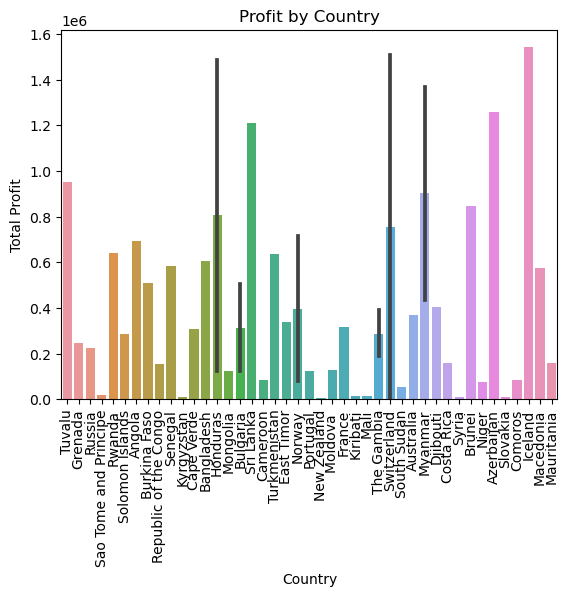

In [190]:
sb.barplot(x= AmaCopydf.iloc[:50, 1], y= 'Total Profit', data= AmaCopydf)
plt.xticks(rotation = 90)
plt.title('Profit by Country')

Text(0.5, 1.0, 'Profit by Country')

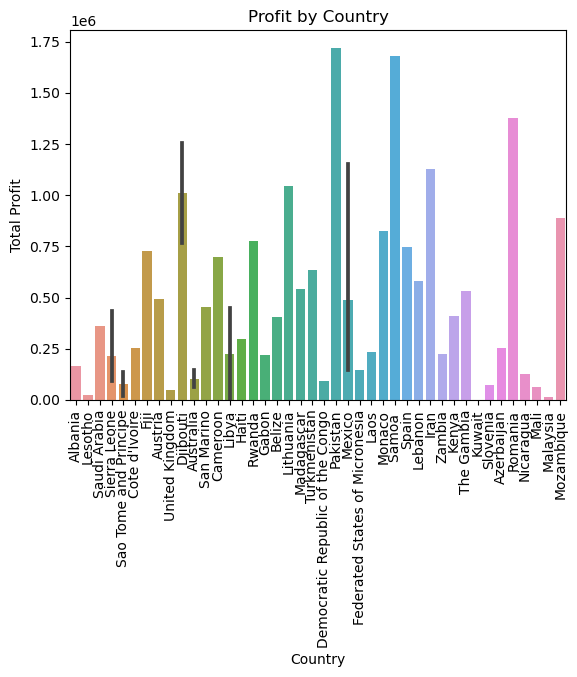

In [191]:
sb.barplot(x= AmaCopydf.iloc[50:101, 1], y= 'Total Profit', data= AmaCopydf)
plt.xticks(rotation = 90)
plt.title('Profit by Country')

Text(0.5, 1.0, 'Revenue by Country')

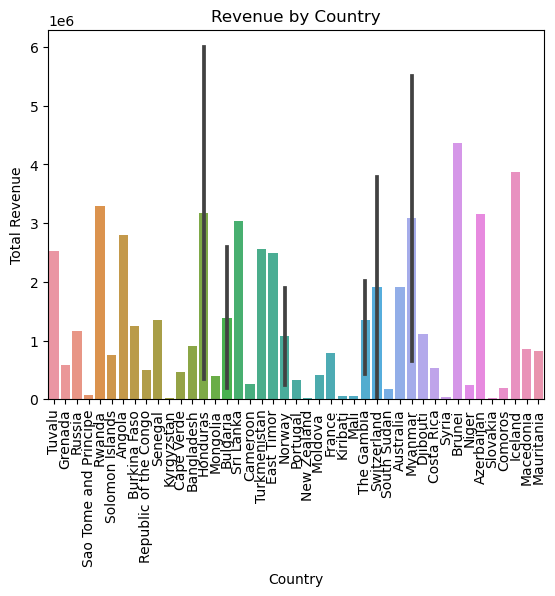

In [192]:
sb.barplot(x= AmaCopydf.iloc[:50, 1], y= 'Total Revenue', data= AmaCopydf)
plt.xticks(rotation = 90)
plt.title('Revenue by Country')

Text(0.5, 1.0, 'Revenue by Country')

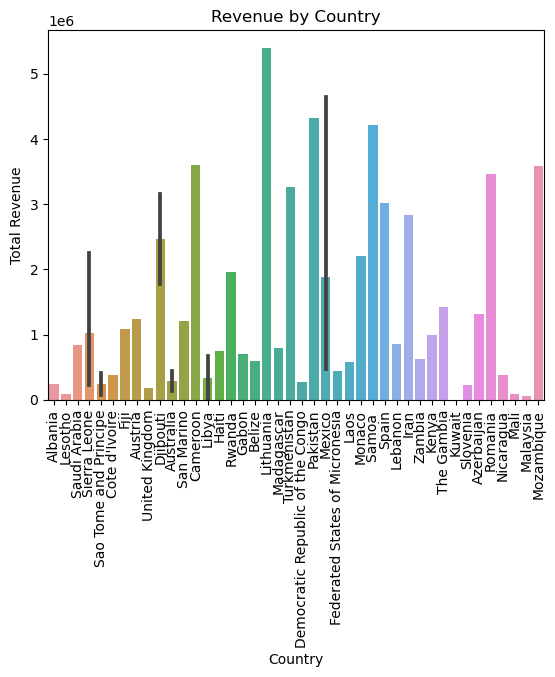

In [193]:
sb.barplot(x= AmaCopydf.iloc[50:101, 1], y= 'Total Revenue', data= AmaCopydf)
plt.xticks(rotation = 90)
plt.title('Revenue by Country')

Text(0.5, 1.0, 'Region Count')

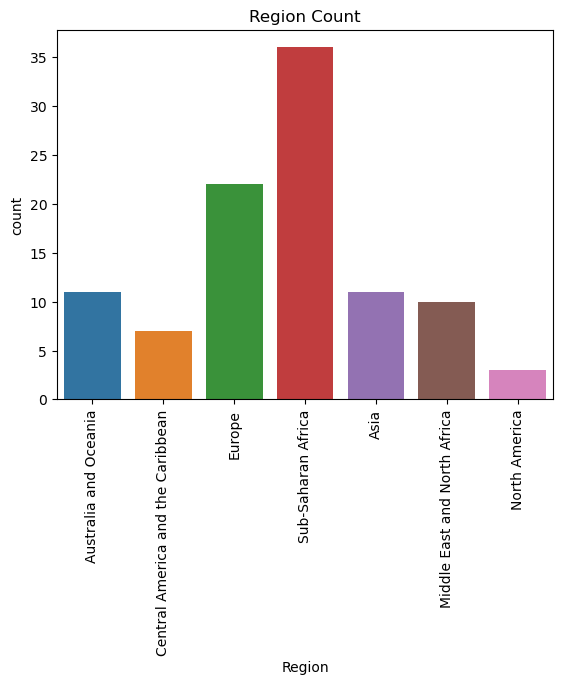

In [179]:
sb.countplot(data=AmaCopydf, x="Region")
plt.figsize=(20, 40)
plt.xticks(rotation = 90)
plt.title('Region Count')

Text(0.5, 1.0, 'Sales Channel Count')

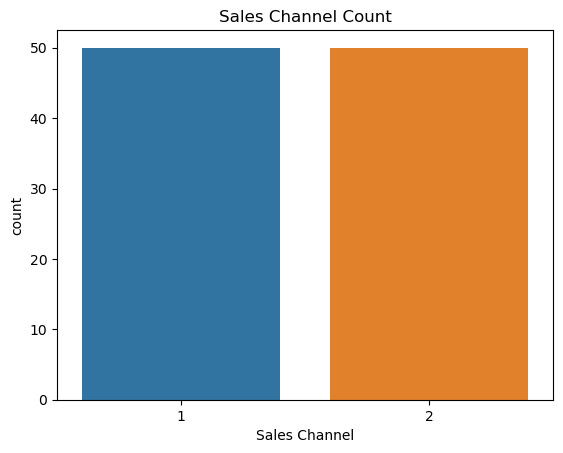

In [33]:
sb.countplot(data=AmaCopydf, x="Sales Channel")
plt.figsize=(20, 40)
plt.title('Sales Channel Count')

Text(0.5, 1.0, 'Rotating using plt.xticks()')

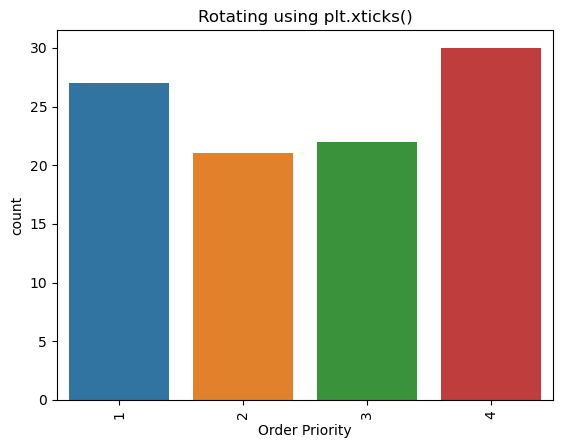

In [141]:
sb.countplot(data=AmaCopydf, x="Order Priority")
plt.figsize=(20, 40)
plt.xticks(rotation = 90)
plt.title('Rotating using plt.xticks()')

Text(0.5, 1.0, 'Profit by Region')

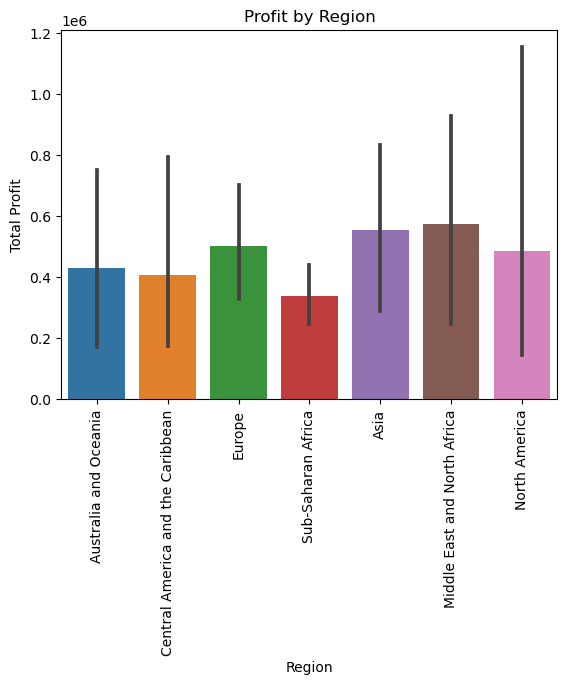

In [34]:
sb.barplot(data=AmaCopydf, x="Region", y="Total Profit",)
plt.figsize=(20, 40)
plt.xticks(rotation = 90)
plt.title('Profit by Region')


Text(0.5, 1.0, 'Revenue by Region')

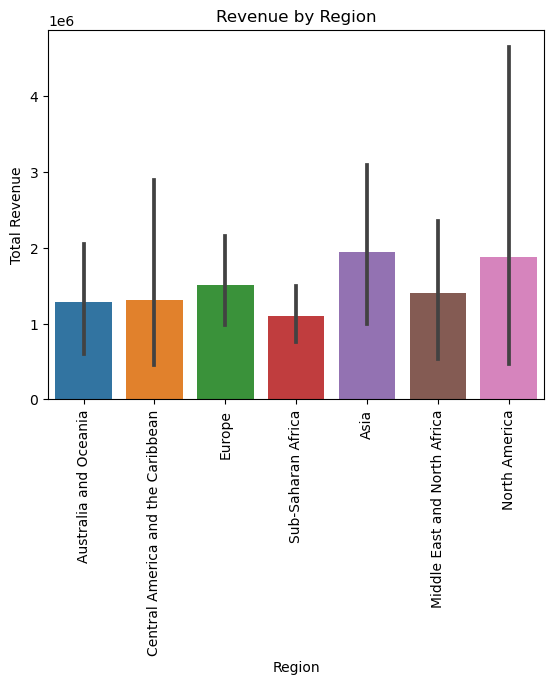

In [35]:
sb.barplot(data=AmaCopydf, x="Region", y="Total Revenue",)
plt.figsize=(20, 40)
plt.xticks(rotation = 90)
plt.title('Revenue by Region')

Text(0.5, 1.0, 'Sales Channel by Region')

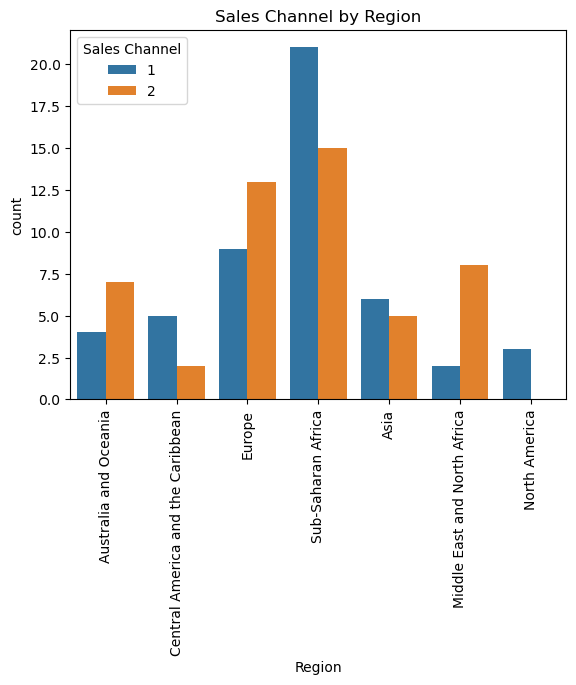

In [162]:
sb.countplot(data=AmaCopydf, x="Region", hue="Sales Channel",)
plt.figsize=(20, 40)
plt.xticks(rotation = 90)
plt.title('Sales Channel by Region')

Text(0.5, 1.0, 'Order Priority by Region')

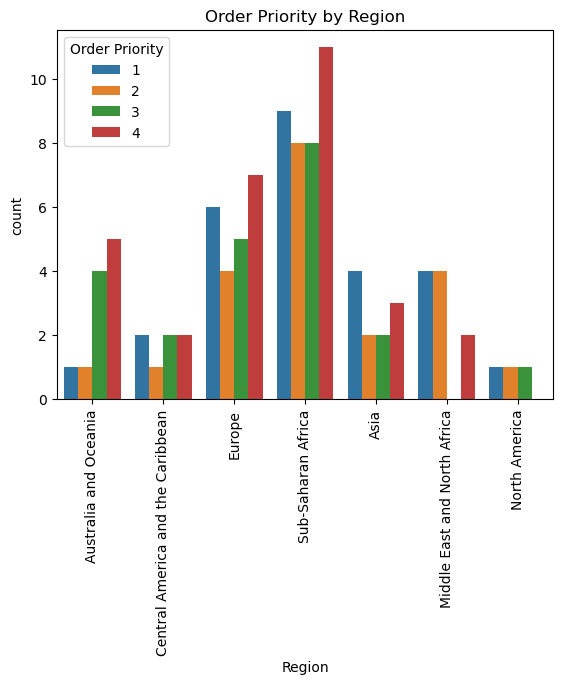

In [165]:
sb.countplot(data=AmaCopydf, x="Region", hue="Order Priority",)
plt.figsize=(20, 40)
plt.xticks(rotation = 90)
plt.title('Order Priority by Region')

Text(0.5, 1.0, 'Profit by Product')

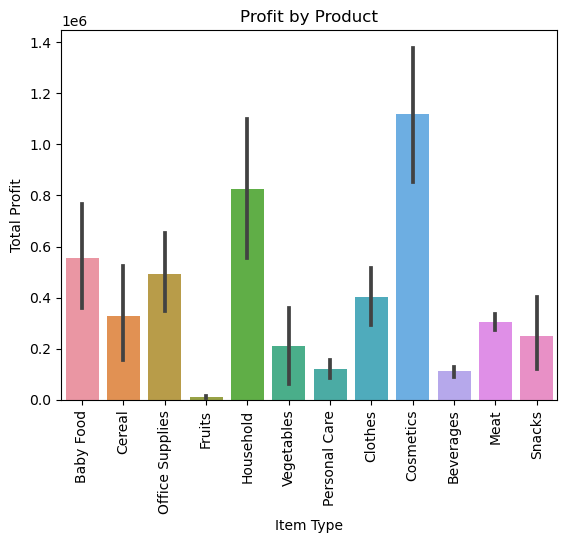

In [36]:
sb.barplot(data=AmaCopydf, x="Item Type", y="Total Profit",)

plt.xticks(rotation = 90)
plt.title('Profit by Product')


Text(0.5, 1.0, 'Revenue by Product')

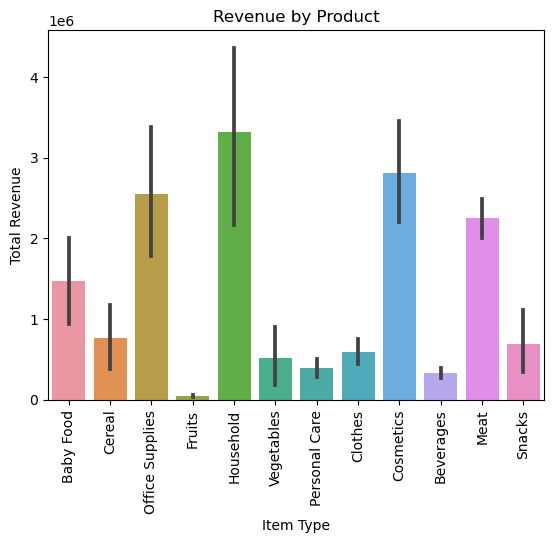

In [158]:
sb.barplot(data=AmaCopydf, x="Item Type", y="Total Revenue",)

plt.xticks(rotation = 90)
plt.title('Revenue by Product')

Text(0.5, 1.0, 'Order Priority by Product')

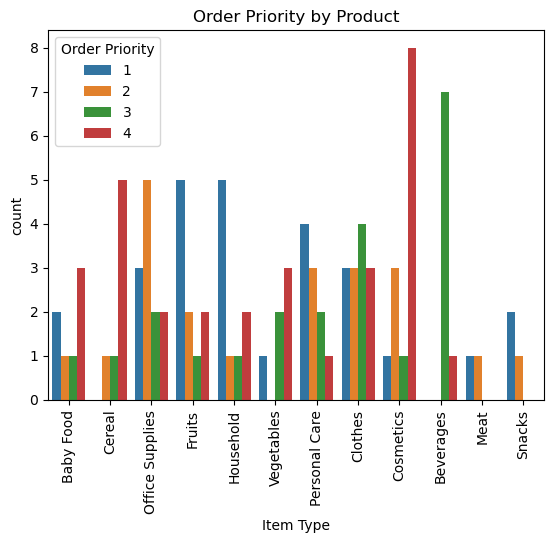

In [164]:
sb.countplot(data=AmaCopydf, x="Item Type", hue="Order Priority",)

plt.xticks(rotation = 90)
plt.title('Order Priority by Product')


<AxesSubplot:xlabel='Total Profit', ylabel='Count'>

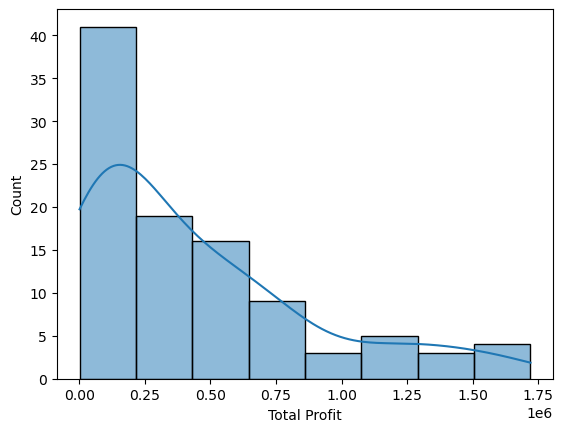

In [154]:
sb.histplot(AmaCopydf['Total Profit'], kde=True)

<AxesSubplot:xlabel='Total Revenue', ylabel='Count'>

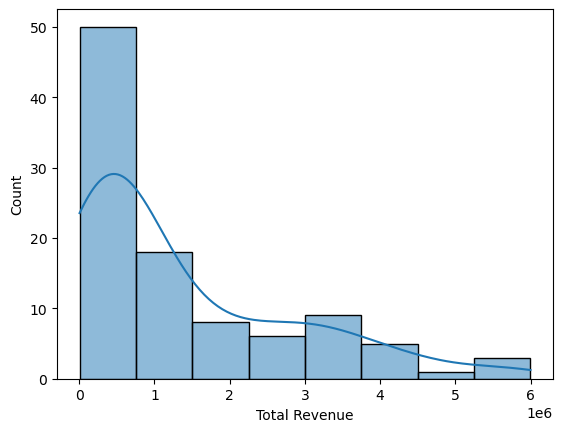

In [155]:
sb.histplot(AmaCopydf['Total Revenue'], kde=True)

In [37]:
#Household Products

housedf = AmaCopydf.loc[AmaCopydf['Item Type'] == 'Household']

In [38]:
housedf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
6,Sub-Saharan Africa,Angola,Household,1,2,4/23/2011,135425221,4/27/2011,4187,668.27,502.54,2798046.49,2104134.98,693911.51,2011-04-27,2011-04-23,4 days
13,Central America and the Caribbean,Honduras,Household,1,4,02-08-2017,522840487,2/13/2017,8974,668.27,502.54,5997054.98,4509793.96,1487261.02,2017-02-13,2017-02-08,5 days
18,Asia,Turkmenistan,Household,1,1,12/30/2010,441619336,1/20/2011,3830,668.27,502.54,2559474.10,1924728.20,634745.90,2011-01-20,2010-12-30,21 days
29,Sub-Saharan Africa,The Gambia,Household,1,1,5/26/2012,886494815,06-09-2012,2370,668.27,502.54,1583799.90,1191019.80,392780.10,2012-06-09,2012-05-26,14 days
33,Asia,Myanmar,Household,1,4,1/16/2015,177713572,03-01-2015,8250,668.27,502.54,5513227.50,4145955.00,1367272.50,2015-03-01,2015-01-16,44 days
58,Europe,United Kingdom,Household,2,1,01-05-2012,955357205,2/14/2012,282,668.27,502.54,188452.14,141716.28,46735.86,2012-02-14,2012-01-05,40 days
75,North America,Mexico,Household,1,3,11-06-2014,986435210,12-12-2014,6954,668.27,502.54,4647149.58,3494663.16,1152486.42,2014-12-12,2014-11-06,36 days
80,Europe,Spain,Household,1,1,10/21/2012,213487374,11/30/2012,4513,668.27,502.54,3015902.51,2267963.02,747939.49,2012-11-30,2012-10-21,40 days
99,Sub-Saharan Africa,Mozambique,Household,1,1,02-10-2012,665095412,2/15/2012,5367,668.27,502.54,3586605.09,2697132.18,889472.91,2012-02-15,2012-02-10,5 days


In [39]:
housedf.Country.value_counts()

Angola            1
Honduras          1
Turkmenistan      1
The Gambia        1
Myanmar           1
United Kingdom    1
Mexico            1
Spain             1
Mozambique        1
Name: Country, dtype: int64

In [40]:
housedf.Region.value_counts()

Sub-Saharan Africa                   3
Asia                                 2
Europe                               2
Central America and the Caribbean    1
North America                        1
Name: Region, dtype: int64

In [41]:
housedf.loc[housedf['orderCompTime'] == housedf['orderCompTime'].max() ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
33,Asia,Myanmar,Household,1,4,1/16/2015,177713572,03-01-2015,8250,668.27,502.54,5513227.5,4145955.0,1367272.5,2015-03-01,2015-01-16,44 days


In [42]:
housedf.loc[housedf['orderCompTime'] >= "20days" ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
18,Asia,Turkmenistan,Household,1,1,12/30/2010,441619336,1/20/2011,3830,668.27,502.54,2559474.10,1924728.20,634745.90,2011-01-20,2010-12-30,21 days
33,Asia,Myanmar,Household,1,4,1/16/2015,177713572,03-01-2015,8250,668.27,502.54,5513227.50,4145955.00,1367272.50,2015-03-01,2015-01-16,44 days
58,Europe,United Kingdom,Household,2,1,01-05-2012,955357205,2/14/2012,282,668.27,502.54,188452.14,141716.28,46735.86,2012-02-14,2012-01-05,40 days
75,North America,Mexico,Household,1,3,11-06-2014,986435210,12-12-2014,6954,668.27,502.54,4647149.58,3494663.16,1152486.42,2014-12-12,2014-11-06,36 days
80,Europe,Spain,Household,1,1,10/21/2012,213487374,11/30/2012,4513,668.27,502.54,3015902.51,2267963.02,747939.49,2012-11-30,2012-10-21,40 days


In [43]:
housedf.loc[housedf['orderCompTime'] == housedf['orderCompTime'].min() ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
6,Sub-Saharan Africa,Angola,Household,1,2,4/23/2011,135425221,4/27/2011,4187,668.27,502.54,2798046.49,2104134.98,693911.51,2011-04-27,2011-04-23,4 days


In [44]:
housedf.loc[housedf['orderCompTime'] <= "10days" ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
6,Sub-Saharan Africa,Angola,Household,1,2,4/23/2011,135425221,4/27/2011,4187,668.27,502.54,2798046.49,2104134.98,693911.51,2011-04-27,2011-04-23,4 days
13,Central America and the Caribbean,Honduras,Household,1,4,02-08-2017,522840487,2/13/2017,8974,668.27,502.54,5997054.98,4509793.96,1487261.02,2017-02-13,2017-02-08,5 days
99,Sub-Saharan Africa,Mozambique,Household,1,1,02-10-2012,665095412,2/15/2012,5367,668.27,502.54,3586605.09,2697132.18,889472.91,2012-02-15,2012-02-10,5 days


Text(0.5, 1.0, 'Sales Channel Distribution')

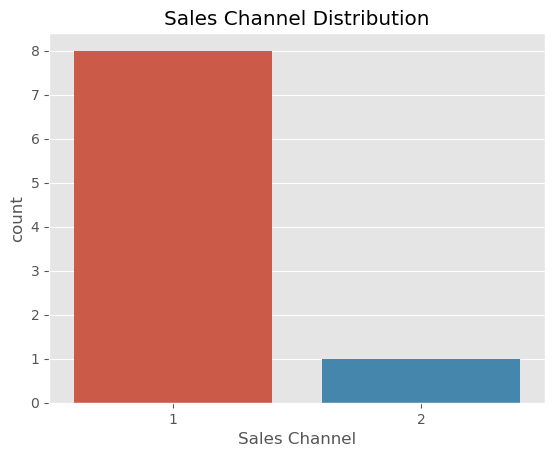

In [245]:
sb.countplot(data=housedf, x="Sales Channel")
plt.figsize=(20, 40)
plt.title('Sales Channel Distribution')

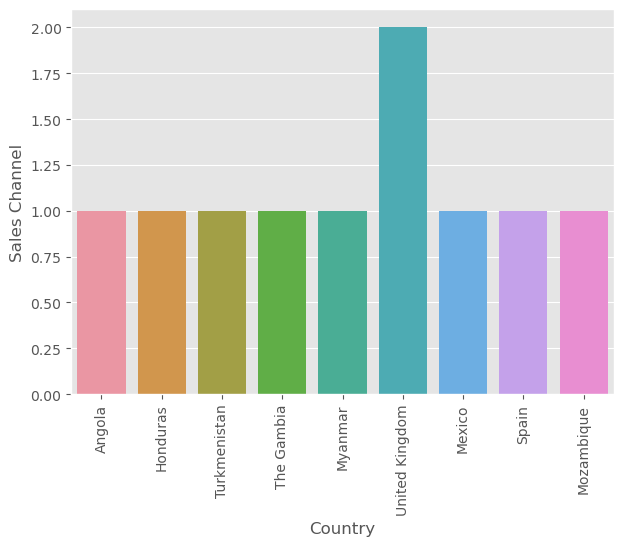

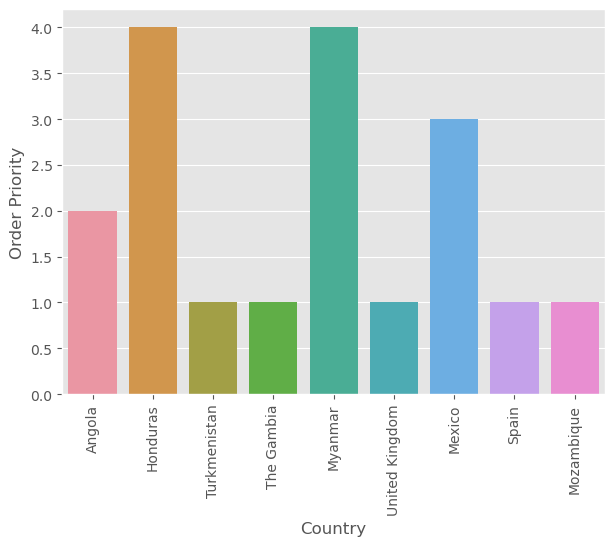

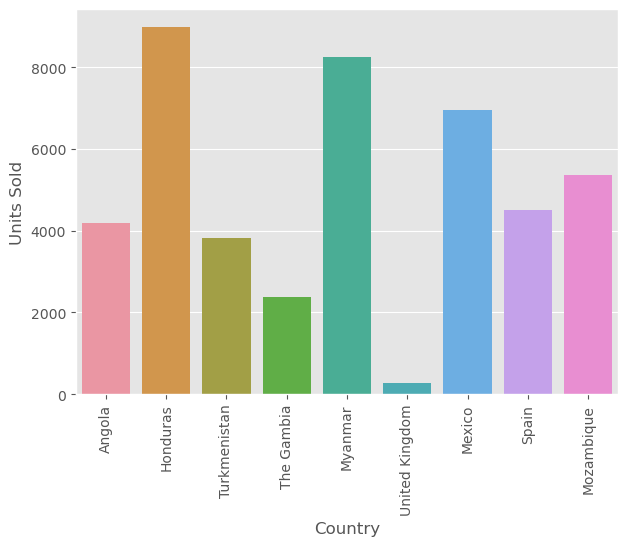

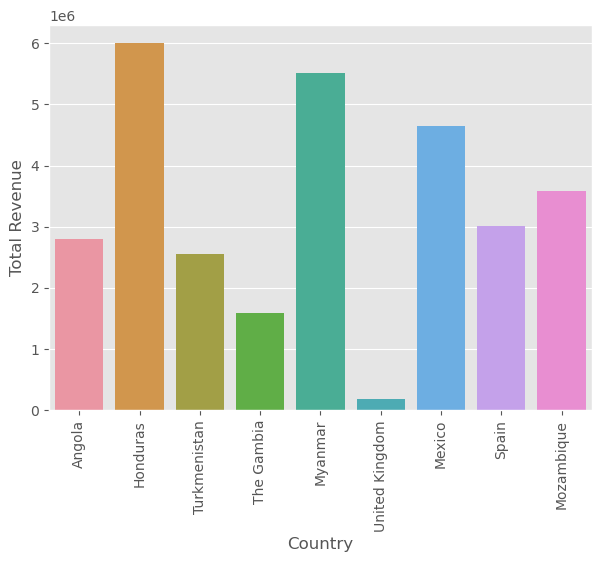

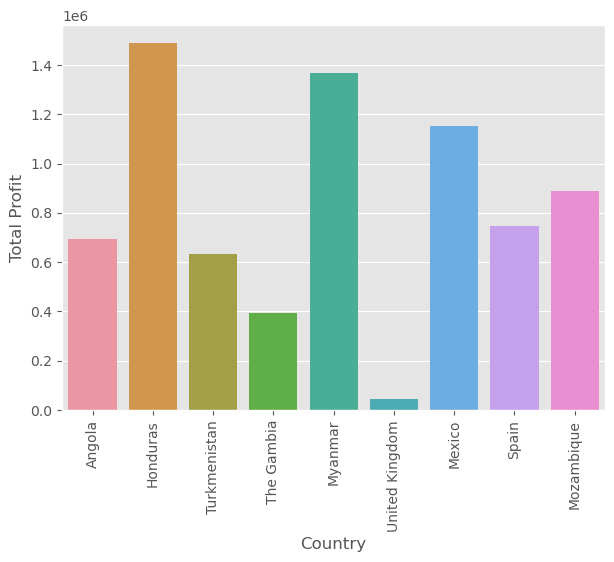

In [246]:
%matplotlib inline

def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = housedf)
    plt.xticks(rotation = 90)
    plt.show()
    


ColumnList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Country', column, housedf)

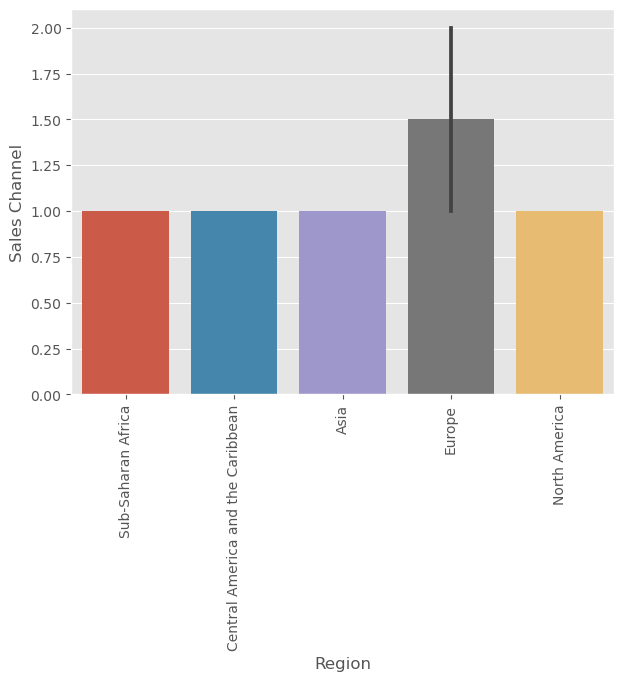

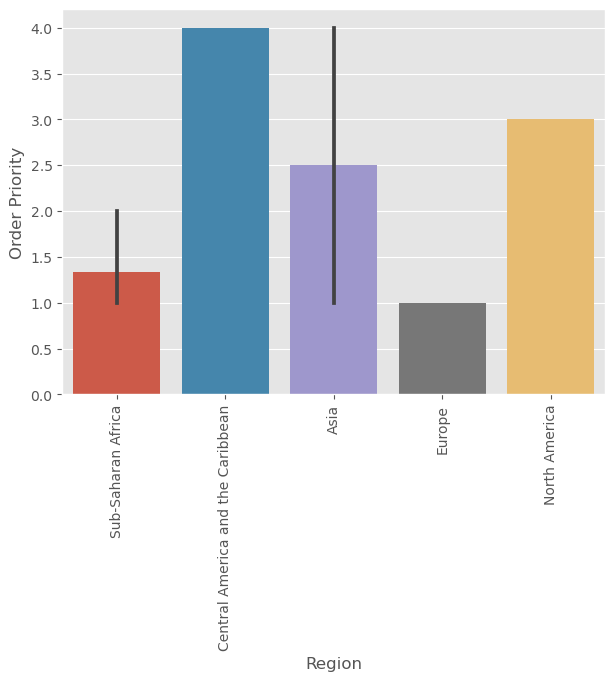

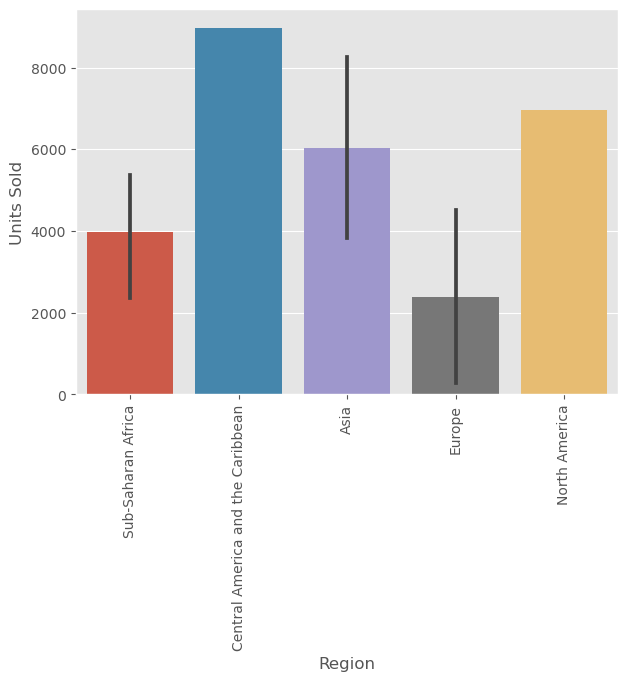

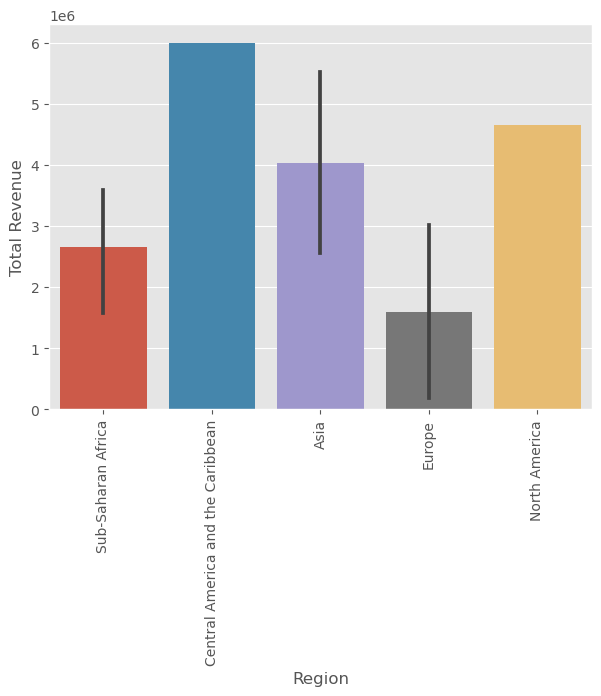

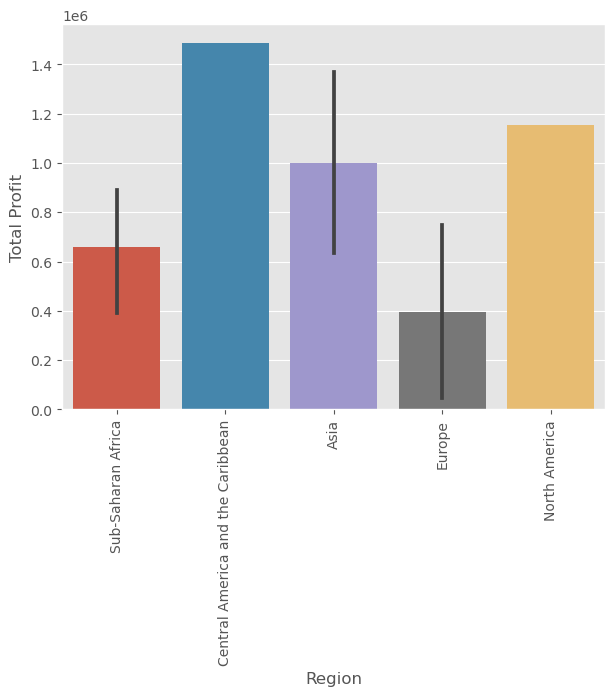

In [247]:
def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = housedf)
    plt.xticks(rotation = 90)
    plt.show()
    


ColumnList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Region', column, housedf)

In [48]:
Clothdf = AmaCopydf.loc[AmaCopydf['Item Type'] == 'Clothes']

In [49]:
Clothdf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
11,Sub-Saharan Africa,Cape Verde,Clothes,1,4,08-02-2014,939825713,8/19/2014,4168,109.28,35.84,455479.04,149381.12,306097.92,2014-08-19,2014-08-02,17 days
12,Asia,Bangladesh,Clothes,2,1,1/13/2017,187310731,03-01-2017,8263,109.28,35.84,902980.64,296145.92,606834.72,2017-03-01,2017-01-13,47 days
15,Europe,Bulgaria,Clothes,2,2,4/23/2012,972292029,06-03-2012,1673,109.28,35.84,182825.44,59960.32,122865.12,2012-06-03,2012-04-23,41 days
44,Asia,Myanmar,Clothes,2,4,11/14/2015,223359620,11/18/2015,5930,109.28,35.84,648030.40,212531.20,435499.20,2015-11-18,2015-11-14,4 days
48,Europe,Macedonia,Clothes,1,3,10/14/2014,787399423,11/14/2014,7842,109.28,35.84,856973.76,281057.28,575916.48,2014-11-14,2014-10-14,31 days
50,Europe,Albania,Clothes,2,3,02-02-2010,385383069,3/18/2010,2269,109.28,35.84,247956.32,81320.96,166635.36,2010-03-18,2010-02-02,44 days
55,Sub-Saharan Africa,Cote d'Ivoire,Clothes,2,3,06-08-2012,114606559,6/27/2012,3482,109.28,35.84,380512.96,124794.88,255718.08,2012-06-27,2012-06-08,19 days
56,Australia and Oceania,Fiji,Clothes,1,3,6/30/2010,647876489,08-01-2010,9905,109.28,35.84,1082418.40,354995.20,727423.20,2010-08-01,2010-06-30,32 days
63,Middle East and North Africa,Libya,Clothes,1,4,10/30/2010,705784308,11/17/2010,6116,109.28,35.84,668356.48,219197.44,449159.04,2010-11-17,2010-10-30,18 days
67,Central America and the Caribbean,Belize,Clothes,1,2,7/25/2016,807025039,09-07-2016,5498,109.28,35.84,600821.44,197048.32,403773.12,2016-09-07,2016-07-25,44 days


In [50]:
Clothdf.Country.value_counts()

Cape Verde       1
Bangladesh       1
Bulgaria         1
Myanmar          1
Macedonia        1
Albania          1
Cote d'Ivoire    1
Fiji             1
Libya            1
Belize           1
Madagascar       1
Lebanon          1
Mali             1
Name: Country, dtype: int64

In [51]:
Clothdf.Region.value_counts()

Sub-Saharan Africa                   4
Europe                               3
Asia                                 2
Middle East and North Africa         2
Australia and Oceania                1
Central America and the Caribbean    1
Name: Region, dtype: int64

In [52]:
Clothdf.loc[Clothdf['orderCompTime'] == Clothdf['orderCompTime'].max() ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
12,Asia,Bangladesh,Clothes,2,1,1/13/2017,187310731,03-01-2017,8263,109.28,35.84,902980.64,296145.92,606834.72,2017-03-01,2017-01-13,47 days


In [53]:
Clothdf.loc[Clothdf['orderCompTime'] >= "20days" ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
12,Asia,Bangladesh,Clothes,2,1,1/13/2017,187310731,03-01-2017,8263,109.28,35.84,902980.64,296145.92,606834.72,2017-03-01,2017-01-13,47 days
15,Europe,Bulgaria,Clothes,2,2,4/23/2012,972292029,06-03-2012,1673,109.28,35.84,182825.44,59960.32,122865.12,2012-06-03,2012-04-23,41 days
48,Europe,Macedonia,Clothes,1,3,10/14/2014,787399423,11/14/2014,7842,109.28,35.84,856973.76,281057.28,575916.48,2014-11-14,2014-10-14,31 days
50,Europe,Albania,Clothes,2,3,02-02-2010,385383069,3/18/2010,2269,109.28,35.84,247956.32,81320.96,166635.36,2010-03-18,2010-02-02,44 days
56,Australia and Oceania,Fiji,Clothes,1,3,6/30/2010,647876489,08-01-2010,9905,109.28,35.84,1082418.40,354995.20,727423.20,2010-08-01,2010-06-30,32 days
67,Central America and the Caribbean,Belize,Clothes,1,2,7/25/2016,807025039,09-07-2016,5498,109.28,35.84,600821.44,197048.32,403773.12,2016-09-07,2016-07-25,44 days
69,Sub-Saharan Africa,Madagascar,Clothes,1,1,4/25/2015,610425555,5/28/2015,7342,109.28,35.84,802333.76,263137.28,539196.48,2015-05-28,2015-04-25,33 days
81,Middle East and North Africa,Lebanon,Clothes,2,1,9/18/2012,663110148,10-08-2012,7884,109.28,35.84,861563.52,282562.56,579000.96,2012-10-08,2012-09-18,20 days
95,Sub-Saharan Africa,Mali,Clothes,2,2,7/26/2011,512878119,09-03-2011,888,109.28,35.84,97040.64,31825.92,65214.72,2011-09-03,2011-07-26,39 days


In [54]:
Clothdf.loc[Clothdf['orderCompTime'] == Clothdf['orderCompTime'].min() ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
44,Asia,Myanmar,Clothes,2,4,11/14/2015,223359620,11/18/2015,5930,109.28,35.84,648030.4,212531.2,435499.2,2015-11-18,2015-11-14,4 days


In [55]:
Clothdf.loc[Clothdf['orderCompTime'] <= "10days"]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
44,Asia,Myanmar,Clothes,2,4,11/14/2015,223359620,11/18/2015,5930,109.28,35.84,648030.4,212531.2,435499.2,2015-11-18,2015-11-14,4 days


Text(0.5, 1.0, 'Sales Channel Distribution')

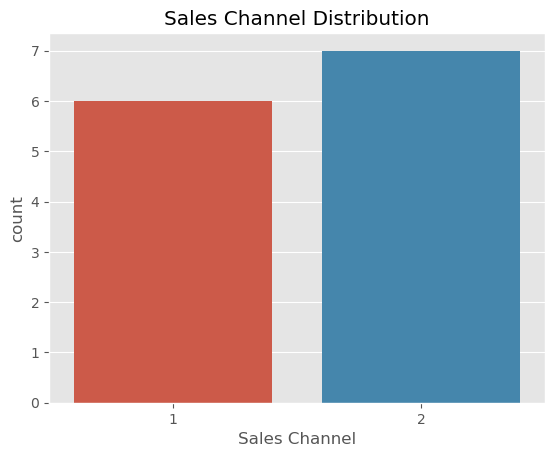

In [242]:
sb.countplot(data=Clothdf, x="Sales Channel")
plt.figsize=(20, 40)
plt.title('Sales Channel Distribution')

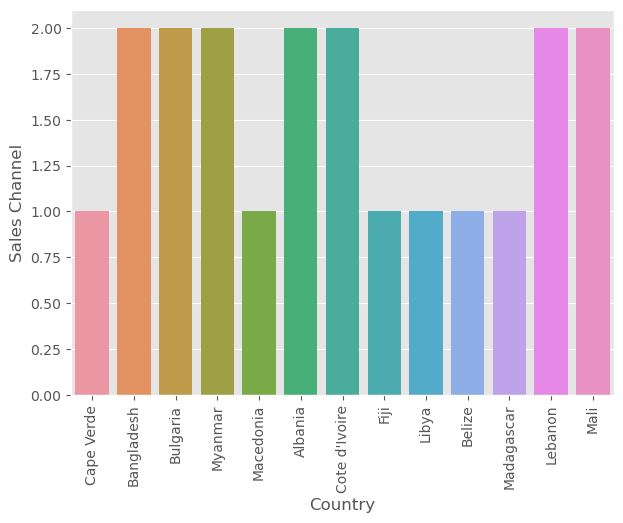

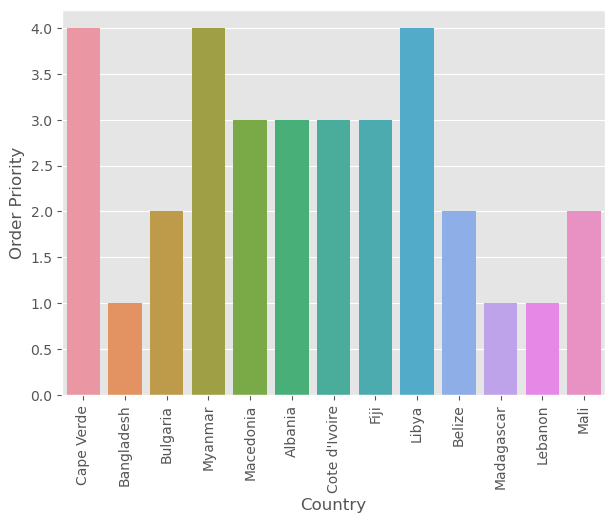

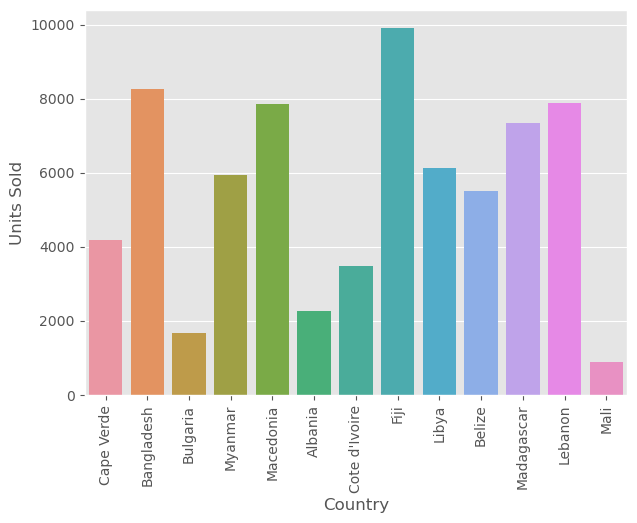

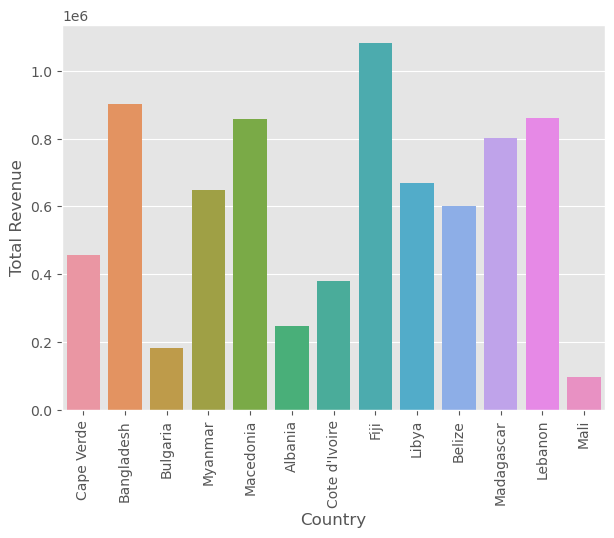

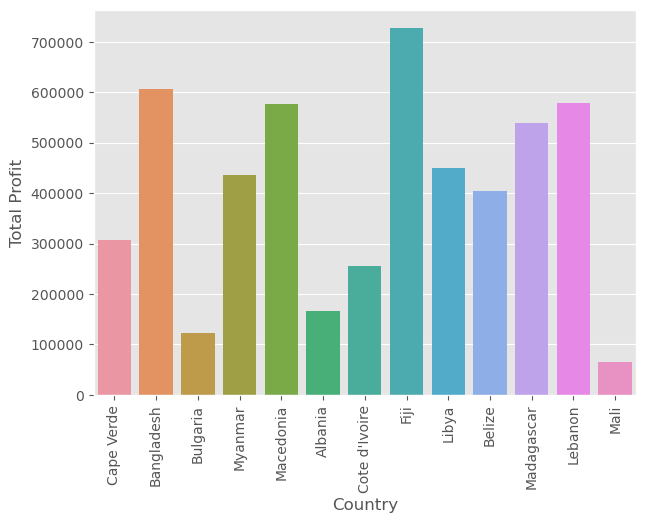

In [243]:
%matplotlib inline

def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Clothdf)
    plt.xticks(rotation = 90)
    plt.show()
    


ColumnList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Country', column, Clothdf)

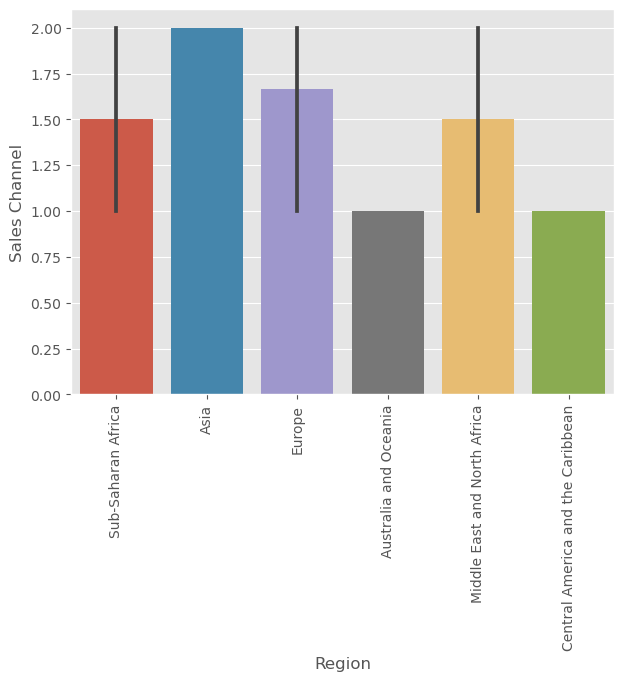

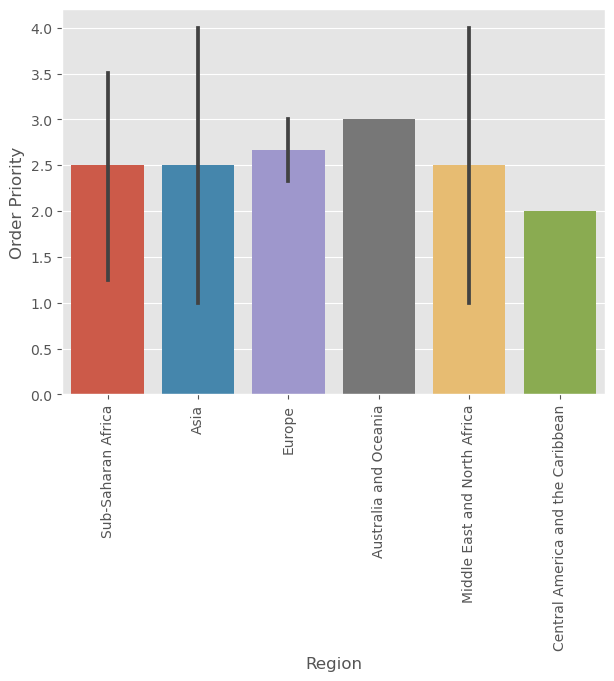

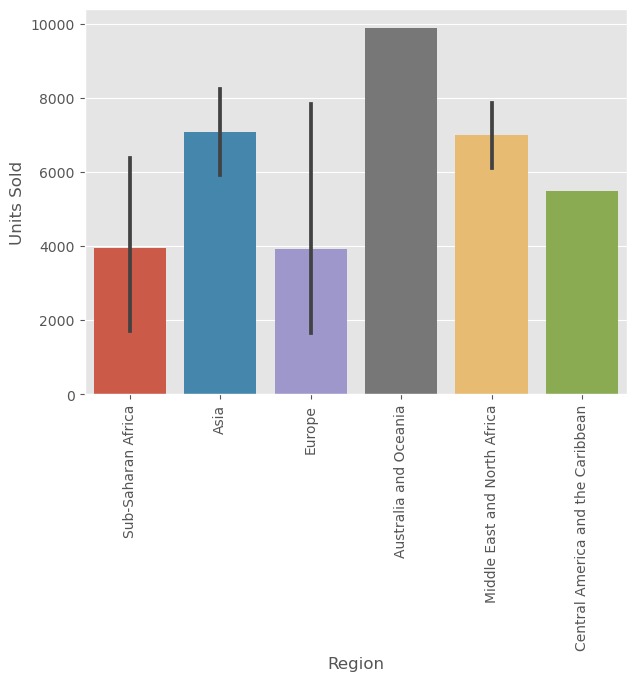

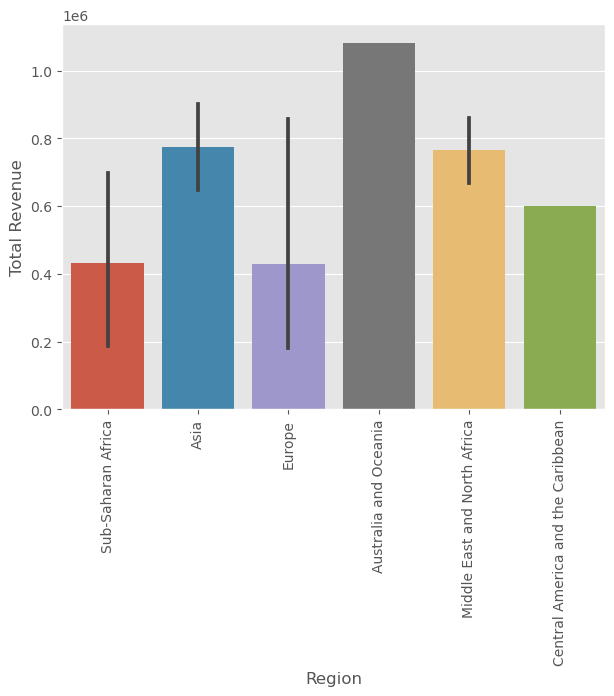

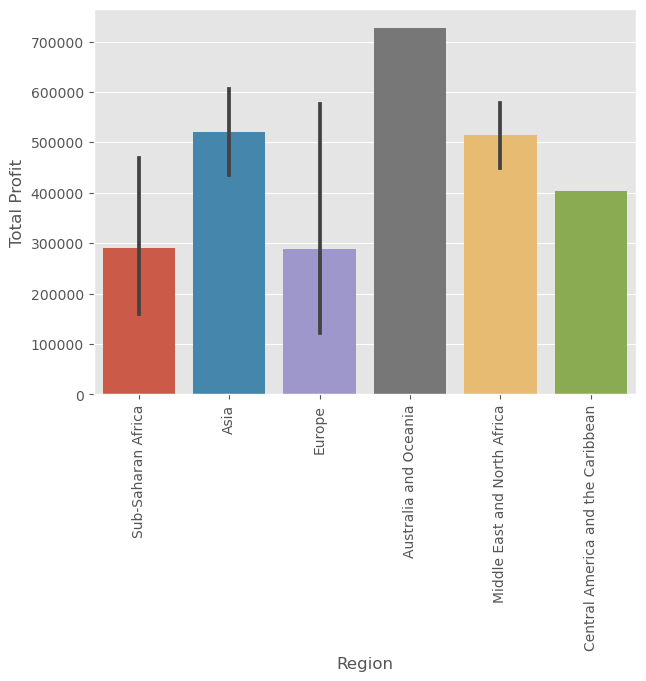

In [244]:
%matplotlib inline

def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Clothdf)
    plt.xticks(rotation = 90)
    plt.show()
    


ColumnList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Region', column, Clothdf)

In [59]:
#cosmetic Products

Cosmetdf = AmaCopydf.loc[AmaCopydf['Item Type'] == 'Cosmetics']

In [60]:
Cosmetdf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
16,Asia,Sri Lanka,Cosmetics,1,2,11/19/2016,419123971,12/18/2016,6952,437.2,263.33,3039414.4,1830670.16,1208744.24,2016-12-18,2016-11-19,29 days
25,Europe,France,Cosmetics,2,4,5/22/2017,898523128,06-05-2017,1815,437.2,263.33,793518.0,477943.95,315574.05,2017-06-05,2017-05-22,14 days
30,Europe,Switzerland,Cosmetics,1,2,9/17/2012,249693334,10/20/2012,8661,437.2,263.33,3786589.2,2280701.13,1505888.07,2012-10-20,2012-09-17,33 days
41,Middle East and North Africa,Azerbaijan,Cosmetics,2,2,02-06-2010,382392299,2/25/2010,7234,437.2,263.33,3162704.8,1904929.22,1257775.58,2010-02-25,2010-02-06,19 days
46,Europe,Iceland,Cosmetics,2,3,12/31/2016,331438481,12/31/2016,8867,437.2,263.33,3876652.4,2334947.11,1541705.29,2016-12-31,2016-12-31,0 days
57,Europe,Austria,Cosmetics,1,4,2/23/2015,868214595,03-02-2015,2847,437.2,263.33,1244708.4,749700.51,495007.89,2015-03-02,2015-02-23,7 days
59,Sub-Saharan Africa,Djibouti,Cosmetics,1,4,04-07-2014,259353148,4/19/2014,7215,437.2,263.33,3154398.0,1899925.95,1254472.05,2014-04-19,2014-04-07,12 days
64,Central America and the Caribbean,Haiti,Cosmetics,1,4,10/13/2013,505716836,11/16/2013,1705,437.2,263.33,745426.0,448977.65,296448.35,2013-11-16,2013-10-13,34 days
65,Sub-Saharan Africa,Rwanda,Cosmetics,1,4,10-11-2013,699358165,11/25/2013,4477,437.2,263.33,1957344.4,1178928.41,778415.99,2013-11-25,2013-10-11,45 days
74,Middle East and North Africa,Pakistan,Cosmetics,1,1,07-05-2013,231145322,8/16/2013,9892,437.2,263.33,4324782.4,2604860.36,1719922.04,2013-08-16,2013-07-05,42 days


In [61]:
Cosmetdf.Country.value_counts()

Sri Lanka      1
France         1
Switzerland    1
Azerbaijan     1
Iceland        1
Austria        1
Djibouti       1
Haiti          1
Rwanda         1
Pakistan       1
Samoa          1
Iran           1
Romania        1
Name: Country, dtype: int64

In [62]:
Cosmetdf.Region.value_counts()

Europe                               5
Middle East and North Africa         3
Sub-Saharan Africa                   2
Asia                                 1
Central America and the Caribbean    1
Australia and Oceania                1
Name: Region, dtype: int64

In [63]:
Cosmetdf.loc[Cosmetdf['orderCompTime'] == Cosmetdf['orderCompTime'].max() ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
65,Sub-Saharan Africa,Rwanda,Cosmetics,1,4,10-11-2013,699358165,11/25/2013,4477,437.2,263.33,1957344.4,1178928.41,778415.99,2013-11-25,2013-10-11,45 days


In [64]:
Cosmetdf.loc[Cosmetdf['orderCompTime'] >= "20days" ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
16,Asia,Sri Lanka,Cosmetics,1,2,11/19/2016,419123971,12/18/2016,6952,437.2,263.33,3039414.4,1830670.16,1208744.24,2016-12-18,2016-11-19,29 days
30,Europe,Switzerland,Cosmetics,1,2,9/17/2012,249693334,10/20/2012,8661,437.2,263.33,3786589.2,2280701.13,1505888.07,2012-10-20,2012-09-17,33 days
64,Central America and the Caribbean,Haiti,Cosmetics,1,4,10/13/2013,505716836,11/16/2013,1705,437.2,263.33,745426.0,448977.65,296448.35,2013-11-16,2013-10-13,34 days
65,Sub-Saharan Africa,Rwanda,Cosmetics,1,4,10-11-2013,699358165,11/25/2013,4477,437.2,263.33,1957344.4,1178928.41,778415.99,2013-11-25,2013-10-11,45 days
74,Middle East and North Africa,Pakistan,Cosmetics,1,1,07-05-2013,231145322,8/16/2013,9892,437.2,263.33,4324782.4,2604860.36,1719922.04,2013-08-16,2013-07-05,42 days
82,Middle East and North Africa,Iran,Cosmetics,2,4,11/15/2016,286959302,12-08-2016,6489,437.2,263.33,2836990.8,1708748.37,1128242.43,2016-12-08,2016-11-15,23 days
93,Europe,Romania,Cosmetics,2,4,11/26/2010,660643374,12/25/2010,7910,437.2,263.33,3458252.0,2082940.30,1375311.70,2010-12-25,2010-11-26,29 days


In [65]:
Cosmetdf.loc[Cosmetdf['orderCompTime'] == Cosmetdf['orderCompTime'].min() ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
46,Europe,Iceland,Cosmetics,2,3,12/31/2016,331438481,12/31/2016,8867,437.2,263.33,3876652.4,2334947.11,1541705.29,2016-12-31,2016-12-31,0 days


In [66]:
Cosmetdf.loc[Cosmetdf['orderCompTime'] <= "10days" ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
46,Europe,Iceland,Cosmetics,2,3,12/31/2016,331438481,12/31/2016,8867,437.2,263.33,3876652.4,2334947.11,1541705.29,2016-12-31,2016-12-31,0 days
57,Europe,Austria,Cosmetics,1,4,2/23/2015,868214595,03-02-2015,2847,437.2,263.33,1244708.4,749700.51,495007.89,2015-03-02,2015-02-23,7 days


Text(0.5, 1.0, 'Sales Channel Distribution')

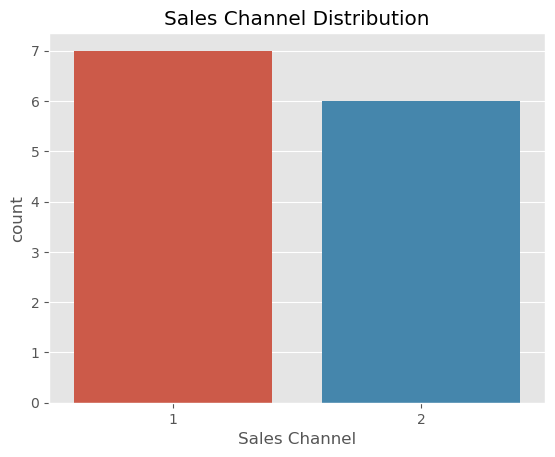

In [241]:
sb.countplot(data=Cosmetdf, x="Sales Channel")
plt.figsize=(20, 40)
plt.title('Sales Channel Distribution')

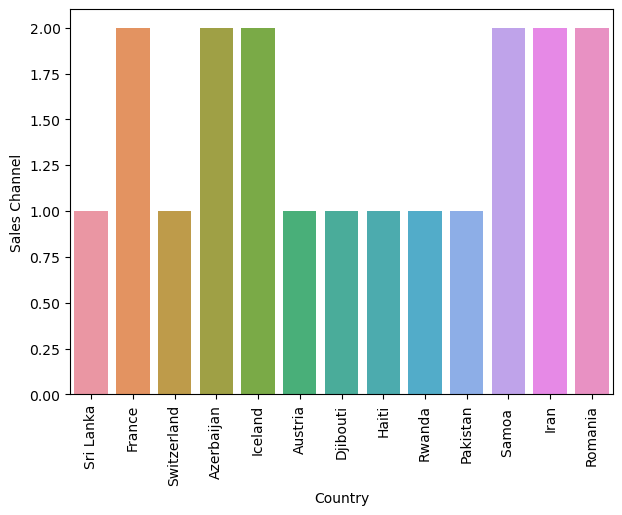

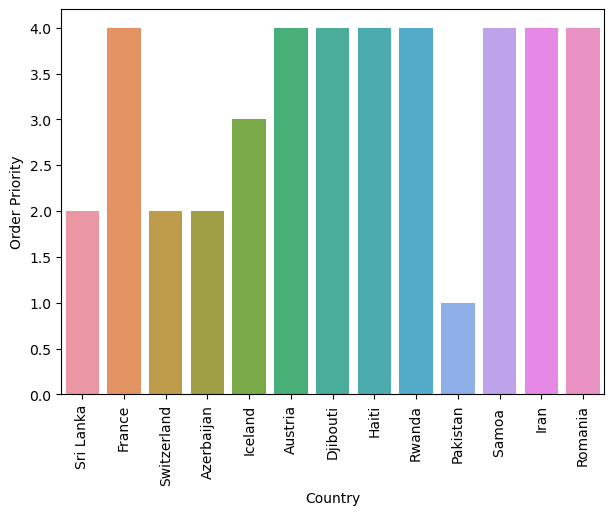

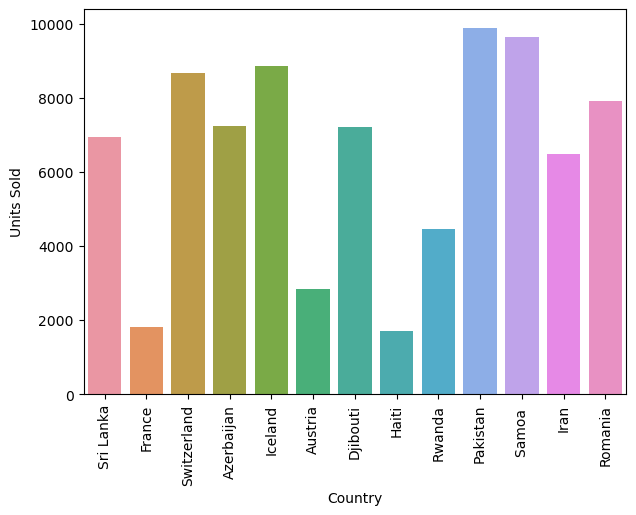

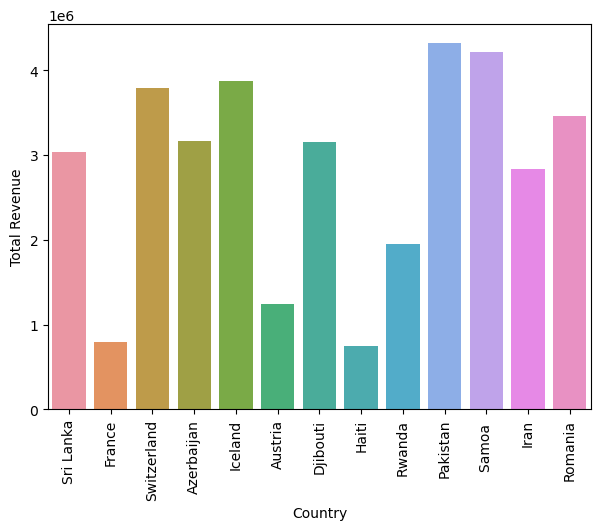

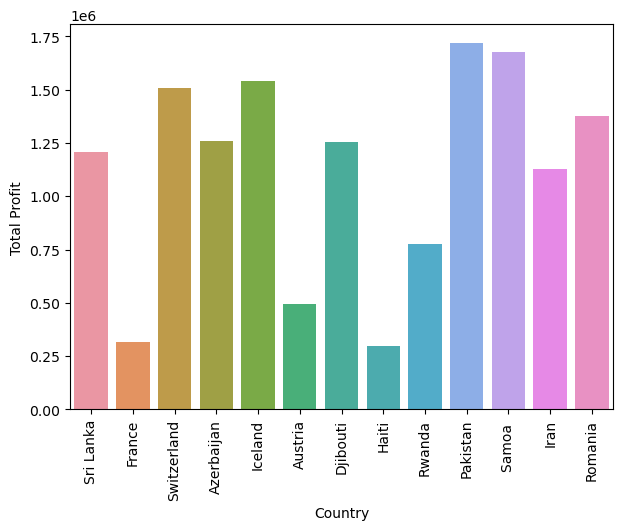

In [68]:
%matplotlib inline

def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Cosmetdf)
    plt.xticks(rotation = 90)
    
    plt.show()
    


ColumnList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Country', column, Cosmetdf)

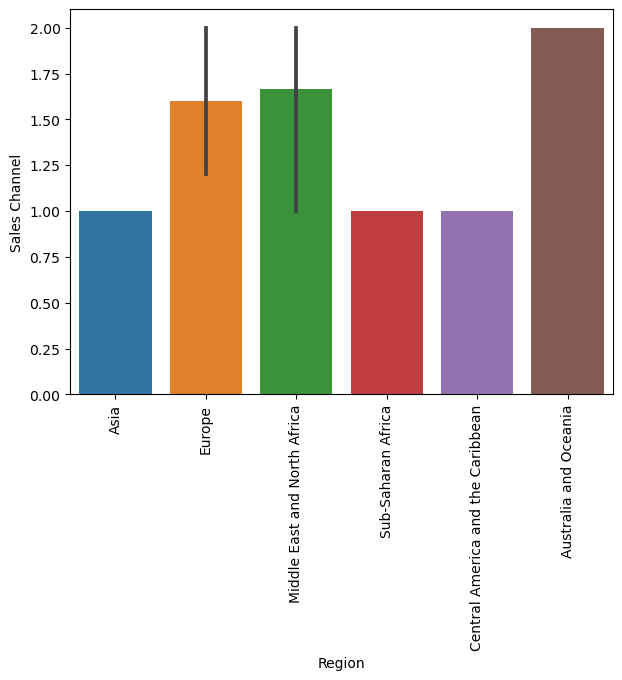

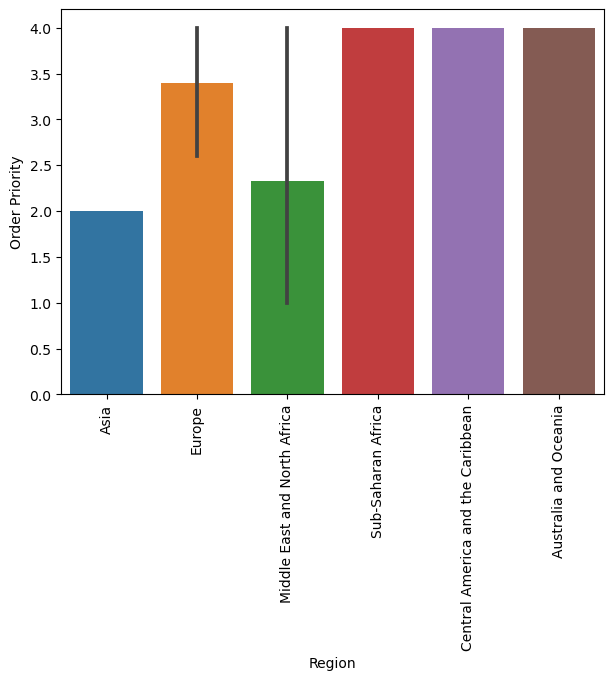

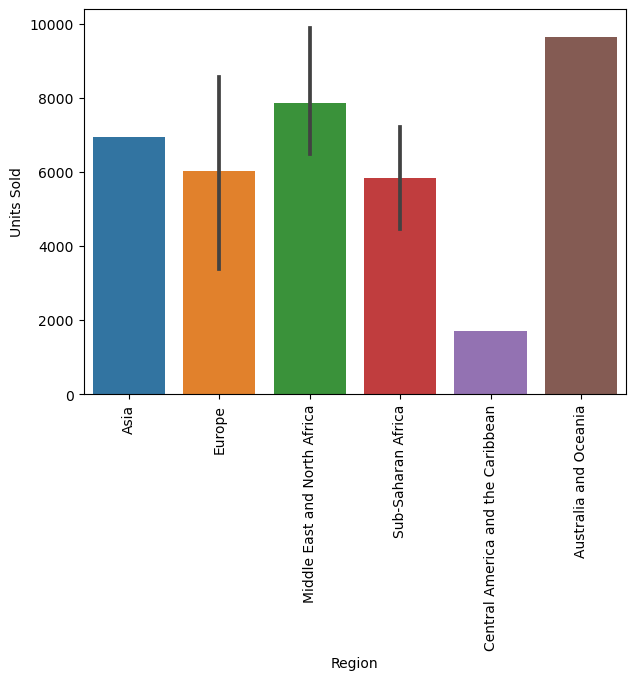

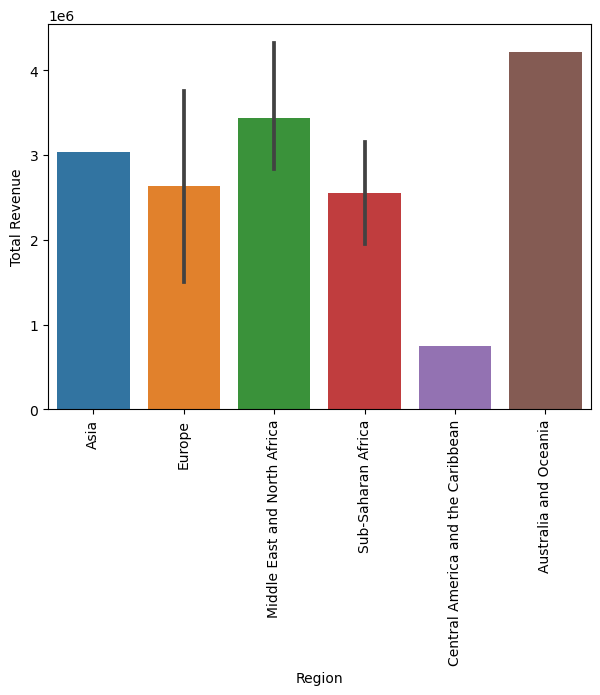

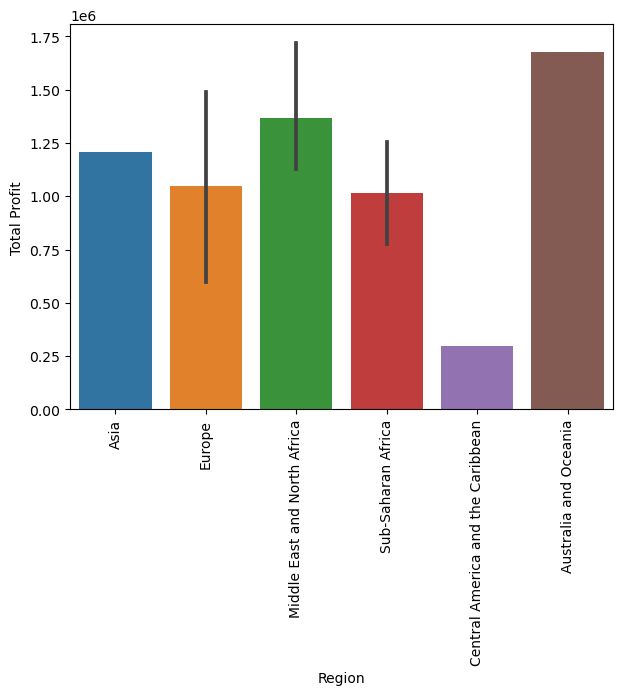

In [69]:
%matplotlib inline

def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Cosmetdf)
    plt.xticks(rotation = 90)
    
    plt.show()
    


ColumnList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Region', column, Cosmetdf)

In [70]:
Officedf = AmaCopydf.loc[AmaCopydf['Item Type'] == 'Office Supplies']

In [71]:
Officedf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
2,Europe,Russia,Office Supplies,1,1,05-02-2014,341417157,05-08-2014,1779,651.21,524.96,1158502.59,933903.84,224598.75,2014-05-08,2014-05-02,6 days
4,Sub-Saharan Africa,Rwanda,Office Supplies,1,1,02-01-2013,115456712,02-06-2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50,2013-02-06,2013-02-01,5 days
32,Australia and Oceania,Australia,Office Supplies,2,3,10/27/2015,158535134,11/25/2015,2924,651.21,524.96,1904138.04,1534983.04,369155.00,2015-11-25,2015-10-27,29 days
38,Asia,Brunei,Office Supplies,2,1,04-01-2012,320009267,05-08-2012,6708,651.21,524.96,4368316.68,3521431.68,846885.00,2012-05-08,2012-04-01,37 days
39,Europe,Bulgaria,Office Supplies,2,2,2/16/2012,189965903,2/28/2012,3987,651.21,524.96,2596374.27,2093015.52,503358.75,2012-02-28,2012-02-16,12 days
49,Sub-Saharan Africa,Mauritania,Office Supplies,1,3,01-11-2012,837559306,1/13/2012,1266,651.21,524.96,824431.86,664599.36,159832.50,2012-01-13,2012-01-11,2 days
53,Sub-Saharan Africa,Sierra Leone,Office Supplies,1,2,11/26/2011,441888415,01-07-2012,3457,651.21,524.96,2251232.97,1814786.72,436446.25,2012-01-07,2011-11-26,42 days
62,Sub-Saharan Africa,Cameroon,Office Supplies,2,2,11-07-2011,177636754,11/15/2011,5518,651.21,524.96,3593376.78,2896729.28,696647.50,2011-11-15,2011-11-07,8 days
68,Europe,Lithuania,Office Supplies,1,4,10/24/2010,166460740,11/17/2010,8287,651.21,524.96,5396577.27,4350343.52,1046233.75,2010-11-17,2010-10-24,24 days
70,Asia,Turkmenistan,Office Supplies,2,2,4/23/2013,462405812,5/20/2013,5010,651.21,524.96,3262562.10,2630049.60,632512.50,2013-05-20,2013-04-23,27 days


In [72]:
Officedf.Country.value_counts()

Sierra Leone    2
Russia          1
Rwanda          1
Australia       1
Brunei          1
Bulgaria        1
Mauritania      1
Cameroon        1
Lithuania       1
Turkmenistan    1
Azerbaijan      1
Name: Country, dtype: int64

In [73]:
Officedf.Region.value_counts()

Sub-Saharan Africa              5
Europe                          3
Asia                            2
Australia and Oceania           1
Middle East and North Africa    1
Name: Region, dtype: int64

In [74]:
Officedf.loc[Officedf['orderCompTime'] == Officedf['orderCompTime'].max() ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
53,Sub-Saharan Africa,Sierra Leone,Office Supplies,1,2,11/26/2011,441888415,01-07-2012,3457,651.21,524.96,2251232.97,1814786.72,436446.25,2012-01-07,2011-11-26,42 days


In [75]:
Officedf.loc[Officedf['orderCompTime'] >= "20days" ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
32,Australia and Oceania,Australia,Office Supplies,2,3,10/27/2015,158535134,11/25/2015,2924,651.21,524.96,1904138.04,1534983.04,369155.00,2015-11-25,2015-10-27,29 days
38,Asia,Brunei,Office Supplies,2,1,04-01-2012,320009267,05-08-2012,6708,651.21,524.96,4368316.68,3521431.68,846885.00,2012-05-08,2012-04-01,37 days
53,Sub-Saharan Africa,Sierra Leone,Office Supplies,1,2,11/26/2011,441888415,01-07-2012,3457,651.21,524.96,2251232.97,1814786.72,436446.25,2012-01-07,2011-11-26,42 days
68,Europe,Lithuania,Office Supplies,1,4,10/24/2010,166460740,11/17/2010,8287,651.21,524.96,5396577.27,4350343.52,1046233.75,2010-11-17,2010-10-24,24 days
70,Asia,Turkmenistan,Office Supplies,2,2,4/23/2013,462405812,5/20/2013,5010,651.21,524.96,3262562.10,2630049.60,632512.50,2013-05-20,2013-04-23,27 days
92,Middle East and North Africa,Azerbaijan,Office Supplies,2,2,6/13/2012,423331391,7/24/2012,2021,651.21,524.96,1316095.41,1060944.16,255151.25,2012-07-24,2012-06-13,41 days


In [76]:
Officedf.loc[Officedf['orderCompTime'] == Officedf['orderCompTime'].min() ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
49,Sub-Saharan Africa,Mauritania,Office Supplies,1,3,01-11-2012,837559306,1/13/2012,1266,651.21,524.96,824431.86,664599.36,159832.5,2012-01-13,2012-01-11,2 days


In [77]:
Officedf.loc[Officedf['orderCompTime'] <= "10days" ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
2,Europe,Russia,Office Supplies,1,1,05-02-2014,341417157,05-08-2014,1779,651.21,524.96,1158502.59,933903.84,224598.75,2014-05-08,2014-05-02,6 days
4,Sub-Saharan Africa,Rwanda,Office Supplies,1,1,02-01-2013,115456712,02-06-2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50,2013-02-06,2013-02-01,5 days
49,Sub-Saharan Africa,Mauritania,Office Supplies,1,3,01-11-2012,837559306,1/13/2012,1266,651.21,524.96,824431.86,664599.36,159832.50,2012-01-13,2012-01-11,2 days
62,Sub-Saharan Africa,Cameroon,Office Supplies,2,2,11-07-2011,177636754,11/15/2011,5518,651.21,524.96,3593376.78,2896729.28,696647.50,2011-11-15,2011-11-07,8 days
90,Sub-Saharan Africa,Sierra Leone,Office Supplies,1,4,12-06-2016,621386563,12/14/2016,948,651.21,524.96,617347.08,497662.08,119685.00,2016-12-14,2016-12-06,8 days


Text(0.5, 1.0, 'Sales Channel Distribution')

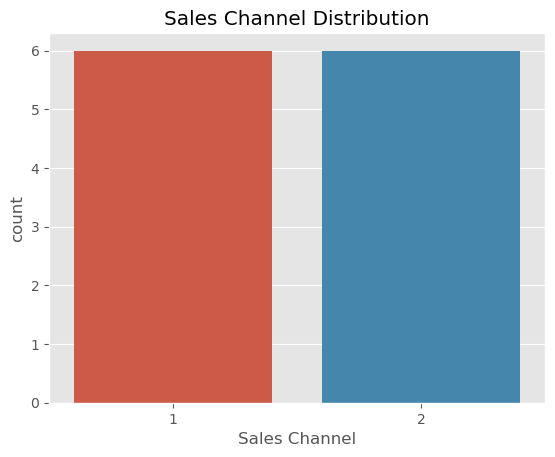

In [238]:
sb.countplot(data=Officedf, x="Sales Channel")
plt.figsize=(20, 40)
plt.title('Sales Channel Distribution')

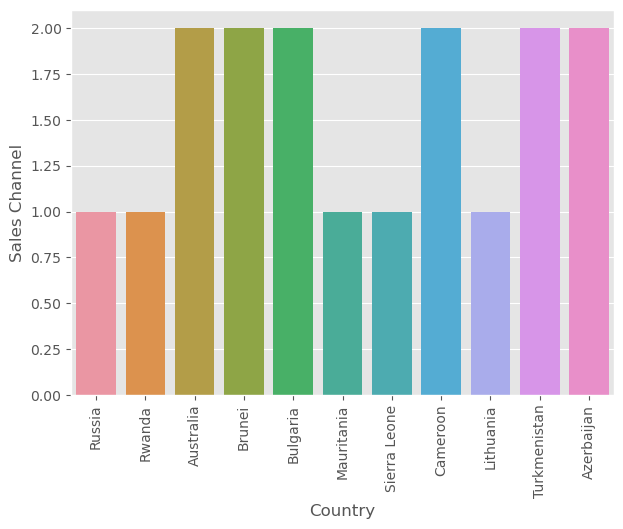

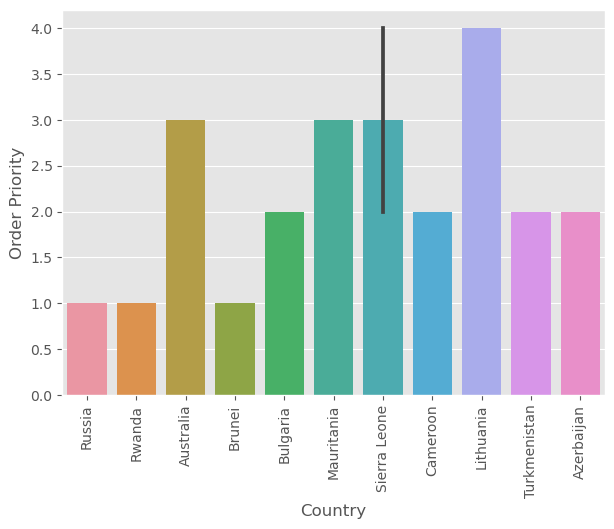

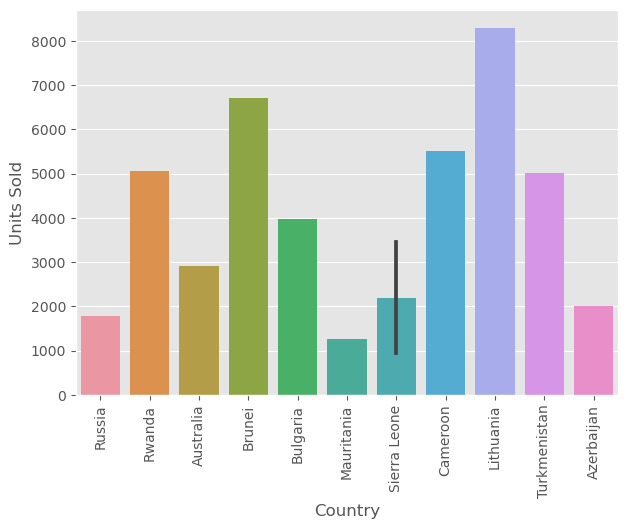

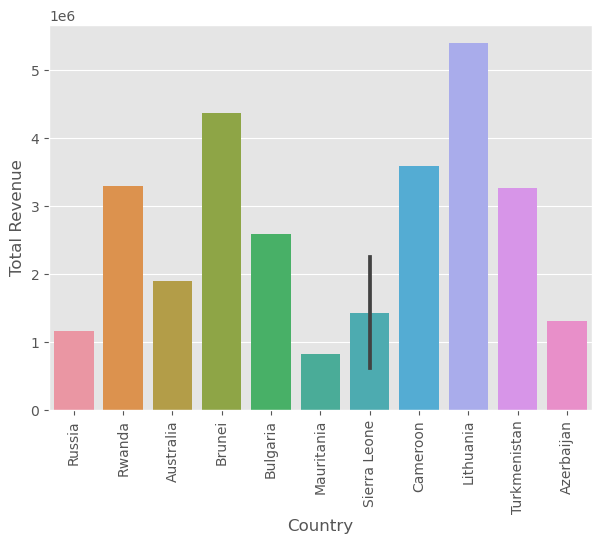

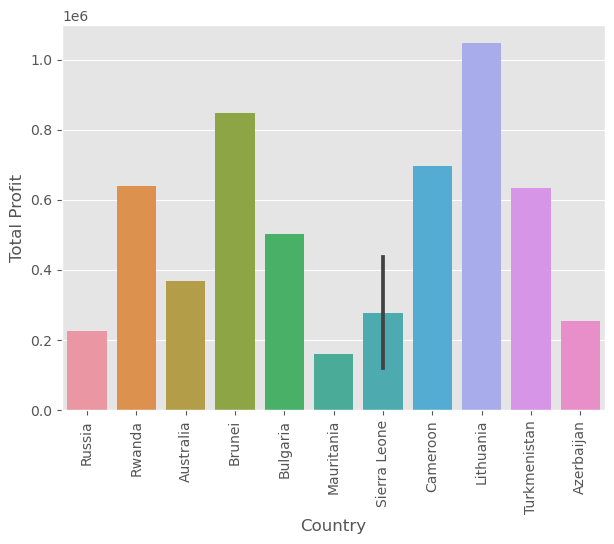

In [239]:
%matplotlib inline

def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Officedf)
    plt.xticks(rotation = 90)
    plt.show()
    


ColumnList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Country', column, Officedf)

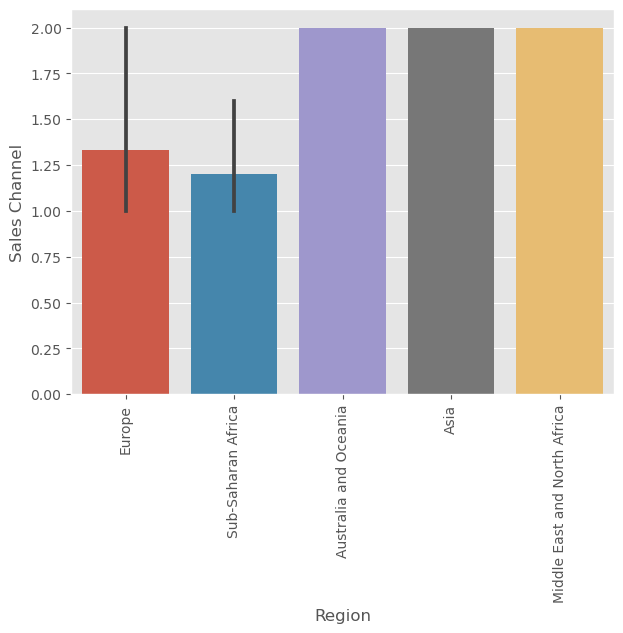

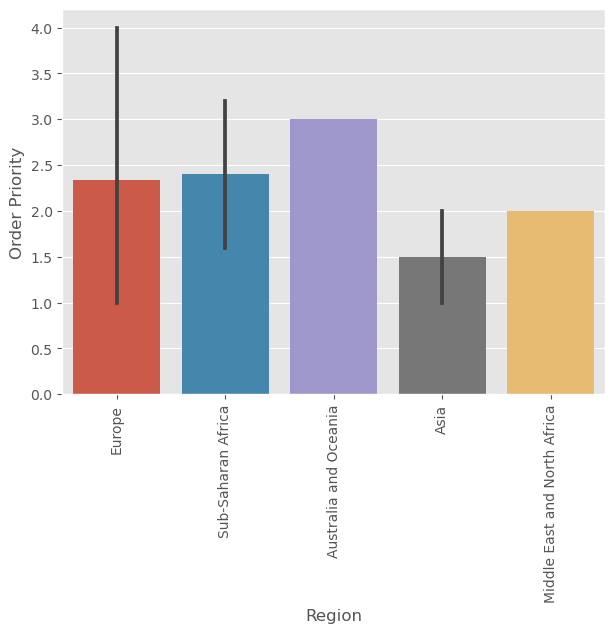

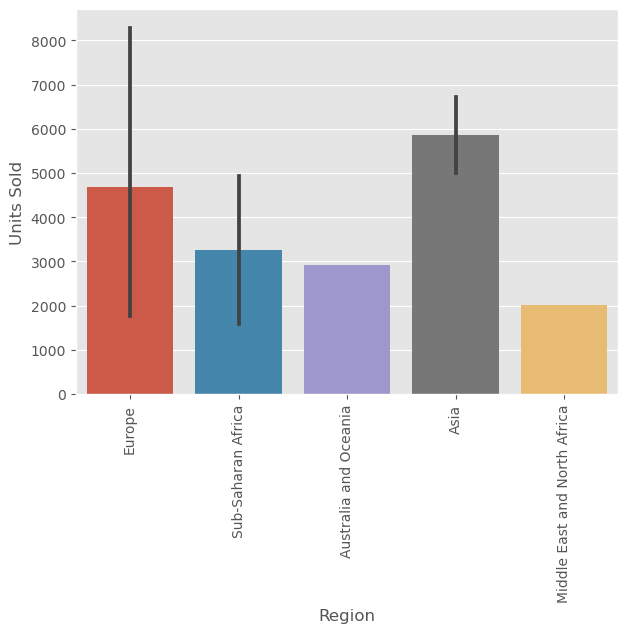

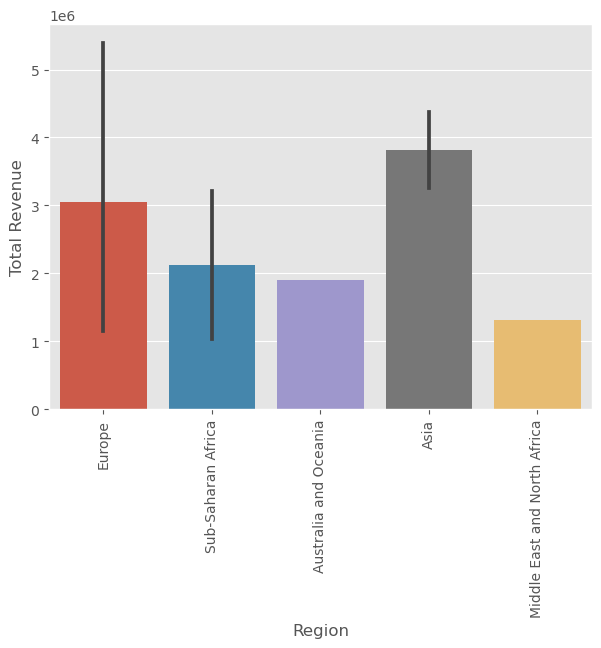

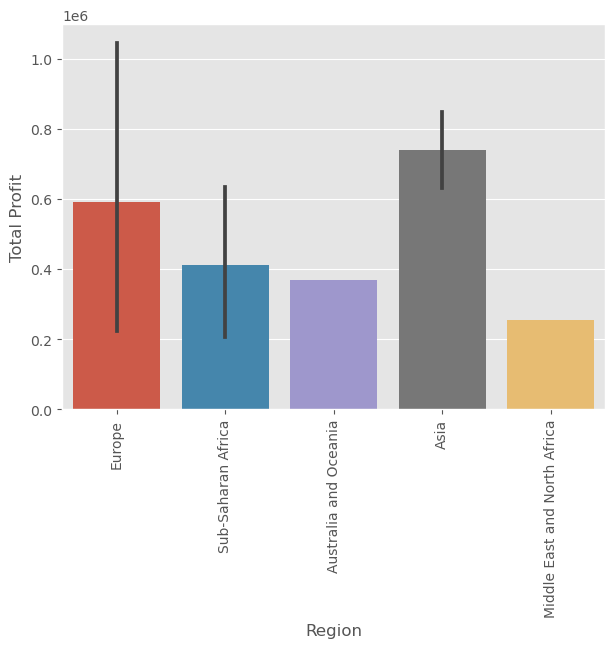

In [240]:
%matplotlib inline

def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Officedf)
    plt.xticks(rotation = 90)
    plt.show()
    


ColumnList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Region', column, Officedf)

In [81]:
Fruitdf = AmaCopydf.loc[AmaCopydf['Item Type'] == 'Fruits']

In [82]:
Fruitdf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,2,3,6/20/2014,514321792,07-05-2014,8102,9.33,6.92,75591.66,56065.84,19525.82,2014-07-05,2014-06-20,15 days
23,Australia and Oceania,New Zealand,Fruits,2,4,09-08-2014,142278373,10-04-2014,2187,9.33,6.92,20404.71,15134.04,5270.67,2014-10-04,2014-09-08,26 days
26,Australia and Oceania,Kiribati,Fruits,2,2,10/13/2014,347140347,11-10-2014,5398,9.33,6.92,50363.34,37354.16,13009.18,2014-11-10,2014-10-13,28 days
27,Sub-Saharan Africa,Mali,Fruits,2,1,05-07-2010,686048400,05-10-2010,5822,9.33,6.92,54319.26,40288.24,14031.02,2010-05-10,2010-05-07,3 days
36,Middle East and North Africa,Syria,Fruits,2,1,11/22/2011,162052476,12-03-2011,3784,9.33,6.92,35304.72,26185.28,9119.44,2011-12-03,2011-11-22,11 days
51,Sub-Saharan Africa,Lesotho,Fruits,2,1,8/18/2013,918419539,9/18/2013,9606,9.33,6.92,89623.98,66473.52,23150.46,2013-09-18,2013-08-18,31 days
54,Sub-Saharan Africa,Sao Tome and Principe,Fruits,1,4,9/17/2013,508980977,10/24/2013,7637,9.33,6.92,71253.21,52848.04,18405.17,2013-10-24,2013-09-17,37 days
71,Middle East and North Africa,Libya,Fruits,2,1,8/14/2015,816200339,9/30/2015,673,9.33,6.92,6279.09,4657.16,1621.93,2015-09-30,2015-08-14,47 days
88,Middle East and North Africa,Kuwait,Fruits,2,2,4/30/2012,513417565,5/18/2012,522,9.33,6.92,4870.26,3612.24,1258.02,2012-05-18,2012-04-30,18 days
96,Asia,Malaysia,Fruits,1,1,11-11-2011,810711038,12/28/2011,6267,9.33,6.92,58471.11,43367.64,15103.47,2011-12-28,2011-11-11,47 days


In [83]:
Fruitdf.Country.value_counts()

Sao Tome and Principe    2
New Zealand              1
Kiribati                 1
Mali                     1
Syria                    1
Lesotho                  1
Libya                    1
Kuwait                   1
Malaysia                 1
Name: Country, dtype: int64

In [84]:
Fruitdf.Region.value_counts()

Sub-Saharan Africa              4
Middle East and North Africa    3
Australia and Oceania           2
Asia                            1
Name: Region, dtype: int64

In [85]:
Fruitdf.loc[Fruitdf['orderCompTime'] == Fruitdf['orderCompTime'].max() ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
71,Middle East and North Africa,Libya,Fruits,2,1,8/14/2015,816200339,9/30/2015,673,9.33,6.92,6279.09,4657.16,1621.93,2015-09-30,2015-08-14,47 days
96,Asia,Malaysia,Fruits,1,1,11-11-2011,810711038,12/28/2011,6267,9.33,6.92,58471.11,43367.64,15103.47,2011-12-28,2011-11-11,47 days


In [86]:
Fruitdf.loc[Fruitdf['orderCompTime'] >= '20days']

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
23,Australia and Oceania,New Zealand,Fruits,2,4,09-08-2014,142278373,10-04-2014,2187,9.33,6.92,20404.71,15134.04,5270.67,2014-10-04,2014-09-08,26 days
26,Australia and Oceania,Kiribati,Fruits,2,2,10/13/2014,347140347,11-10-2014,5398,9.33,6.92,50363.34,37354.16,13009.18,2014-11-10,2014-10-13,28 days
51,Sub-Saharan Africa,Lesotho,Fruits,2,1,8/18/2013,918419539,9/18/2013,9606,9.33,6.92,89623.98,66473.52,23150.46,2013-09-18,2013-08-18,31 days
54,Sub-Saharan Africa,Sao Tome and Principe,Fruits,1,4,9/17/2013,508980977,10/24/2013,7637,9.33,6.92,71253.21,52848.04,18405.17,2013-10-24,2013-09-17,37 days
71,Middle East and North Africa,Libya,Fruits,2,1,8/14/2015,816200339,9/30/2015,673,9.33,6.92,6279.09,4657.16,1621.93,2015-09-30,2015-08-14,47 days
96,Asia,Malaysia,Fruits,1,1,11-11-2011,810711038,12/28/2011,6267,9.33,6.92,58471.11,43367.64,15103.47,2011-12-28,2011-11-11,47 days


In [87]:
Fruitdf.loc[Fruitdf['orderCompTime'] == Fruitdf['orderCompTime'].min() ]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
27,Sub-Saharan Africa,Mali,Fruits,2,1,05-07-2010,686048400,05-10-2010,5822,9.33,6.92,54319.26,40288.24,14031.02,2010-05-10,2010-05-07,3 days


In [88]:
Fruitdf.loc[Fruitdf['orderCompTime'] <= '10days']

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
27,Sub-Saharan Africa,Mali,Fruits,2,1,05-07-2010,686048400,05-10-2010,5822,9.33,6.92,54319.26,40288.24,14031.02,2010-05-10,2010-05-07,3 days


Text(0.5, 1.0, 'Sales Channel Distribution')

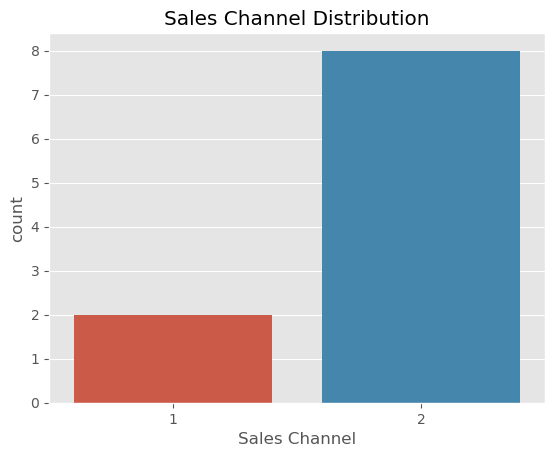

In [237]:
sb.countplot(data=Fruitdf, x="Sales Channel")
plt.figsize=(20, 40)
plt.title('Sales Channel Distribution')

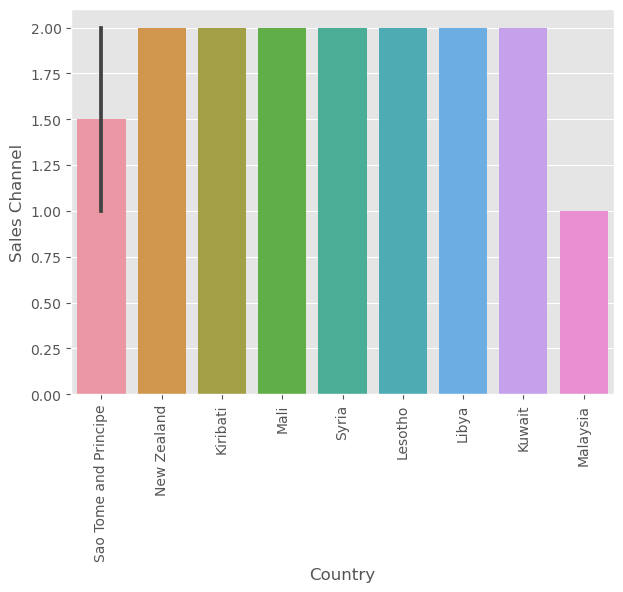

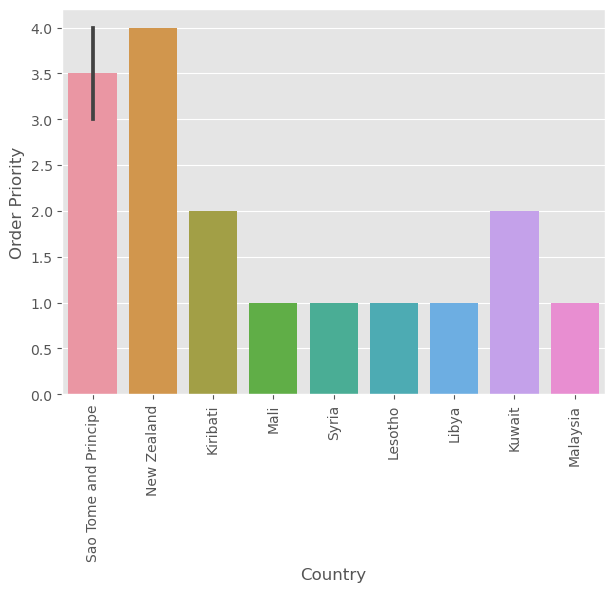

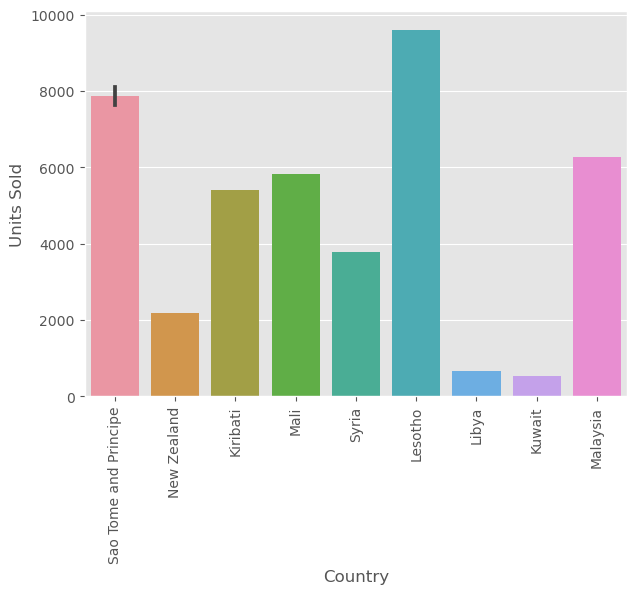

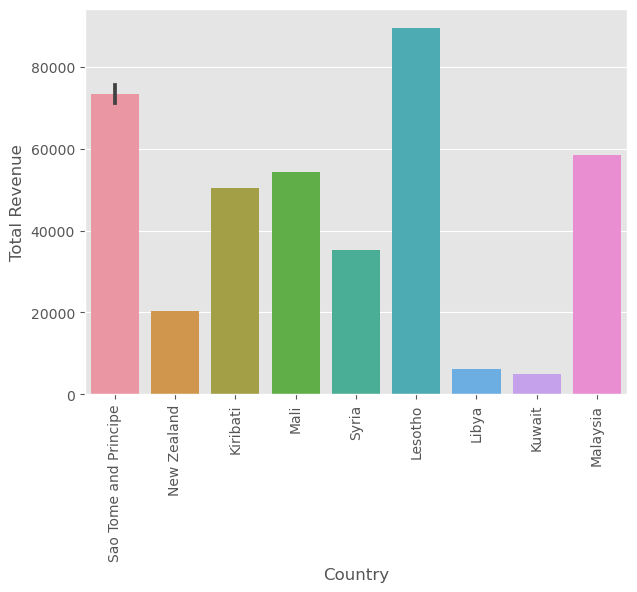

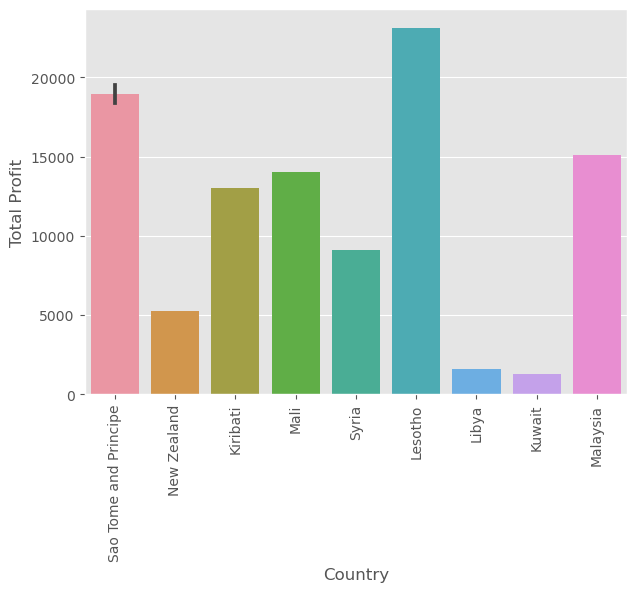

In [235]:
def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Fruitdf)
    plt.xticks(rotation = 90)
    plt.show()
    


FruitList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Country', column, Fruitdf)

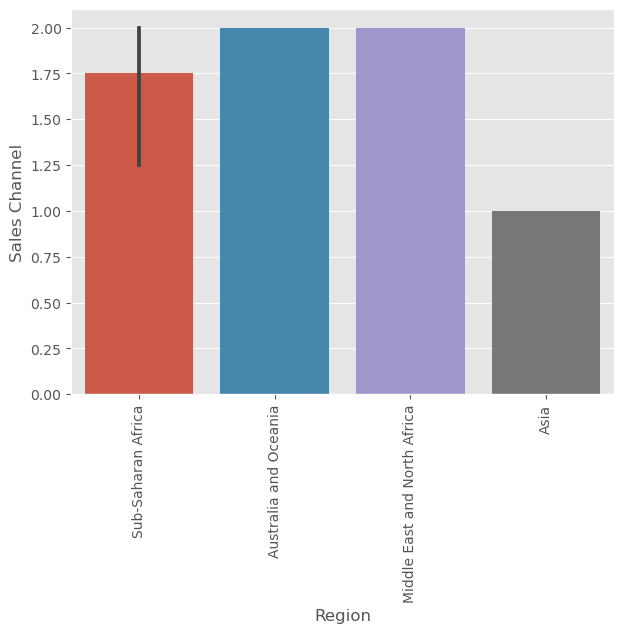

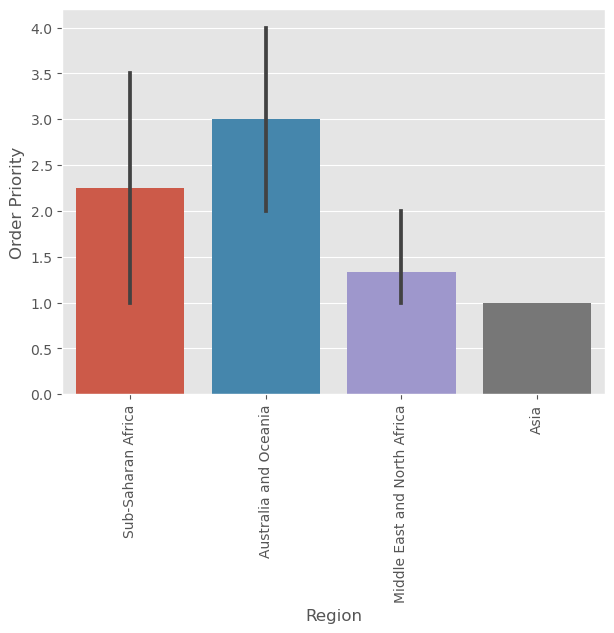

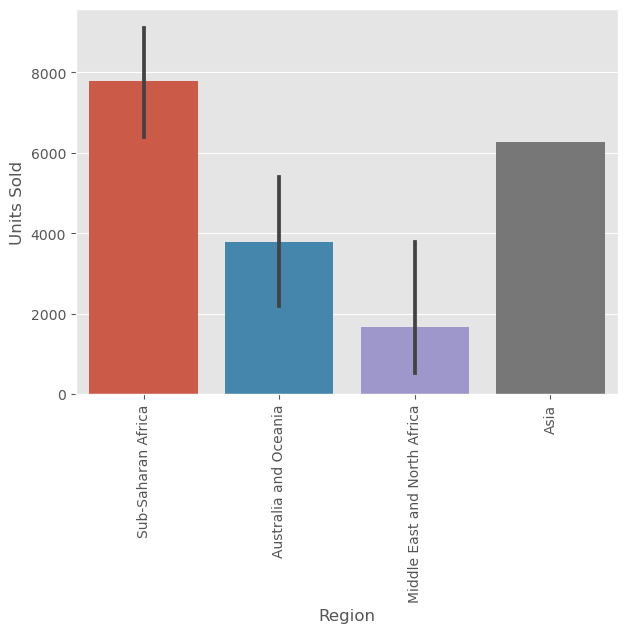

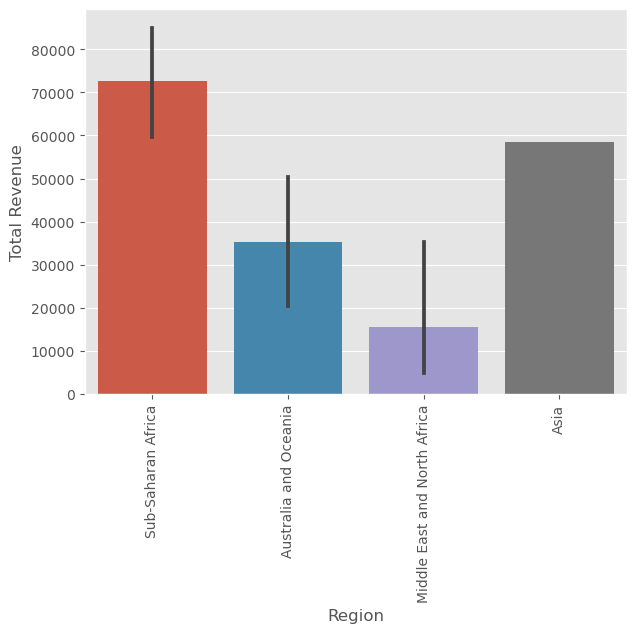

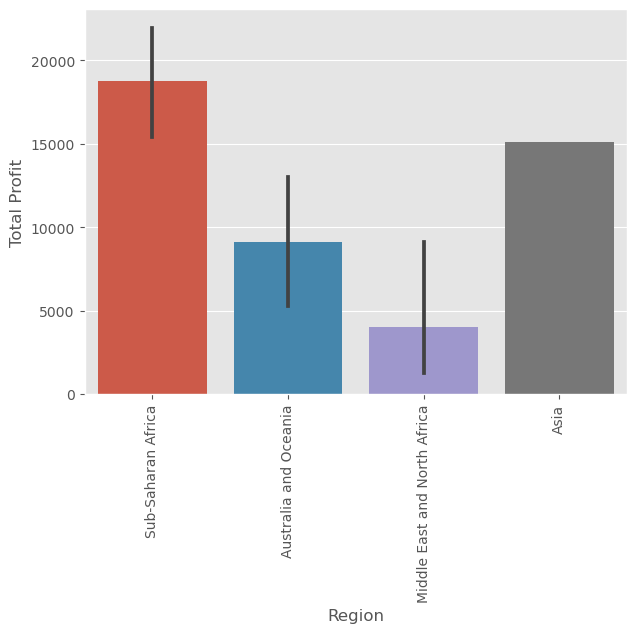

In [236]:
def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Fruitdf)
    plt.xticks(rotation = 90)
    plt.show()
    


FruitList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Region', column, Fruitdf)

In [92]:
Caredf = AmaCopydf.loc[AmaCopydf['Item Type'] == 'Personal Care']

In [93]:
Caredf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
8,Sub-Saharan Africa,Republic of the Congo,Personal Care,1,2,7/14/2015,770463311,8/25/2015,6070,81.73,56.67,496101.10,343986.90,152114.20,2015-08-25,2015-07-14,42 days
14,Asia,Mongolia,Personal Care,1,3,2/19/2014,832401311,2/23/2014,4901,81.73,56.67,400558.73,277739.67,122819.06,2014-02-23,2014-02-19,4 days
24,Europe,Moldova,Personal Care,2,1,05-07-2016,740147912,05-10-2016,5070,81.73,56.67,414371.10,287316.90,127054.20,2016-05-10,2016-05-07,3 days
31,Sub-Saharan Africa,South Sudan,Personal Care,1,3,12/29/2013,406502997,1/28/2014,2125,81.73,56.67,173676.25,120423.75,53252.50,2014-01-28,2013-12-29,30 days
35,Central America and the Caribbean,Costa Rica,Personal Care,1,1,05-08-2017,456767165,5/21/2017,6409,81.73,56.67,523807.57,363198.03,160609.54,2017-05-21,2017-05-08,13 days
40,Sub-Saharan Africa,Niger,Personal Care,2,4,03-11-2017,699285638,3/28/2017,3015,81.73,56.67,246415.95,170860.05,75555.90,2017-03-28,2017-03-11,17 days
47,Europe,Switzerland,Personal Care,2,2,12/23/2010,617667090,1/31/2011,273,81.73,56.67,22312.29,15470.91,6841.38,2011-01-31,2010-12-23,39 days
66,Sub-Saharan Africa,Gabon,Personal Care,1,1,07-08-2012,228944623,07-09-2012,8656,81.73,56.67,707454.88,490535.52,216919.36,2012-07-09,2012-07-08,1 days
85,North America,Mexico,Personal Care,1,1,2/17/2012,430915820,3/20/2012,6422,81.73,56.67,524870.06,363934.74,160935.32,2012-03-20,2012-02-17,32 days
98,North America,Mexico,Personal Care,1,2,7/30/2015,559427106,08-08-2015,5767,81.73,56.67,471336.91,326815.89,144521.02,2015-08-08,2015-07-30,9 days


In [94]:
Caredf.Country.value_counts()

Mexico                   2
Republic of the Congo    1
Mongolia                 1
Moldova                  1
South Sudan              1
Costa Rica               1
Niger                    1
Switzerland              1
Gabon                    1
Name: Country, dtype: int64

In [95]:
Caredf.Region.value_counts()

Sub-Saharan Africa                   4
Europe                               2
North America                        2
Asia                                 1
Central America and the Caribbean    1
Name: Region, dtype: int64

In [96]:
Caredf.loc[Caredf['orderCompTime'] == Caredf['orderCompTime'].max()]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
8,Sub-Saharan Africa,Republic of the Congo,Personal Care,1,2,7/14/2015,770463311,8/25/2015,6070,81.73,56.67,496101.1,343986.9,152114.2,2015-08-25,2015-07-14,42 days


In [97]:
Caredf.loc[Caredf['orderCompTime'] >= '20days']

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
8,Sub-Saharan Africa,Republic of the Congo,Personal Care,1,2,7/14/2015,770463311,8/25/2015,6070,81.73,56.67,496101.10,343986.90,152114.20,2015-08-25,2015-07-14,42 days
31,Sub-Saharan Africa,South Sudan,Personal Care,1,3,12/29/2013,406502997,1/28/2014,2125,81.73,56.67,173676.25,120423.75,53252.50,2014-01-28,2013-12-29,30 days
47,Europe,Switzerland,Personal Care,2,2,12/23/2010,617667090,1/31/2011,273,81.73,56.67,22312.29,15470.91,6841.38,2011-01-31,2010-12-23,39 days
85,North America,Mexico,Personal Care,1,1,2/17/2012,430915820,3/20/2012,6422,81.73,56.67,524870.06,363934.74,160935.32,2012-03-20,2012-02-17,32 days


In [98]:
Caredf.loc[Caredf['orderCompTime'] == Caredf['orderCompTime'].min()]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
66,Sub-Saharan Africa,Gabon,Personal Care,1,1,07-08-2012,228944623,07-09-2012,8656,81.73,56.67,707454.88,490535.52,216919.36,2012-07-09,2012-07-08,1 days


In [99]:
Caredf.loc[Caredf['orderCompTime'] <= '10days']

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
14,Asia,Mongolia,Personal Care,1,3,2/19/2014,832401311,2/23/2014,4901,81.73,56.67,400558.73,277739.67,122819.06,2014-02-23,2014-02-19,4 days
24,Europe,Moldova,Personal Care,2,1,05-07-2016,740147912,05-10-2016,5070,81.73,56.67,414371.10,287316.90,127054.20,2016-05-10,2016-05-07,3 days
66,Sub-Saharan Africa,Gabon,Personal Care,1,1,07-08-2012,228944623,07-09-2012,8656,81.73,56.67,707454.88,490535.52,216919.36,2012-07-09,2012-07-08,1 days
98,North America,Mexico,Personal Care,1,2,7/30/2015,559427106,08-08-2015,5767,81.73,56.67,471336.91,326815.89,144521.02,2015-08-08,2015-07-30,9 days


Text(0.5, 1.0, 'Sales Channel Distribution')

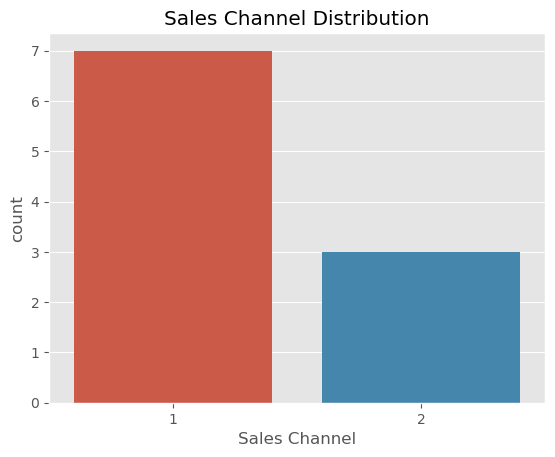

In [234]:
sb.countplot(data=Caredf, x="Sales Channel")
plt.figsize=(20, 40)
plt.title('Sales Channel Distribution')

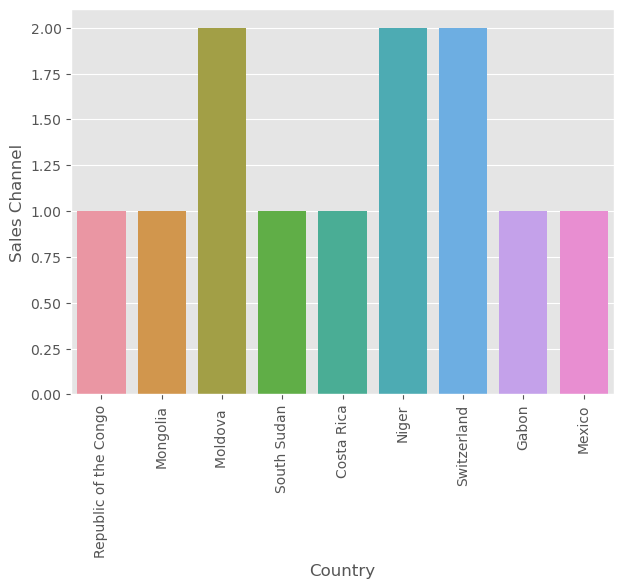

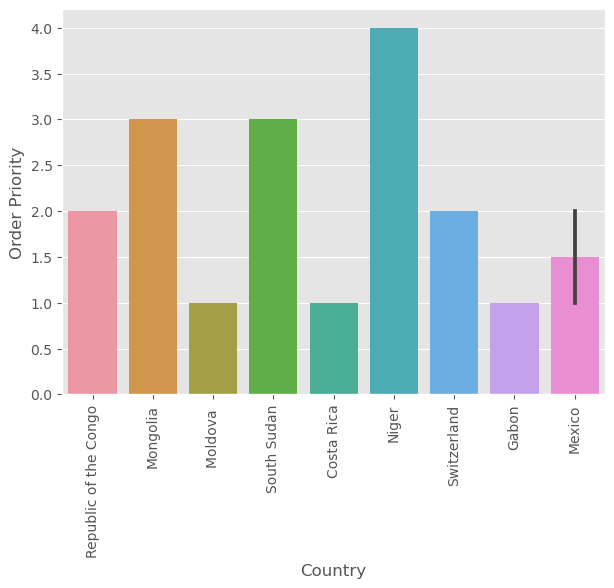

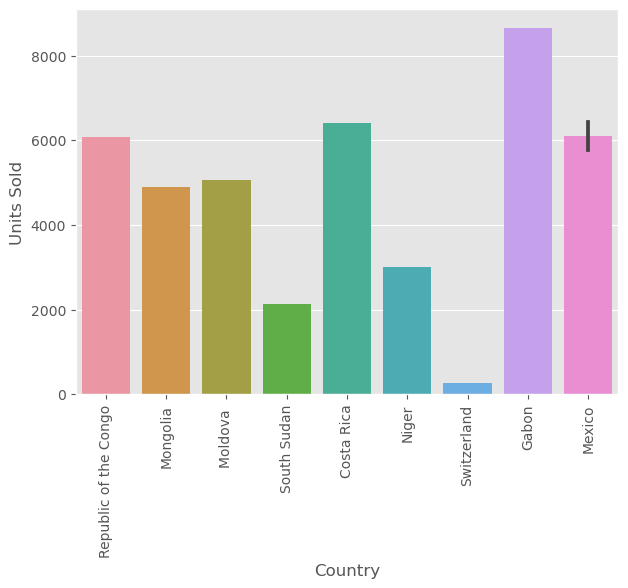

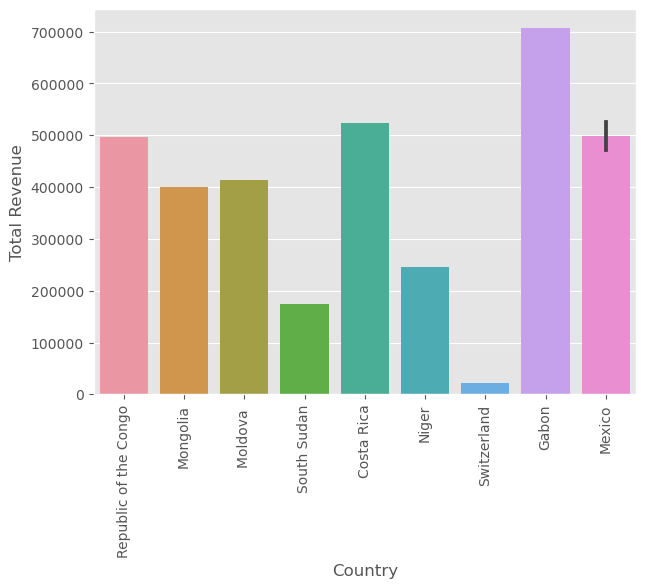

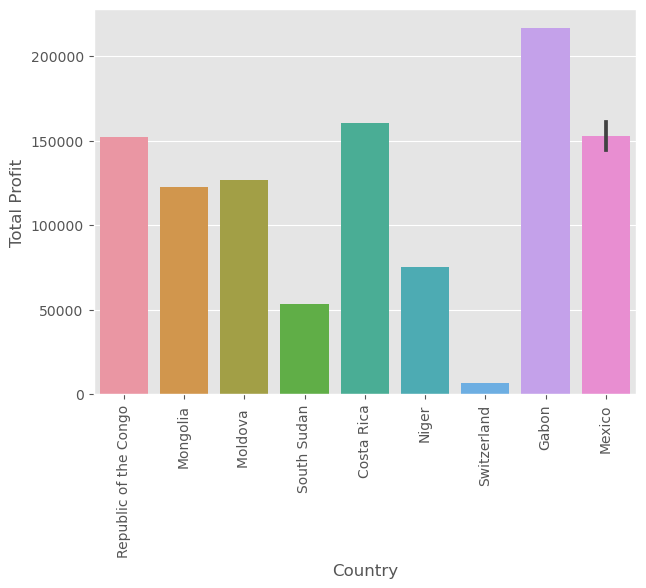

In [233]:
def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Caredf)
    plt.xticks(rotation = 90)
    plt.show()
    


FruitList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Country', column, Caredf)

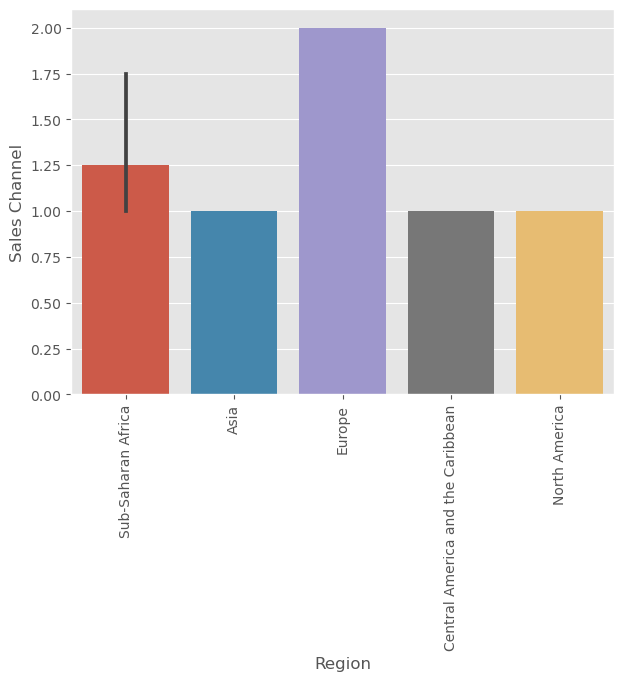

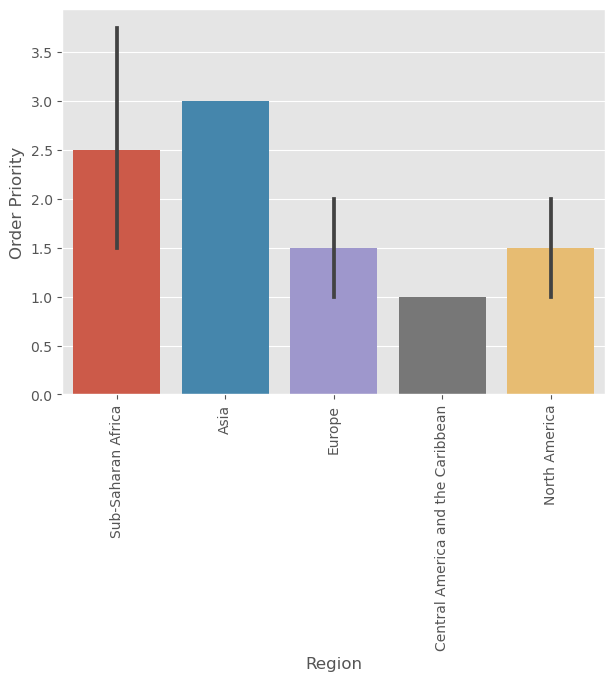

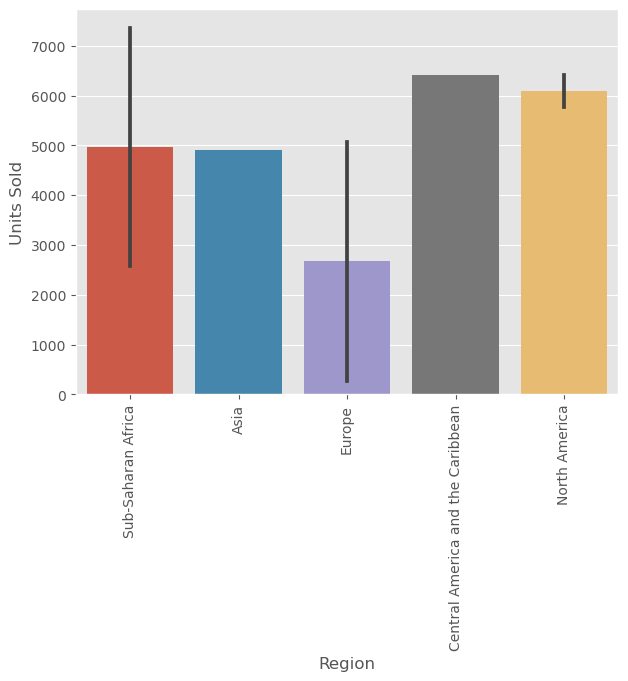

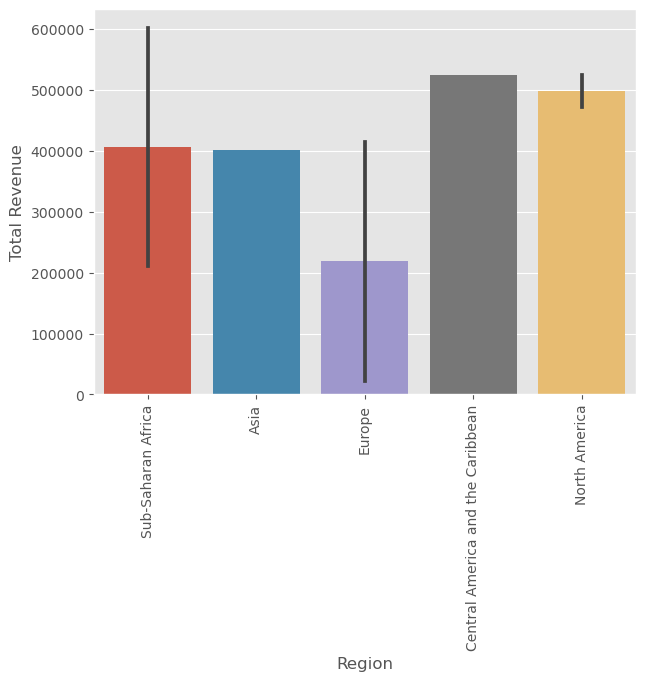

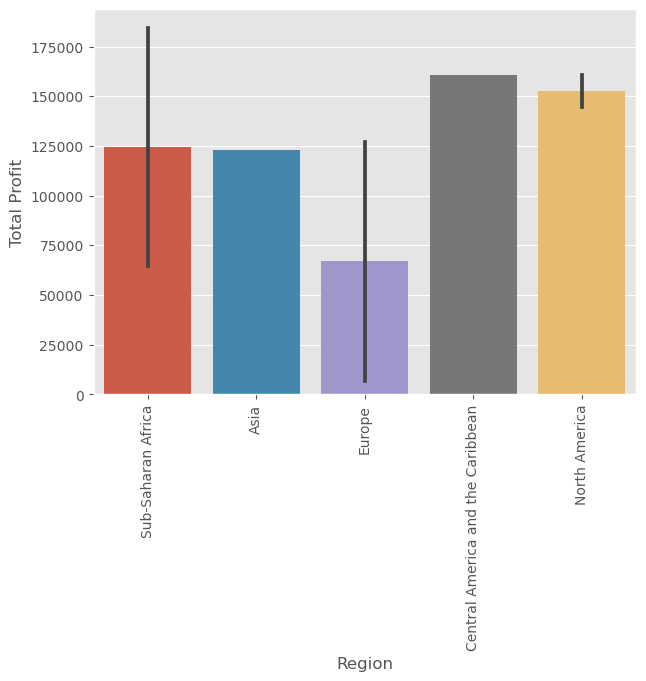

In [232]:
def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Caredf)
    plt.xticks(rotation = 90)
    plt.show()
    


FruitList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Region', column, Caredf)

In [103]:
Bevdf = AmaCopydf.loc[AmaCopydf['Item Type'] == 'Beverages']

In [104]:
Bevdf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
17,Sub-Saharan Africa,Cameroon,Beverages,1,3,04-01-2015,519820964,4/18/2015,5430,47.45,31.79,257653.50,172619.70,85033.80,2015-04-18,2015-04-01,17 days
28,Europe,Norway,Beverages,1,3,7/18/2014,435608613,7/30/2014,5124,47.45,31.79,243133.80,162891.96,80241.84,2014-07-30,2014-07-18,12 days
72,Sub-Saharan Africa,Democratic Republic of the Congo,Beverages,2,3,5/26/2011,585920464,7/15/2011,5741,47.45,31.79,272410.45,182506.39,89904.06,2011-07-15,2011-05-26,50 days
76,Australia and Oceania,Federated States of Micronesia,Beverages,2,3,10/28/2014,217221009,11/15/2014,9379,47.45,31.79,445033.55,298158.41,146875.14,2014-11-15,2014-10-28,18 days
86,Sub-Saharan Africa,Sao Tome and Principe,Beverages,1,3,1/16/2011,180283772,1/21/2011,8829,47.45,31.79,418936.05,280673.91,138262.14,2011-01-21,2011-01-16,5 days
89,Europe,Slovenia,Beverages,1,3,10/23/2016,345718562,11/25/2016,4660,47.45,31.79,221117.00,148141.40,72975.60,2016-11-25,2016-10-23,33 days
91,Australia and Oceania,Australia,Beverages,1,4,07-07-2014,240470397,07-11-2014,9389,47.45,31.79,445508.05,298476.31,147031.74,2014-07-11,2014-07-07,4 days
94,Central America and the Caribbean,Nicaragua,Beverages,1,3,02-08-2011,963392674,3/21/2011,8156,47.45,31.79,387002.20,259279.24,127722.96,2011-03-21,2011-02-08,41 days


In [105]:
Bevdf.Country.value_counts()

Cameroon                            1
Norway                              1
Democratic Republic of the Congo    1
Federated States of Micronesia      1
Sao Tome and Principe               1
Slovenia                            1
Australia                           1
Nicaragua                           1
Name: Country, dtype: int64

In [106]:
Bevdf.Region.value_counts()

Sub-Saharan Africa                   3
Europe                               2
Australia and Oceania                2
Central America and the Caribbean    1
Name: Region, dtype: int64

In [107]:
Bevdf.loc[Bevdf['orderCompTime'] == Bevdf['orderCompTime'].max()]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
72,Sub-Saharan Africa,Democratic Republic of the Congo,Beverages,2,3,5/26/2011,585920464,7/15/2011,5741,47.45,31.79,272410.45,182506.39,89904.06,2011-07-15,2011-05-26,50 days


In [108]:
Bevdf.loc[Bevdf['orderCompTime'] >= '20days']

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
72,Sub-Saharan Africa,Democratic Republic of the Congo,Beverages,2,3,5/26/2011,585920464,7/15/2011,5741,47.45,31.79,272410.45,182506.39,89904.06,2011-07-15,2011-05-26,50 days
89,Europe,Slovenia,Beverages,1,3,10/23/2016,345718562,11/25/2016,4660,47.45,31.79,221117.00,148141.40,72975.60,2016-11-25,2016-10-23,33 days
94,Central America and the Caribbean,Nicaragua,Beverages,1,3,02-08-2011,963392674,3/21/2011,8156,47.45,31.79,387002.20,259279.24,127722.96,2011-03-21,2011-02-08,41 days


In [109]:
Bevdf.loc[Bevdf['orderCompTime'] == Bevdf['orderCompTime'].min()]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
91,Australia and Oceania,Australia,Beverages,1,4,07-07-2014,240470397,07-11-2014,9389,47.45,31.79,445508.05,298476.31,147031.74,2014-07-11,2014-07-07,4 days


In [110]:
Bevdf.loc[Bevdf['orderCompTime'] >= '10days']

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
17,Sub-Saharan Africa,Cameroon,Beverages,1,3,04-01-2015,519820964,4/18/2015,5430,47.45,31.79,257653.50,172619.70,85033.80,2015-04-18,2015-04-01,17 days
28,Europe,Norway,Beverages,1,3,7/18/2014,435608613,7/30/2014,5124,47.45,31.79,243133.80,162891.96,80241.84,2014-07-30,2014-07-18,12 days
72,Sub-Saharan Africa,Democratic Republic of the Congo,Beverages,2,3,5/26/2011,585920464,7/15/2011,5741,47.45,31.79,272410.45,182506.39,89904.06,2011-07-15,2011-05-26,50 days
76,Australia and Oceania,Federated States of Micronesia,Beverages,2,3,10/28/2014,217221009,11/15/2014,9379,47.45,31.79,445033.55,298158.41,146875.14,2014-11-15,2014-10-28,18 days
89,Europe,Slovenia,Beverages,1,3,10/23/2016,345718562,11/25/2016,4660,47.45,31.79,221117.00,148141.40,72975.60,2016-11-25,2016-10-23,33 days
94,Central America and the Caribbean,Nicaragua,Beverages,1,3,02-08-2011,963392674,3/21/2011,8156,47.45,31.79,387002.20,259279.24,127722.96,2011-03-21,2011-02-08,41 days


Text(0.5, 1.0, 'Sales Channel Distribution')

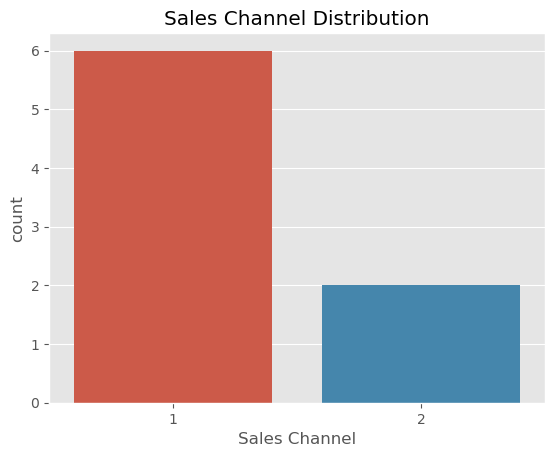

In [231]:
sb.countplot(data=Bevdf, x="Sales Channel")
plt.figsize=(20, 40)
plt.title('Sales Channel Distribution')

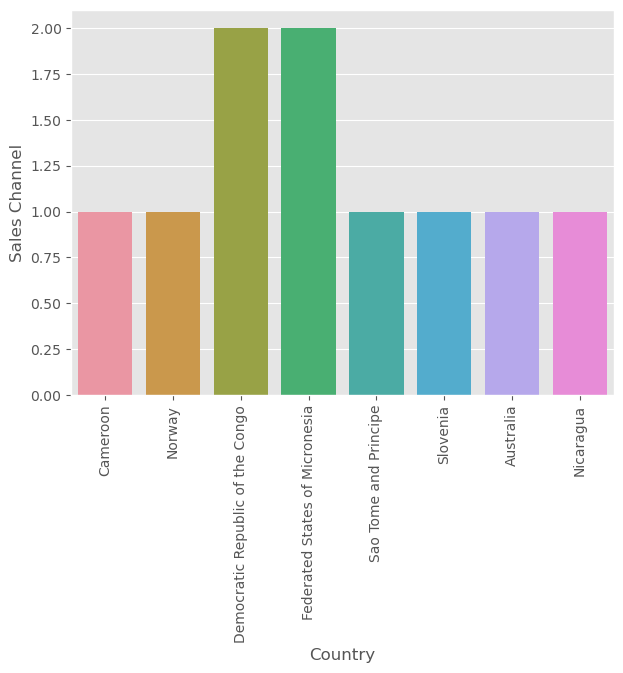

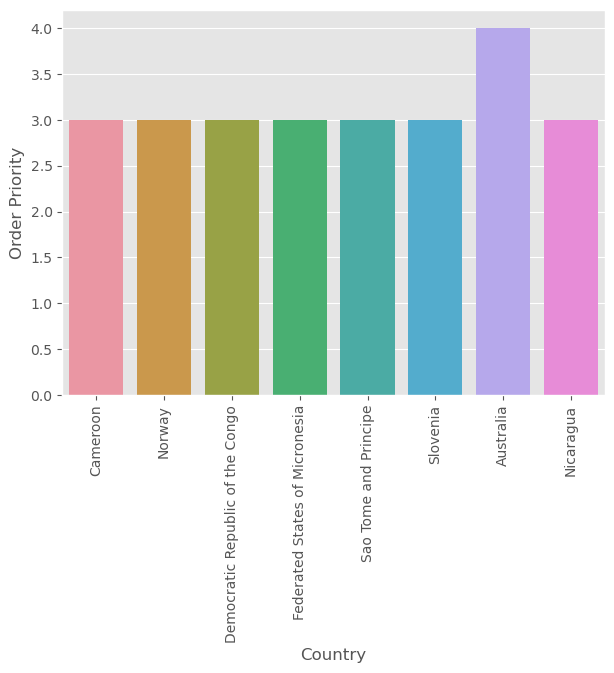

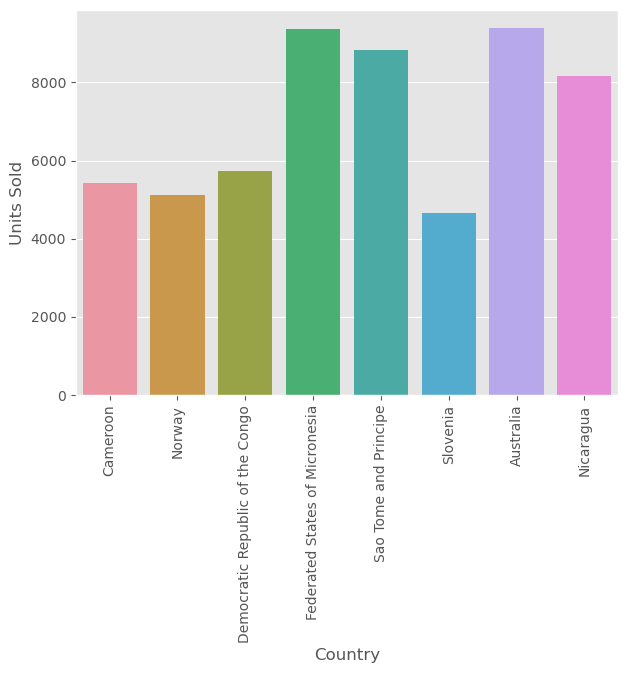

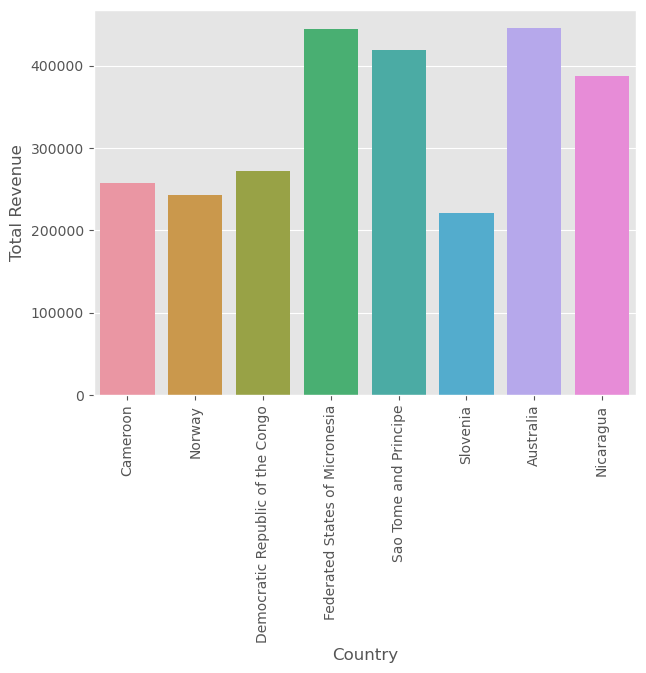

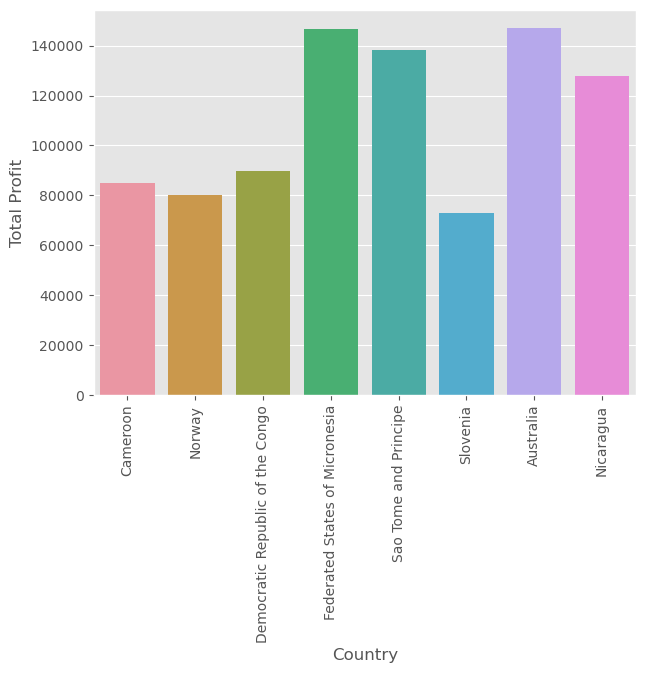

In [230]:
def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Bevdf)
    plt.xticks(rotation = 90)
    plt.show()
    


FruitList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Country', column, Bevdf)

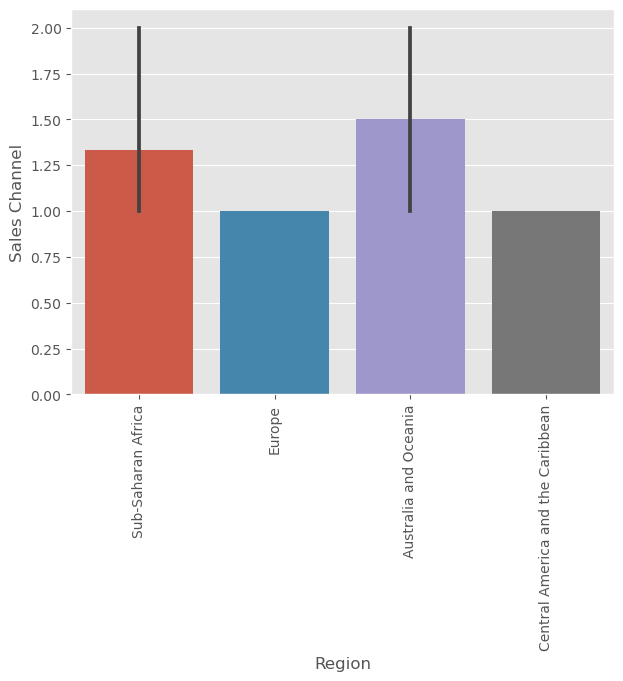

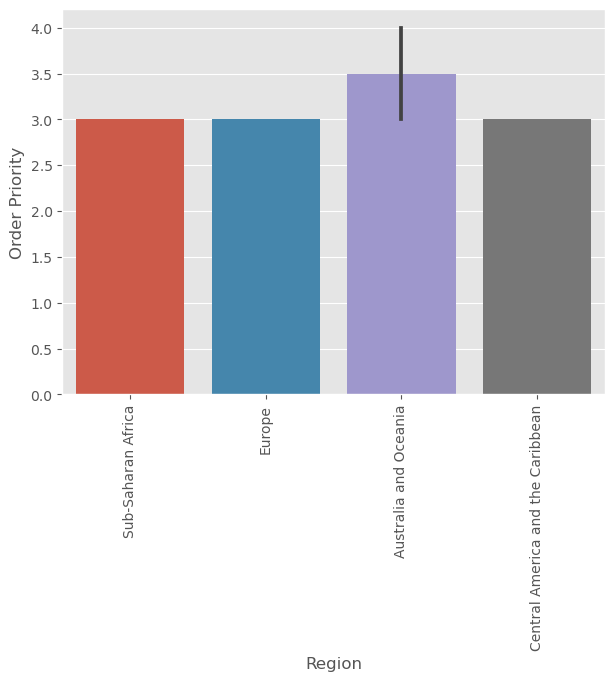

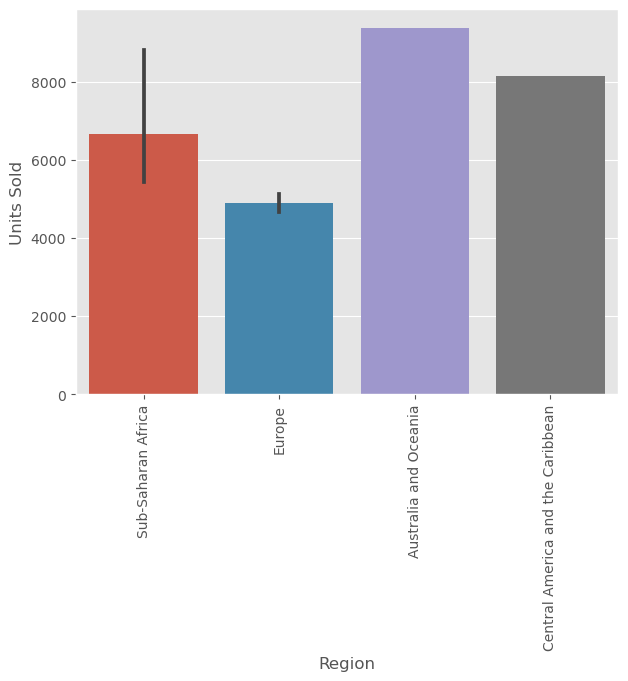

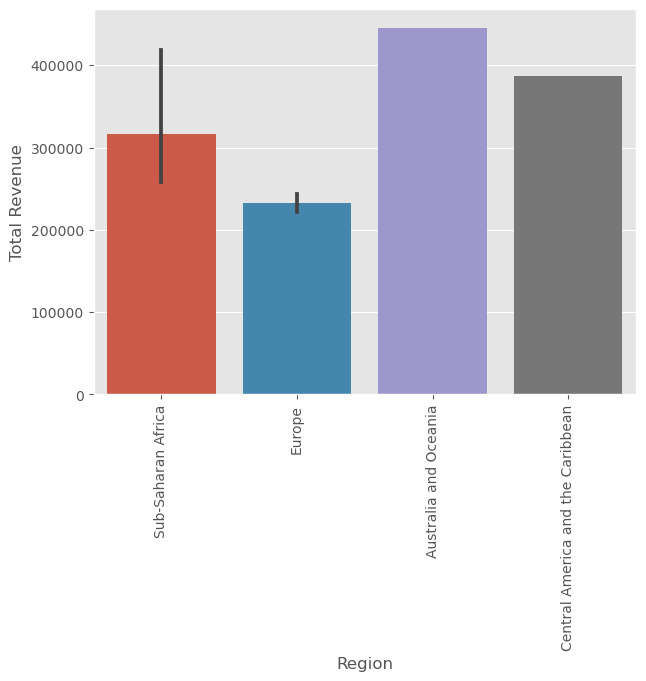

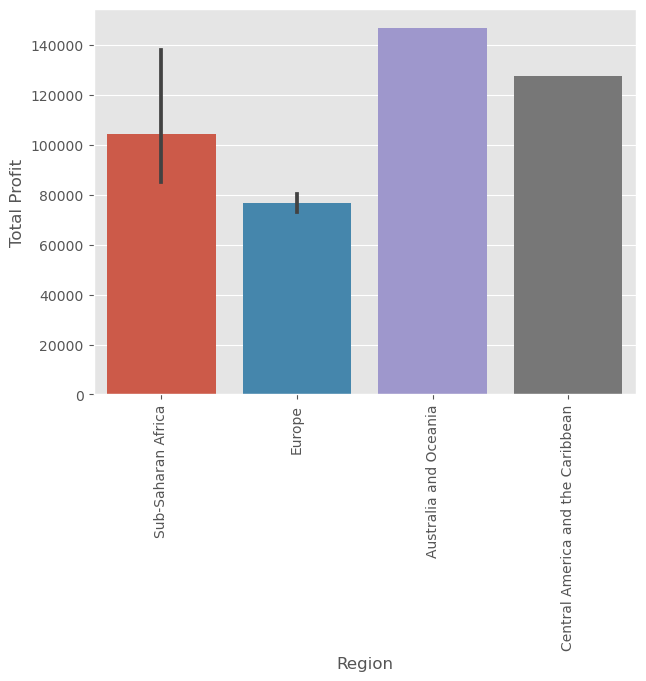

In [229]:
def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Bevdf)
    plt.xticks(rotation = 90)
    plt.show()
    


FruitList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Region', column, Bevdf)

In [114]:
Babydf = AmaCopydf.loc[AmaCopydf['Item Type'] == 'Baby Food']

In [115]:
Babydf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
0,Australia and Oceania,Tuvalu,Baby Food,1,4,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50,2010-06-27,2010-05-28,30 days
5,Australia and Oceania,Solomon Islands,Baby Food,2,3,02-04-2015,547995746,2/21/2015,2974,255.28,159.42,759202.72,474115.08,285087.64,2015-02-21,2015-02-04,17 days
20,Europe,Norway,Baby Food,2,1,5/14/2014,819028031,6/28/2014,7450,255.28,159.42,1901836.00,1187679.00,714157.00,2014-06-28,2014-05-14,45 days
21,Europe,Portugal,Baby Food,2,4,7/31/2015,860673511,09-03-2015,1273,255.28,159.42,324971.44,202941.66,122029.78,2015-09-03,2015-07-31,34 days
61,Europe,San Marino,Baby Food,2,1,6/26/2013,569662845,07-01-2013,4750,255.28,159.42,1212580.00,757245.00,455335.00,2013-07-01,2013-06-26,5 days
78,Europe,Monaco,Baby Food,1,4,5/29/2012,688288152,06-02-2012,8614,255.28,159.42,2198981.92,1373243.88,825738.04,2012-06-02,2012-05-29,4 days
87,Sub-Saharan Africa,The Gambia,Baby Food,1,2,02-03-2014,494747245,3/20/2014,5559,255.28,159.42,1419101.52,886215.78,532885.74,2014-03-20,2014-02-03,45 days


In [116]:
Babydf.Country.value_counts()

Tuvalu             1
Solomon Islands    1
Norway             1
Portugal           1
San Marino         1
Monaco             1
The Gambia         1
Name: Country, dtype: int64

In [117]:
Babydf.Region.value_counts()

Europe                   4
Australia and Oceania    2
Sub-Saharan Africa       1
Name: Region, dtype: int64

In [118]:
Babydf.loc[Babydf['orderCompTime'] == Babydf['orderCompTime'].max()]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
20,Europe,Norway,Baby Food,2,1,5/14/2014,819028031,6/28/2014,7450,255.28,159.42,1901836.00,1187679.00,714157.00,2014-06-28,2014-05-14,45 days
87,Sub-Saharan Africa,The Gambia,Baby Food,1,2,02-03-2014,494747245,3/20/2014,5559,255.28,159.42,1419101.52,886215.78,532885.74,2014-03-20,2014-02-03,45 days


In [119]:
Babydf.loc[Babydf['orderCompTime'] == Babydf['orderCompTime'].min()]

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
78,Europe,Monaco,Baby Food,1,4,5/29/2012,688288152,06-02-2012,8614,255.28,159.42,2198981.92,1373243.88,825738.04,2012-06-02,2012-05-29,4 days


Text(0.5, 1.0, 'Sales Channel Distribution')

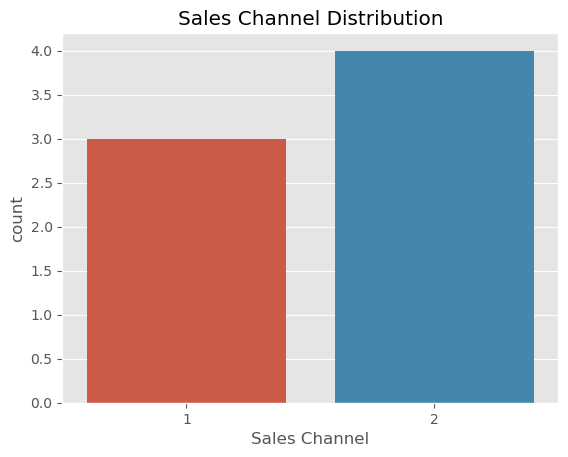

In [228]:
sb.countplot(data=Babydf, x="Sales Channel")
plt.figsize=(20, 40)
plt.title('Sales Channel Distribution')

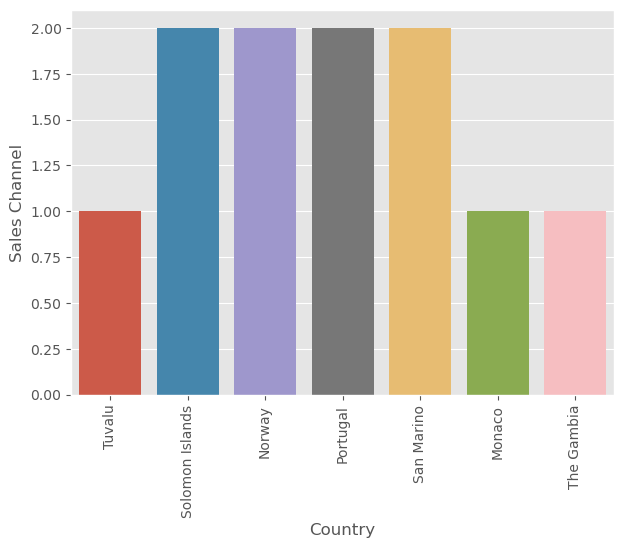

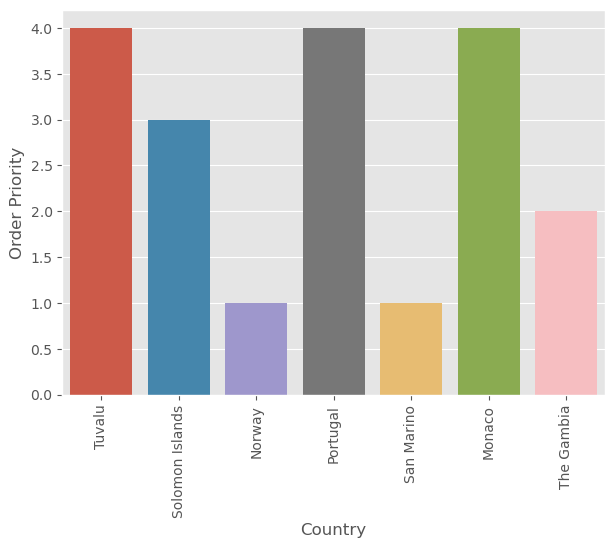

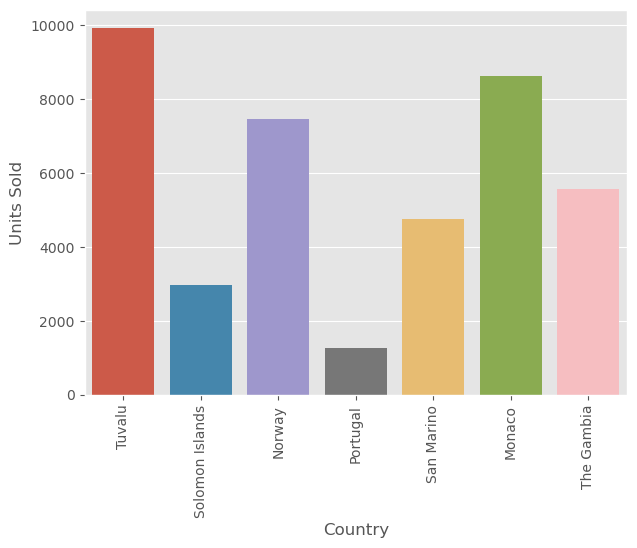

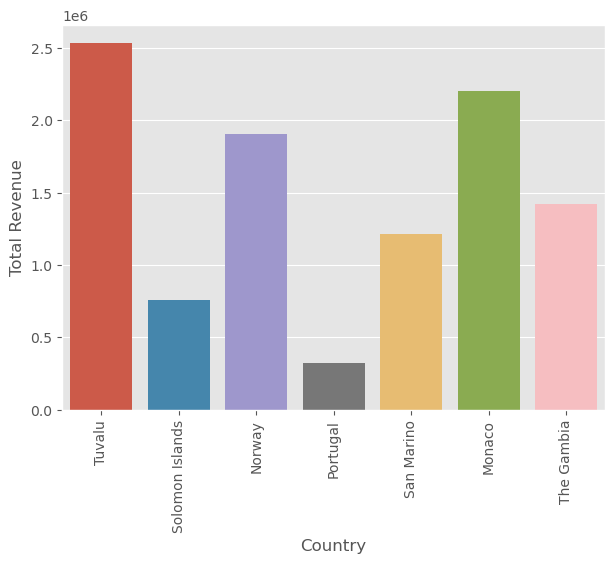

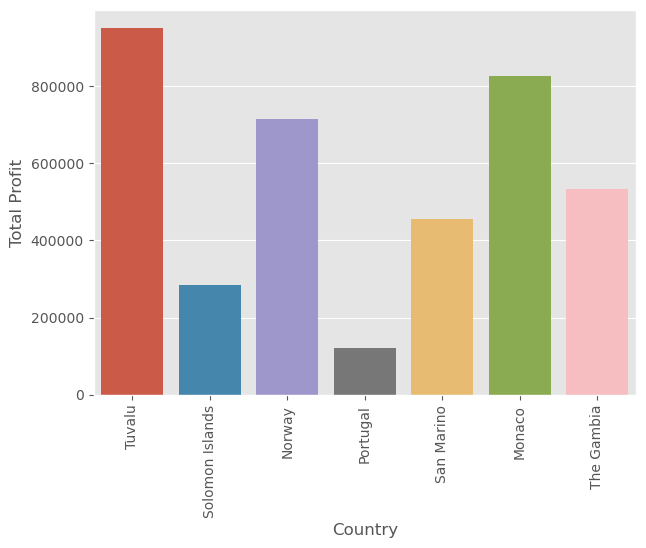

In [226]:
def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Babydf)
    plt.xticks(rotation = 90)
    plt.show()
    


FruitList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Country', column, Babydf)

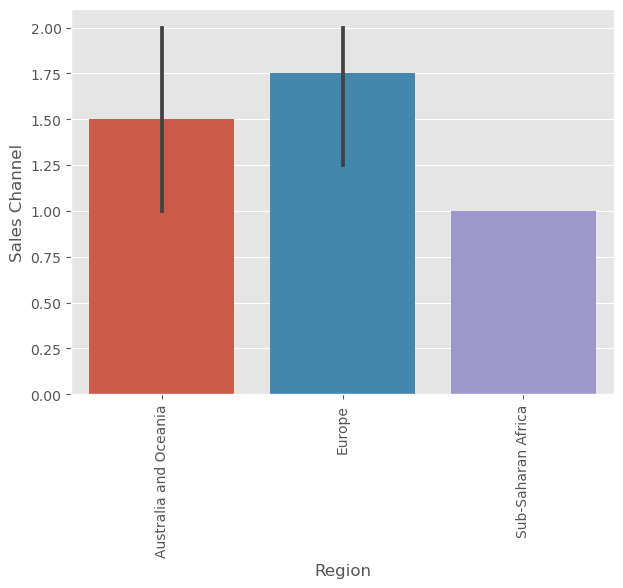

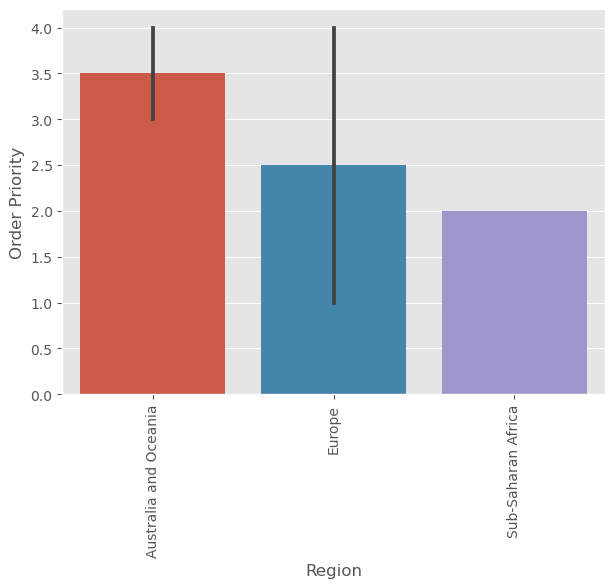

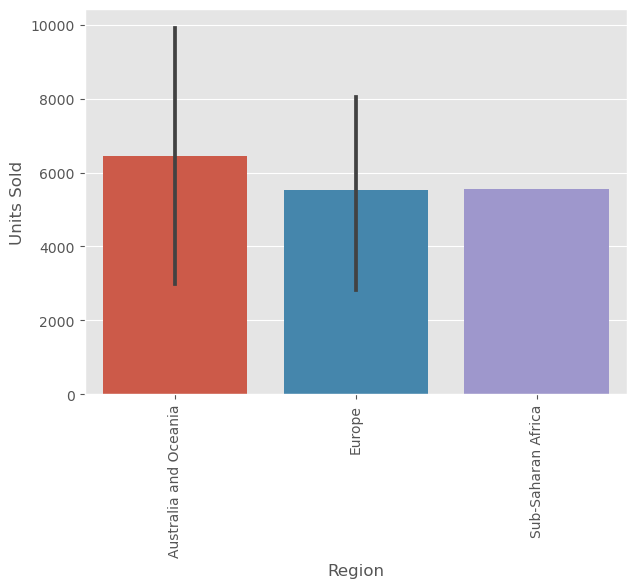

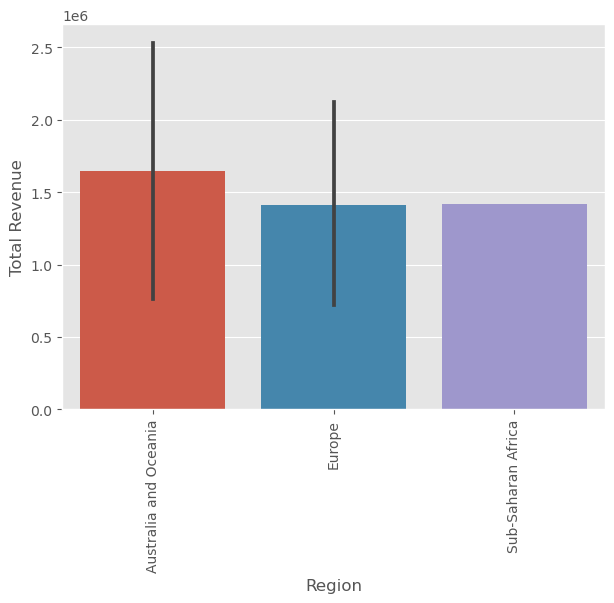

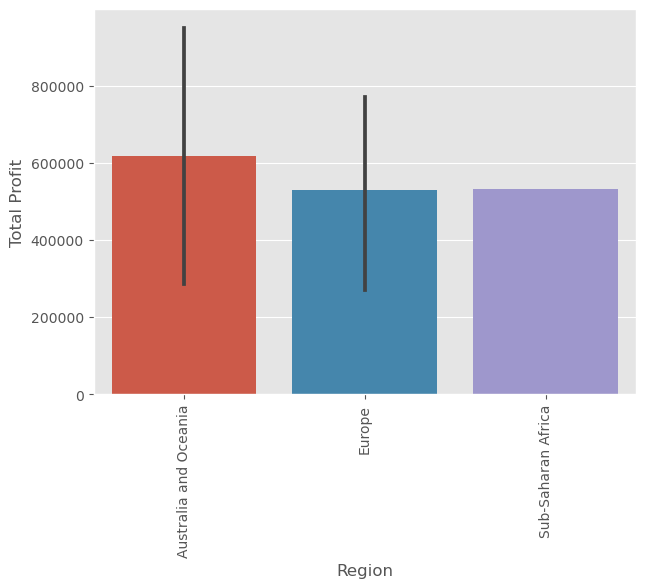

In [227]:
def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Babydf)
    plt.xticks(rotation = 90)
    plt.show()
    


FruitList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Region', column, Babydf)

In [123]:
Cerealdf = AmaCopydf.loc[AmaCopydf['Item Type'] == 'Cereal']

In [124]:
Cerealdf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
1,Central America and the Caribbean,Grenada,Cereal,2,3,8/22/2012,963881480,9/15/2012,2804,205.7,117.11,576782.8,328376.44,248406.36,2012-09-15,2012-08-22,24 days
9,Sub-Saharan Africa,Senegal,Cereal,2,4,4/18/2014,616607081,5/30/2014,6593,205.7,117.11,1356180.1,772106.23,584073.87,2014-05-30,2014-04-18,42 days
42,Sub-Saharan Africa,The Gambia,Cereal,1,4,06-07-2012,994022214,06-08-2012,2117,205.7,117.11,435466.9,247921.87,187545.03,2012-06-08,2012-06-07,1 days
45,Sub-Saharan Africa,Comoros,Cereal,1,4,3/29/2016,902102267,4/29/2016,962,205.7,117.11,197883.4,112659.82,85223.58,2016-04-29,2016-03-29,31 days
52,Middle East and North Africa,Saudi Arabia,Cereal,2,2,3/25/2013,844530045,3/28/2013,4063,205.7,117.11,835759.1,475817.93,359941.17,2013-03-28,2013-03-25,3 days
60,Australia and Oceania,Australia,Cereal,1,4,06-09-2013,450563752,07-02-2013,682,205.7,117.11,140287.4,79869.02,60418.38,2013-07-02,2013-06-09,23 days
73,Sub-Saharan Africa,Djibouti,Cereal,2,4,5/20/2017,555990016,6/17/2017,8656,205.7,117.11,1780539.2,1013704.16,766835.04,2017-06-17,2017-05-20,28 days


In [125]:
Cerealdf.Country.value_counts()

Grenada         1
Senegal         1
The Gambia      1
Comoros         1
Saudi Arabia    1
Australia       1
Djibouti        1
Name: Country, dtype: int64

In [126]:
Cerealdf.Region.value_counts()

Sub-Saharan Africa                   4
Central America and the Caribbean    1
Middle East and North Africa         1
Australia and Oceania                1
Name: Region, dtype: int64

Text(0.5, 1.0, 'Sales Channel Distribution')

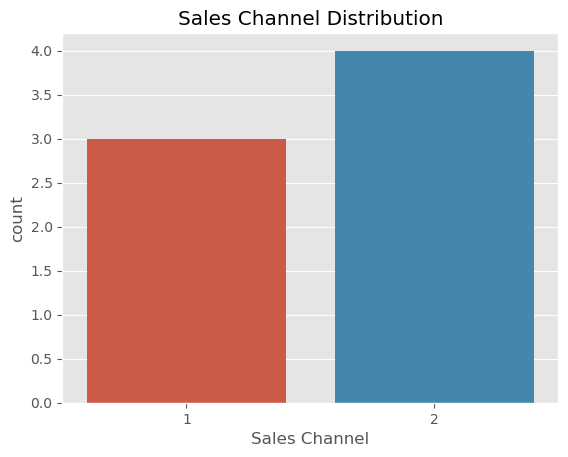

In [225]:
sb.countplot(data=Cerealdf, x="Sales Channel")
plt.figsize=(20, 40)
plt.title('Sales Channel Distribution')

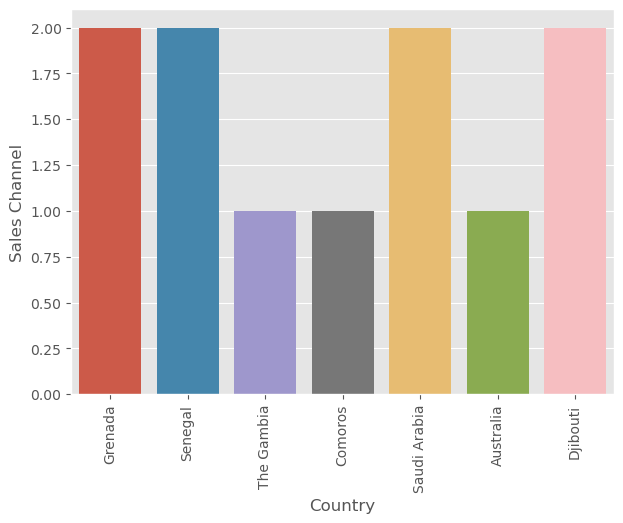

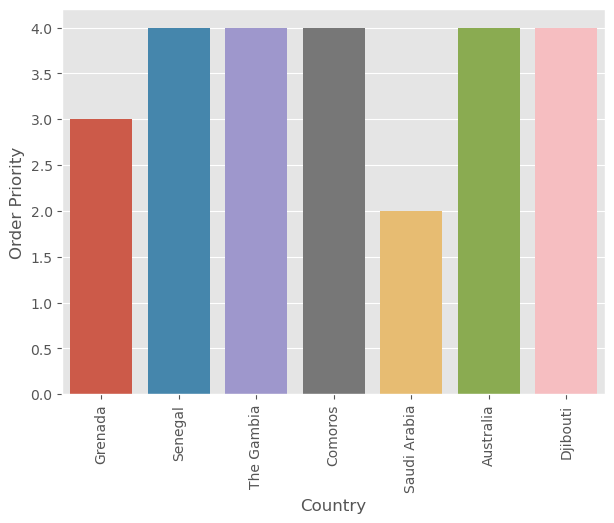

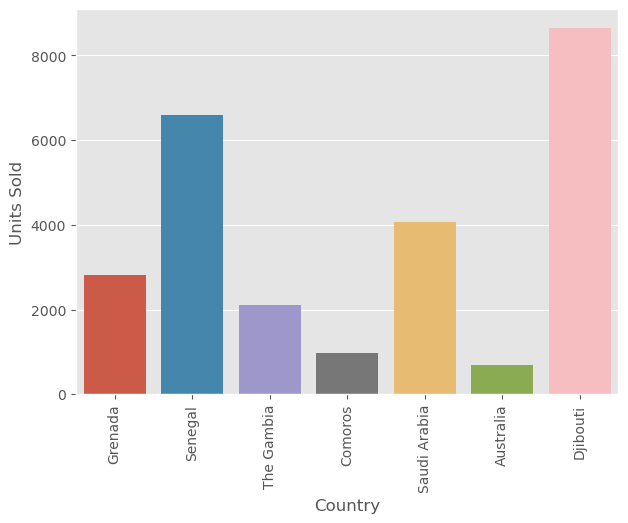

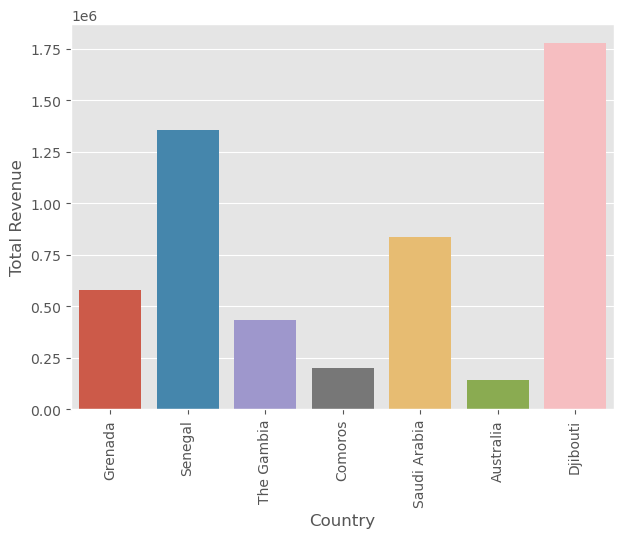

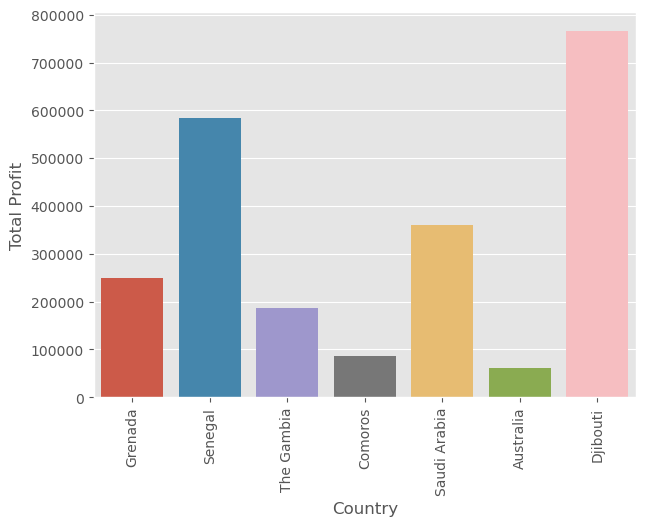

In [224]:
def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Cerealdf)
    plt.xticks(rotation = 90)
    plt.show()
    


FruitList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Country', column, Cerealdf)

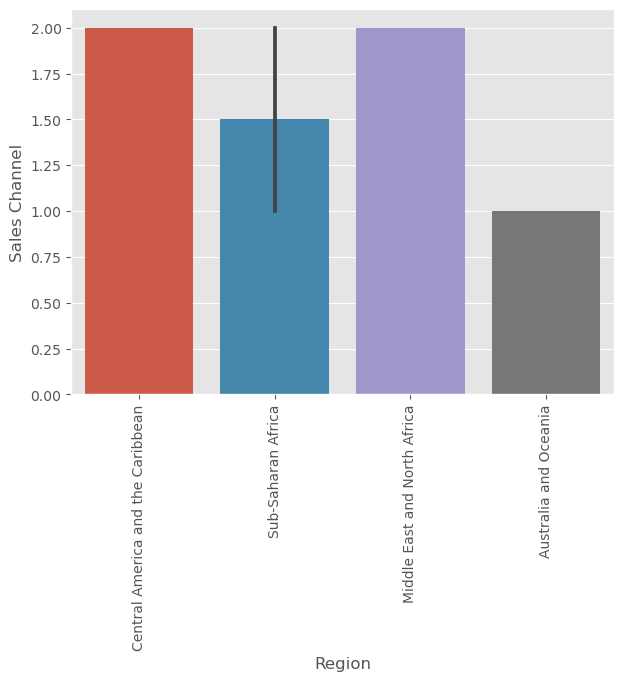

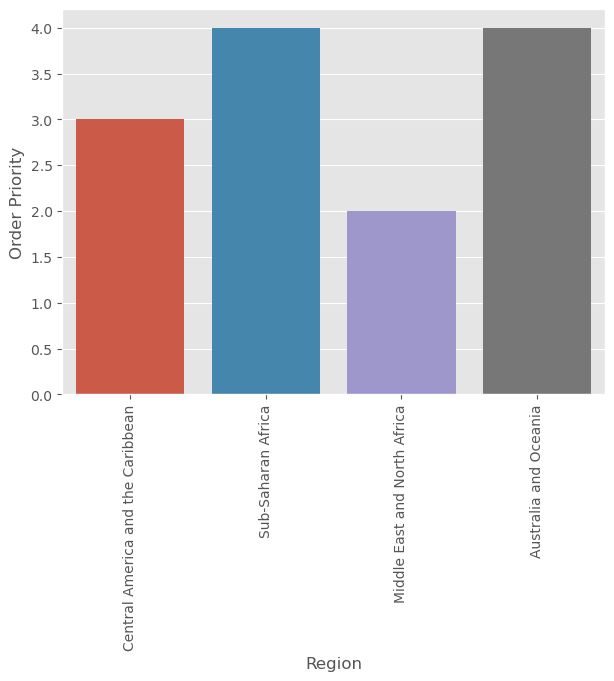

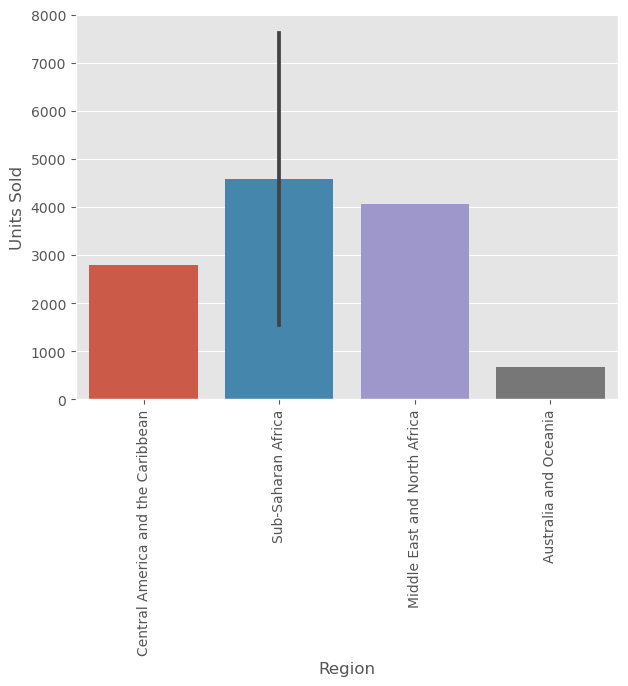

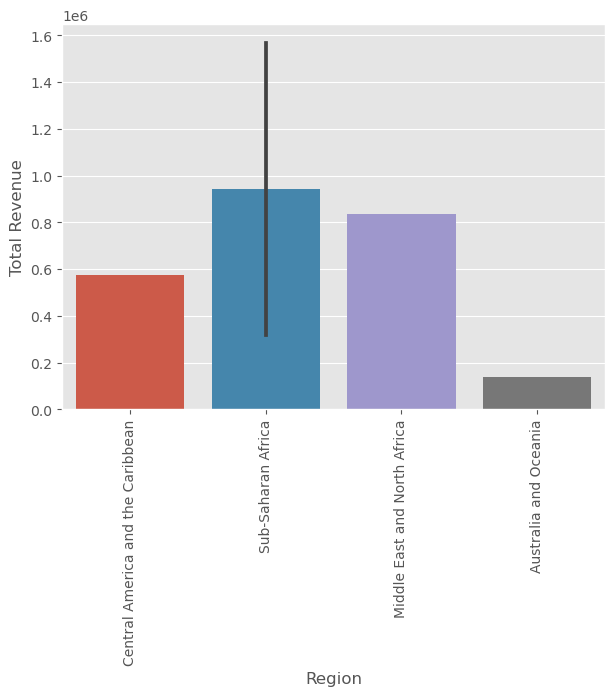

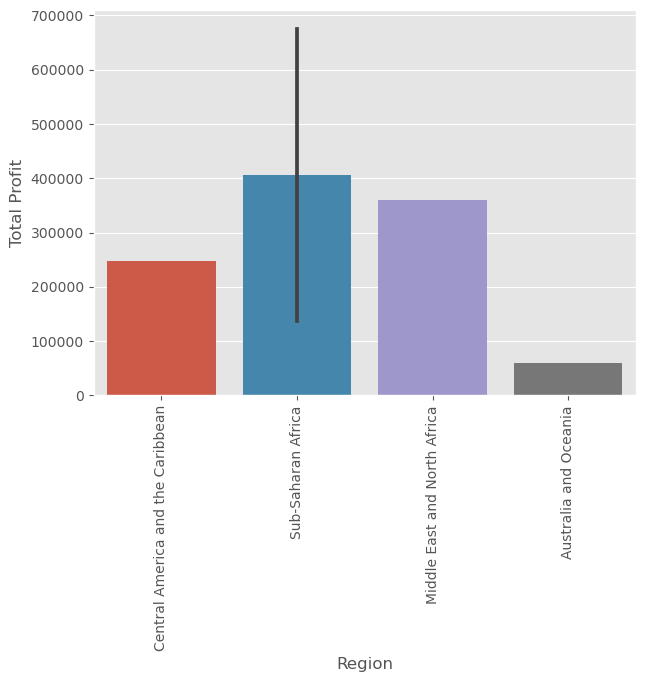

In [223]:
def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Cerealdf)
    plt.xticks(rotation = 90)
    
    plt.show()
    


FruitList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Region', column, Cerealdf)

In [130]:
Vegdf = AmaCopydf.loc[AmaCopydf['Item Type'] == 'Vegetables']

In [131]:
Vegdf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
7,Sub-Saharan Africa,Burkina Faso,Vegetables,2,4,7/17/2012,871543967,7/27/2012,8082,154.06,90.93,1245112.92,734896.26,510216.66,2012-07-27,2012-07-17,10 days
10,Asia,Kyrgyzstan,Vegetables,2,4,6/24/2011,814711606,07-12-2011,124,154.06,90.93,19103.44,11275.32,7828.12,2011-07-12,2011-06-24,18 days
43,Europe,Slovakia,Vegetables,2,4,10-06-2012,759224212,11-10-2012,171,154.06,90.93,26344.26,15549.03,10795.23,2012-11-10,2012-10-06,35 days
77,Asia,Laos,Vegetables,1,3,9/15/2011,789176547,10/23/2011,3732,154.06,90.93,574951.92,339350.76,235601.16,2011-10-23,2011-09-15,38 days
84,Sub-Saharan Africa,Kenya,Vegetables,2,1,3/18/2012,827844560,04-07-2012,6457,154.06,90.93,994765.42,587135.01,407630.41,2012-04-07,2012-03-18,20 days
97,Sub-Saharan Africa,Sierra Leone,Vegetables,1,3,06-01-2016,728815257,6/29/2016,1485,154.06,90.93,228779.10,135031.05,93748.05,2016-06-29,2016-06-01,28 days


In [132]:
Vegdf.Country.value_counts()

Burkina Faso    1
Kyrgyzstan      1
Slovakia        1
Laos            1
Kenya           1
Sierra Leone    1
Name: Country, dtype: int64

In [133]:
Vegdf.Region.value_counts()

Sub-Saharan Africa    3
Asia                  2
Europe                1
Name: Region, dtype: int64

Text(0.5, 1.0, 'Sales Channel Distribution')

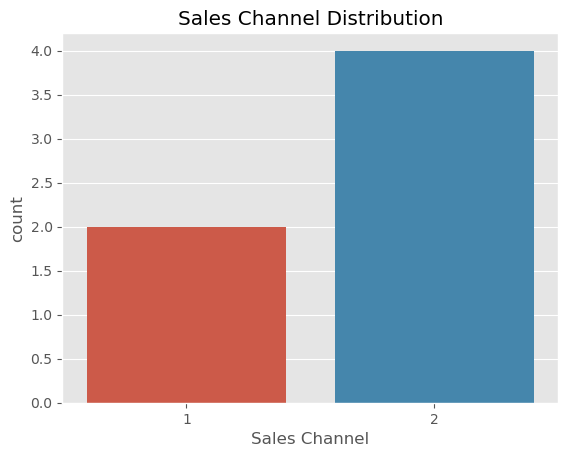

In [222]:
sb.countplot(data=Vegdf, x="Sales Channel")
plt.figsize=(20, 40)
plt.title('Sales Channel Distribution')

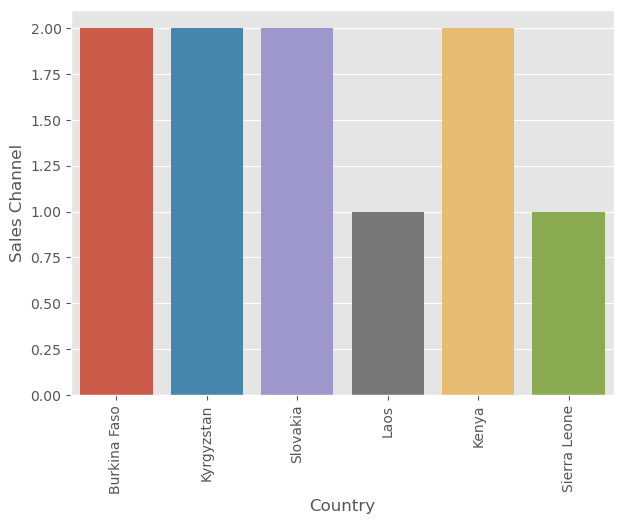

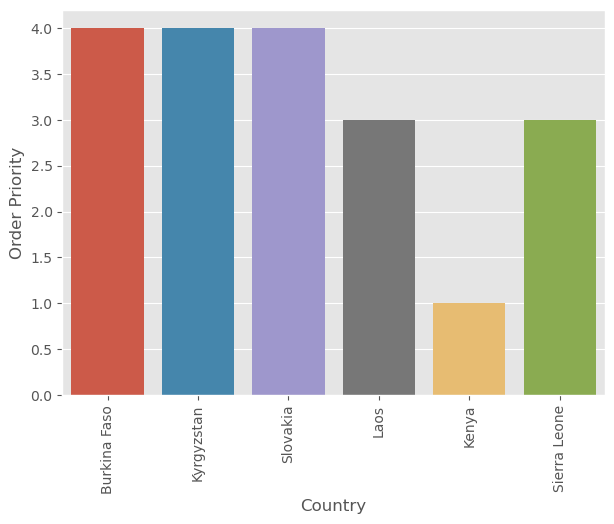

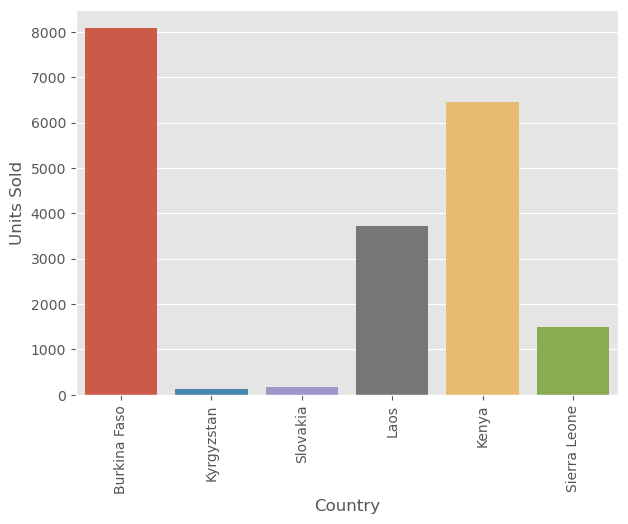

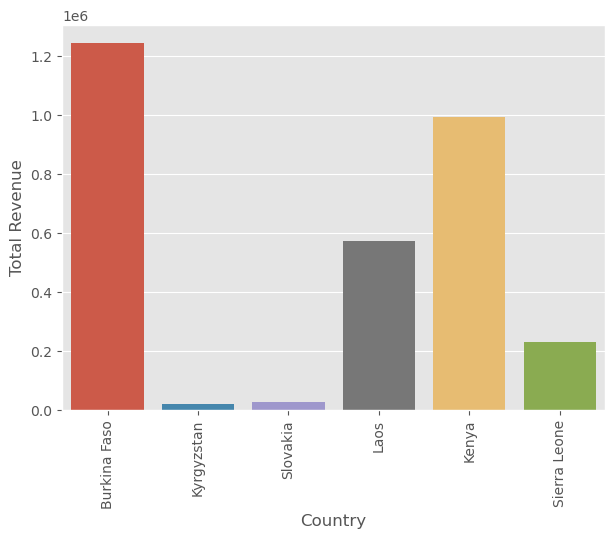

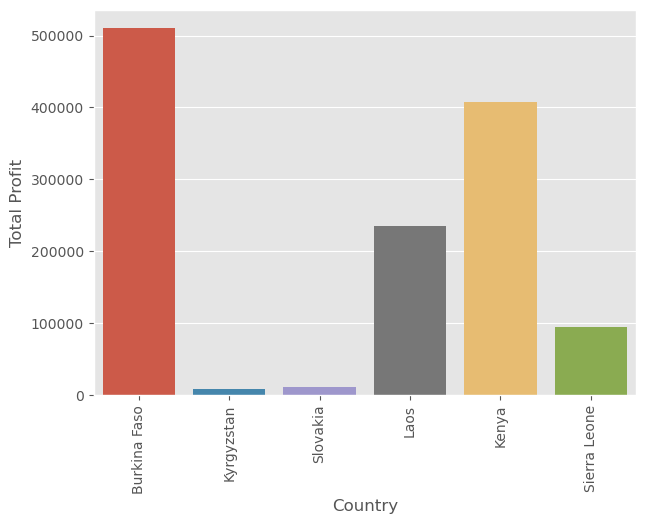

In [221]:
def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Vegdf)
    plt.xticks(rotation = 90)
    
    plt.show()
    


FruitList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Country', column, Vegdf)

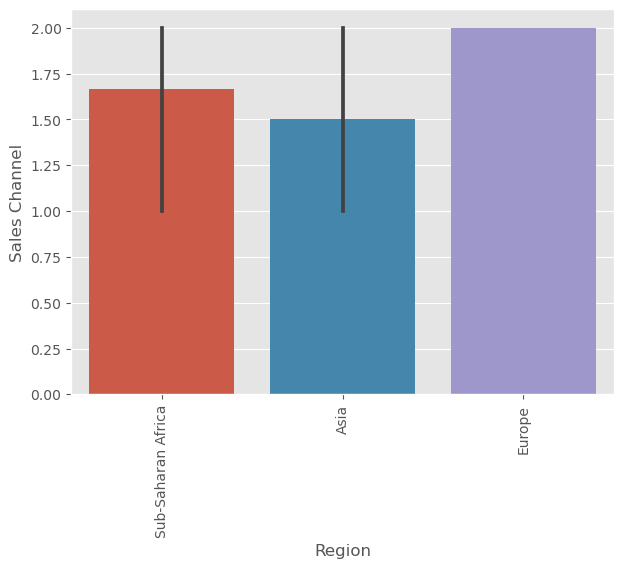

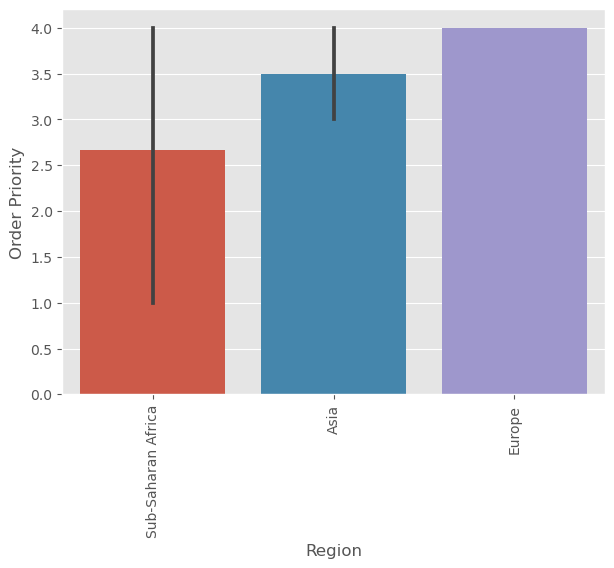

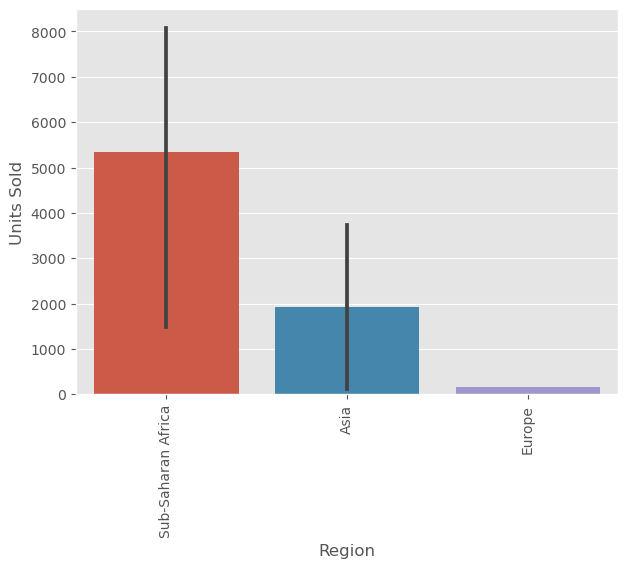

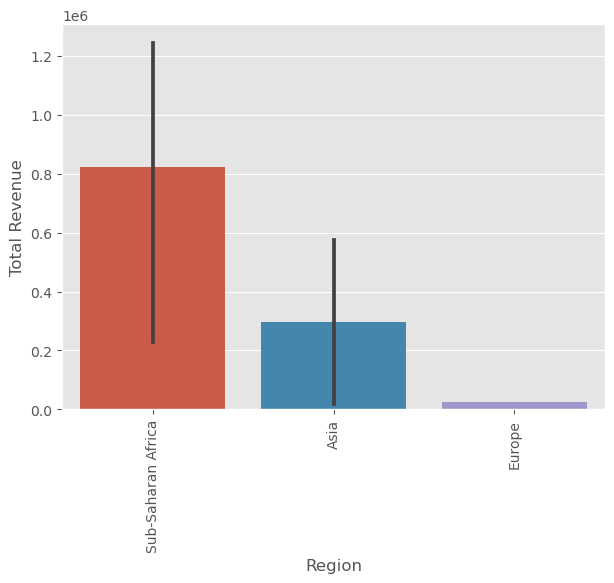

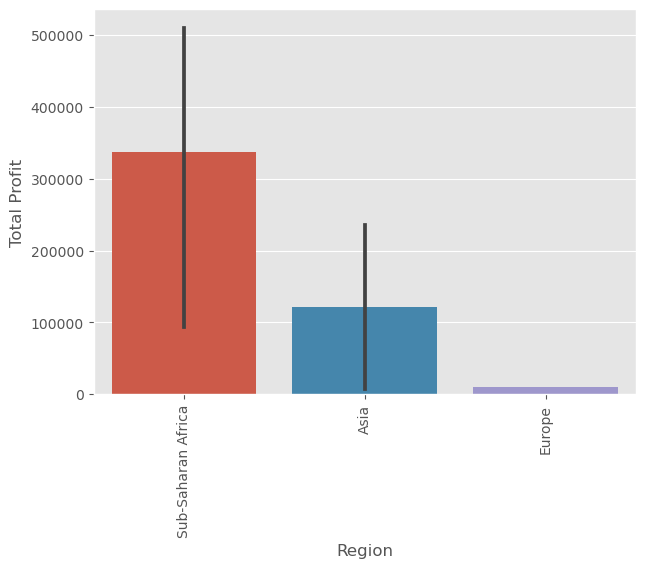

In [220]:
def plotter( X, Y, df):
    plt.figure(figsize=(7,5))
    

    sb.barplot(x=X, y=Y, data = Vegdf)
    plt.xticks(rotation = 90)
   
    plt.show()
    


FruitList = ['Sales Channel', 'Order Priority', 'Units Sold',
       'Total Revenue', 'Total Profit']

for column in ColumnList:
    plotter('Region', column, Vegdf)

In [137]:
Snackdf = AmaCopydf.loc[AmaCopydf['Item Type'] == 'Snacks']

In [138]:
Snackdf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
22,Central America and the Caribbean,Honduras,Snacks,2,1,6/30/2016,795490682,7/26/2016,2225,152.58,97.44,339490.50,216804.00,122686.50,2016-07-26,2016-06-30,26 days
34,Sub-Saharan Africa,Djibouti,Snacks,2,2,2/25/2017,756274640,2/25/2017,7327,152.58,97.44,1117953.66,713942.88,404010.78,2017-02-25,2017-02-25,0 days
83,Sub-Saharan Africa,Zambia,Snacks,2,1,01-04-2011,122583663,01-05-2011,4085,152.58,97.44,623289.30,398042.40,225246.90,2011-01-05,2011-01-04,1 days


In [139]:
Meatdf = AmaCopydf.loc[AmaCopydf['Item Type'] == 'Meat']

In [140]:
Meatdf

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,ShipDate,OrderDate,orderCompTime
19,Australia and Oceania,East Timor,Meat,2,1,7/31/2012,322067916,09-11-2012,5908,421.89,364.69,2492526.12,2154588.52,337937.6,2012-09-11,2012-07-31,42 days
37,Sub-Saharan Africa,The Gambia,Meat,2,2,1/14/2017,825304400,1/23/2017,4767,421.89,364.69,2011149.63,1738477.23,272672.4,2017-01-23,2017-01-14,9 days


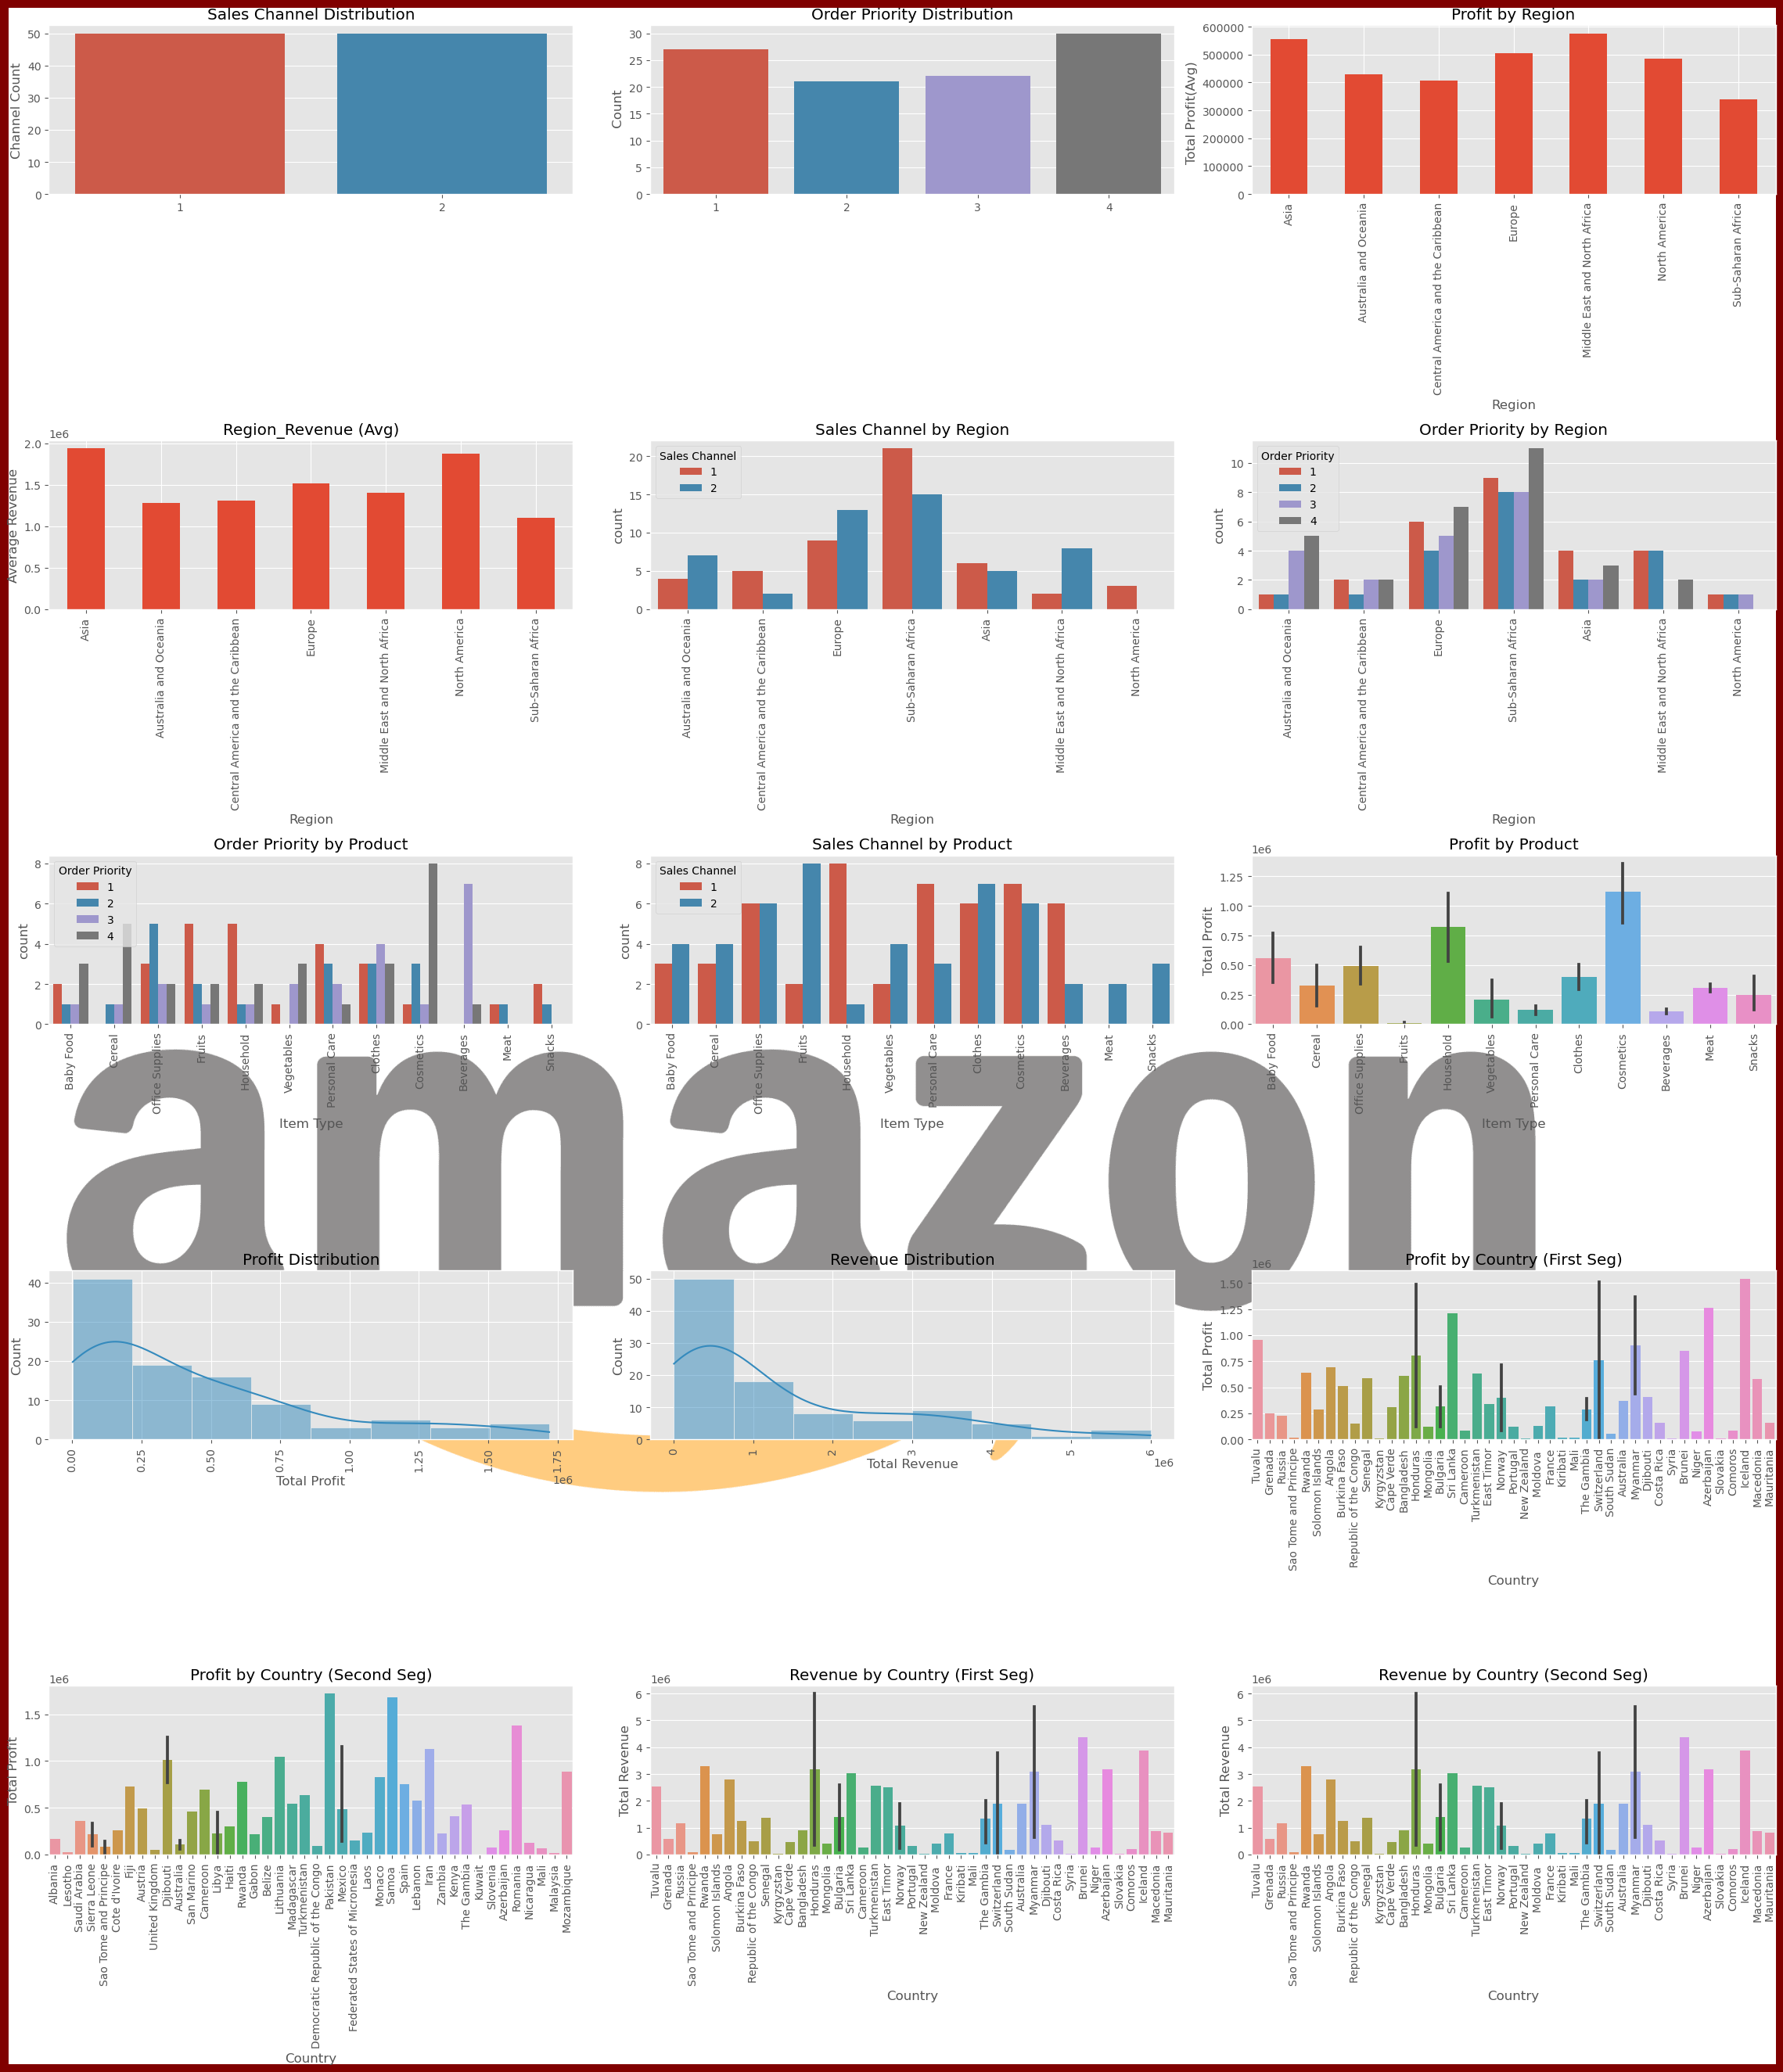

In [218]:
import matplotlib.image as mpimg
plt.style.use('ggplot')

# creating matplotlib subplot structure to hold our plots

fig, axes = plt.subplots(5,3, figsize=(23,28))
fig.subplots_adjust(top=0.85, bottom=0.15, left=0.2, hspace=0.8)

fig.patch.set_linewidth(15)
fig.patch.set_edgecolor('Maroon')


# setting the background image for the entire figure
background_image = mpimg.imread(r"C:\Users\Owner\Documents\amazon-logo-transparent.png")
fig.figimage(background_image, xo=0, yo=0, alpha=0.5, zorder=-1)


# Distribution of Sales Channel
# Plot1
Sales_Channel_counts = AmaCopydf['Sales Channel'].value_counts().sort_index()
sb.barplot(x=Sales_Channel_counts.index, y=Sales_Channel_counts.values, ax=axes[0,0] )
axes[0,0].set_title('Sales Channel Distribution', )
axes[0,0].set_ylabel('Channel Count', )


#Plot2
# Order Priority distribution?
Order_Priority_counts = AmaCopydf['Order Priority'].value_counts().sort_index()
sb.barplot(x=Order_Priority_counts.index, y=Order_Priority_counts.values, ax=axes[0,1])
axes[0,1].set_title('Order Priority Distribution')
axes[0,1].set_ylabel(' Count')

# Plot 3
# Profit by Region


Region_Profit = AmaCopydf.groupby('Region')['Total Profit'].mean().transpose()
Region_Profit.plot(kind='bar', ax=axes[0,2], legend=False)
axes[0,2].set_title('Profit by Region')
axes[0,2].set_ylabel('Total Profit(Avg) ')
axes[0,2].tick_params(axis='x', rotation=90)

# Plot 4
# Revenue by Region
Region_Revenue = AmaCopydf.groupby('Region')['Total Revenue'].mean().transpose()
Region_Revenue.plot(kind='bar', ax=axes[1,0], legend=False)
axes[1, 0].set_title('Region_Revenue (Avg)')
axes[1, 0].set_ylabel('Average Revenue')



### Plot 5: Region by Channel

# Purchases by Channel (Region)
sb.countplot(data=AmaCopydf, x="Region", hue="Sales Channel", ax=axes[1,1])
axes[1,1].tick_params(axis='x', rotation=90)
axes[1,1].set_title('Sales Channel by Region')

# Plot 6: 
#Order Priority by Region
sb.countplot(data=AmaCopydf, x="Region", hue="Order Priority", ax=axes[1,2])
axes[1,2].tick_params(axis='x', rotation=90)
axes[1,2].set_title('Order Priority by Region')

# Plot 7: Order Priority by Product
sb.countplot(data=AmaCopydf, x="Item Type", hue="Order Priority", ax=axes[2,0])
axes[2,0].tick_params(axis='x', rotation=90)
axes[2,0].set_title('Order Priority by Product')

# Plot 8: Sales Channel by Product
sb.countplot(data=AmaCopydf, x="Item Type", hue="Sales Channel", ax=axes[2,1])
axes[2,1].tick_params(axis='x', rotation=90)
axes[2,1].set_title('Sales Channel by Product')

# Plot 9: Profit by Product
sb.barplot(data=AmaCopydf, x="Item Type", y="Total Profit", ax=axes[2,2])
axes[2,2].tick_params(axis='x', rotation=90)
axes[2,2].set_title('Profit by Product')


# Plot 10: Profit Distribution
sb.histplot(AmaCopydf['Total Profit'], kde=True, ax=axes[3,0])
axes[3,0].tick_params(axis='x', rotation=90)
axes[3,0].set_title('Profit Distribution')

# Plot 11: Revenue Distribution
sb.histplot(AmaCopydf['Total Revenue'], kde=True, ax=axes[3,1])
axes[3,1].tick_params(axis='x', rotation=90)
axes[3,1].set_title('Revenue Distribution')

# Plot 12: Profit by Country (First Seg) 
sb.barplot(x= AmaCopydf.iloc[:50, 1], y= 'Total Profit', data= AmaCopydf, ax=axes[3,2] )
axes[3,2].tick_params(axis='x', rotation=90)
axes[3,2].set_title('Profit by Country (First Seg)')

#Plot 13  Profit by Country (Second Seg) 
sb.barplot(x= AmaCopydf.iloc[50:101, 1], y= 'Total Profit', data= AmaCopydf, ax=axes[4,0] )
axes[4,0].tick_params(axis='x', rotation=90)
axes[4,0].set_title('Profit by Country (Second Seg)')

#Plot 14  Revenue by Country (First Seg) 
sb.barplot(x= AmaCopydf.iloc[:50, 1], y= 'Total Revenue', data= AmaCopydf, ax=axes[4,1] )
axes[4,1].tick_params(axis='x', rotation=90)
axes[4,1].set_title('Revenue by Country (First Seg)')

#Plot 15  Revenue by Country (Second Seg)
sb.barplot(x= AmaCopydf.iloc[:50, 1], y= 'Total Revenue', data= AmaCopydf, ax=axes[4,2] )
axes[4,2].tick_params(axis='x', rotation=90)
axes[4,2].set_title('Revenue by Country (Second Seg)')


plt.tight_layout(rect=[0, 0, 1, 0.95])

# Display the figure
plt.show()